# From scenarios to electricity demand: why each technology is chosen and what it does

**Steel and cement, 8 AURIS decision cases, 6 FLEXIMOD macro scenarios**

This notebook tells one story for both sectors, in the order in which it unfolds: the fleet today, the price developments investors may expect, the technologies they adopt under each expectation, and the resulting energy demand by carrier. Every number in it is read from model output files; nothing is typed in by hand except the technology definitions and plain-language labels.

| Step | Question | Source |
|---|---|---|
| 2. Starting point | Which technologies do the plants operate today, and what do they burn and emit? | AURIS investment events, FLEXIMOD simulations |
| 3. Future price developments | How may electricity, fuel, hydrogen and CO2 prices develop (six macro scenarios)? | FLEXIMOD input forecasts |
| 4. Beliefs | Which development does each investor case expect, and how does a risk-averse investor protect itself? | AURIS belief files |
| 5. Technology economics | What does one tonne of product cost, burn and emit with each option in each price world? | FLEXIMOD plant simulations |
| 6. Technology adoption | Which technology does each plant adopt, when, and why (net present value, risk rule, beliefs)? | AURIS decision files |
| 7. Energy demand and emissions | How do the energy demand by carrier and the CO2 emissions develop along the chosen pathways? | FLEXIMOD simulations along the AURIS pathways |
| 8. Electricity-market interface | How is the electricity demand spread over the year and the day, and at what prices? | FLEXIMOD 15-minute results |

**The eight cases.** Six *risk-neutral* cases (Technologiemix, FokusStrom, FokusH2, NachfrageNiedrig, HoheNachfrage, AktuellePolitiken) maximise expected NPV under the belief set named after the case: the investor puts most probability on that macro scenario. Two *risk-averse* cases do not trust any single belief: *WorstCaseMean* maximises the worst-case mean NPV over a set of plausible belief vectors, and *WorstCaseTailRisk* maximises the expected shortfall of the worst 5 percent of outcomes. The case decides **which technology is chosen**. It does not change the electricity profile of a given technology in a given macro scenario.

**Reading guide.** Each section states the question, shows the evidence, then closes with a short *Key findings* block. A reader who only wants the argument can read the section headings, the findings, and the synthesis in section 10.

**Important scope note.** Electricity prices in FLEXIMOD are exogenous scenario inputs. A technology choice therefore never changes the price in this notebook. What it changes is the plant's demand, its timing and its exposure to prices. The price effect of that demand is the job of the downstream electricity-market model.

In [1]:
import re
import warnings
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.csv as pacsv
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.options.display.float_format = "{:,.2f}".format
pd.options.display.max_columns = 60
plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "axes.titlesize": 11, "axes.labelsize": 9.5,
    "legend.fontsize": 8, "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
})


def find_project_root() -> Path:
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not locate the FLEXIMOD project root.")


FLEX = find_project_root()
AURIS = Path("/root/auris-model")
CACHE = FLEX / "data" / "output" / "auris_chain_cache"
CACHE.mkdir(parents=True, exist_ok=True)

CASES = [
    "Technologiemix_risk_neutral", "FokusStrom_risk_neutral", "FokusH2_risk_neutral",
    "NachfrageNiedrig_risk_neutral", "HoheNachfrage_risk_neutral", "AktuellePolitiken_risk_neutral",
    "WorstCaseMean_risk_averse", "WorstCaseTailRisk_risk_averse",
]
CASE_SHORT = {c: c.replace("_risk_neutral", "").replace("_risk_averse", "") for c in CASES}
CASE_SHORT["WorstCaseMean_risk_averse"] = "WorstCaseMean (RA)"
CASE_SHORT["WorstCaseTailRisk_risk_averse"] = "WorstCaseTail (RA)"
for c in CASES[:6]:
    CASE_SHORT[c] = CASE_SHORT[c] + " (RN)"
MACROS = ["aktuellepolitiken", "fokusstrom", "fokusH2", "technologiemix", "hohenachfrage", "niedrigenachfrage"]
MACRO_TITLE = {"aktuellepolitiken": "AktuellePolitiken", "fokusstrom": "FokusStrom", "fokusH2": "FokusH2",
               "technologiemix": "Technologiemix", "hohenachfrage": "HoheNachfrage", "niedrigenachfrage": "NachfrageNiedrig"}
# A risk-neutral case is "matched" to the macro scenario it believes in.
MATCHED_MACRO = {c: c.split("_")[0].lower().replace("h2", "H2") for c in CASES[:6]}
MATCHED_MACRO = {"Technologiemix_risk_neutral": "technologiemix", "FokusStrom_risk_neutral": "fokusstrom",
                 "FokusH2_risk_neutral": "fokusH2", "NachfrageNiedrig_risk_neutral": "niedrigenachfrage",
                 "HoheNachfrage_risk_neutral": "hohenachfrage", "AktuellePolitiken_risk_neutral": "aktuellepolitiken"}

REFERENCE_MACRO = "aktuellepolitiken"   # change to any of the six macro scenarios; drives every cross-case comparison below
ANCHORS = [2030, 2035, 2040, 2045]
YEARS = list(range(2025, 2050))
DISCOUNT_RATE = 0.05

SECTORS = {
    "steel": {
        "title": "Steel", "unit": "t crude steel", "n_plants": 9,
        "results": FLEX / "data/output/steel_results",
        "suffixes": ("_electrified_steel_rule_based", "_electrified_steel"),
        "production_col": "total_steel_production_t",
        "inputs": FLEX / "data/input/steel_inputs", "price_tech": "bf_bof_coal_external",
        "auris_in": AURIS / "data/input/steel_cases", "auris_out": AURIS / "data/output/steel_cases",
    },
    "cement": {
        "title": "Cement", "unit": "t clinker", "n_plants": 32,
        "results": FLEX / "data/output/cement_results",
        "suffixes": ("_electrified_cement_rule_based", "_hybrid_strategy_cement"),
        "production_col": "total_clinker_production_t",
        "inputs": FLEX / "data/input/cement_inputs", "price_tech": "R2",
        "auris_in": AURIS / "data/input", "auris_out": AURIS / "data/output/cement_cases",
    },
}
CARRIERS = ["coal", "natural_gas", "biomass", "rdf", "hydrogen", "electricity"]
CARRIER_COLOR = {"biomass": "#7f9d3b", "rdf": "#c26b8a", "coal": "#4d4d4d", "natural_gas": "#eda100", "hydrogen": "#1baf7a", "electricity": "#2a78d6"}
CARRIER_COL = {"biomass": "biomass_MWh", "rdf": "rdf_MWh", "electricity": "total_electricity_consumption_MWh", "hydrogen": "total_hydrogen_consumption_MWh",
               "natural_gas": "total_natural_gas_consumption_MWh", "coal": "total_coal_consumption_MWh"}
print("FLEXIMOD root:", FLEX)
print("AURIS root   :", AURIS, "| exists:", AURIS.exists())

FLEXIMOD root: /root/FLEXIMOD
AURIS root   : /root/auris-model | exists: True


## 0. Technology definitions

Technologies are identified by short IDs. The tables below give the full configuration, so every ID that appears later can be looked up here. The energy carriers each configuration uses (share in percent and MWh per tonne of steel or clinker) are plotted in section 5.1; the process chains are drawn in `technology_process_flow_diagrams.ipynb`.

**Steel.** An ID reads `<process route>_<fuel>_<hydrogen supply>`. *BF-BOF* is the blast furnace and basic oxygen furnace, *DRI-BOF* is direct reduced iron followed by a basic oxygen furnace, *DRI-EAF* is direct reduced iron followed by an electric arc furnace. The fuel is coal, natural gas, hydrogen, or a *hybrid* hydrogen and natural-gas blend. Hydrogen is either bought from the network (*external*) or made on site with an *electrolyser*, which adds electricity demand.

**Cement.** The anonymised route codes R1 to R16 describe the clinker line (preheater, calciner, kiln) and the carbon-capture add-on. The definitions come from the FLEXIMOD cement model documentation (`docs/cement_plant_model.md`).

In [2]:
CEMENT_ROUTES = {
    "R1": ("Fossil calciner and kiln", "no capture"),
    "R2": ("R1 with alternative-fuel profile", "no capture"),
    "R3": ("R1 + amine CCS", "amine CCS"),
    "R4": ("R1 + cryogenic CCS", "cryogenic CCS"),
    "R5": ("Electric calciner, fossil kiln", "no capture"),
    "R6": ("Hybrid electric/fossil calciner, fossil kiln", "no capture"),
    "R7": ("R5 + amine CCS", "amine CCS"),
    "R8": ("Electric calciner and kiln + cryogenic CCS", "cryogenic CCS"),
    "R9": ("Oxyfuel calciner and kiln (fossil) + oxyfuel CCS", "oxyfuel CCS"),
    "R10": ("Oxyfuel calciner, simple fossil kiln + oxyfuel CCS", "oxyfuel CCS"),
    "R11a": ("Hydrogen-fired calciner and kiln (bought H2) + amine CCS", "amine CCS"),
    "R11b": ("R11a + on-site electrolyser", "amine CCS"),
    "R12a": ("Oxyfuel calciner and kiln fired with bought H2 + oxyfuel CCS", "oxyfuel CCS"),
    "R12b": ("R12a + on-site electrolyser", "oxyfuel CCS"),
    "R13": ("LEILAC calciner (fossil), simple fossil kiln", "separated process CO2"),
    "R14": ("LEILAC calciner (electric), simple fossil kiln", "separated process CO2"),
    "R15a": ("LEILAC calciner (hydrogen), hydrogen kiln (bought H2)", "separated process CO2"),
    "R15b": ("R15a + on-site electrolyser", "separated process CO2"),
    "R16": ("R13 + amine CCS", "separated process CO2 + amine CCS"),
}
STEEL_PROCESS = {"bf_bof": "BF-BOF", "dri_bof": "DRI-BOF", "dri_eaf": "DRI-EAF"}
STEEL_FUEL = {"coal": "coal", "natural_gas": "natural gas", "hydrogen": "hydrogen",
              "hybrid_hydrogen_natural_gas": "hybrid H2 + gas"}


def steel_parts(tech: str):
    m = re.match(r"^(bf_bof|dri_bof|dri_eaf)_(.+)_(external|electrolyser)$", tech)
    return STEEL_PROCESS[m.group(1)], STEEL_FUEL[m.group(2)], m.group(3)


def tech_label(sector: str, tech: str) -> str:
    if sector == "cement":
        return tech
    process, fuel, supply = steel_parts(tech)
    suffix = ""
    if "H2" in fuel or fuel == "hydrogen":
        suffix = " (on-site H2)" if supply == "electrolyser" else " (network H2)"
    return f"{process} {fuel}{suffix}"


def tech_long(sector: str, tech: str) -> str:
    if sector == "cement":
        return f"{tech}: {CEMENT_ROUTES[tech][0]}"
    process, fuel, supply = steel_parts(tech)
    return f"{process}, {fuel}, hydrogen {'from network' if supply == 'external' else 'from on-site electrolyser'}"


steel_def = pd.DataFrame(
    [(t, *steel_parts(t)) for t in sorted(set(pd.read_csv(SECTORS["steel"]["auris_in"] / "Technologiemix_risk_neutral/technology.csv")["technology"]))],
    columns=["technology_id", "process route", "fuel", "hydrogen supply"])
cement_def = pd.DataFrame([(k, *v) for k, v in CEMENT_ROUTES.items()],
                          columns=["technology_id", "configuration", "carbon handling"])
display(steel_def.style.hide(axis="index").set_caption("Steel technology options (18)"))
display(cement_def.style.hide(axis="index").set_caption("Cement technology options (19)"))

technology_id,process route,fuel,hydrogen supply
bf_bof_coal_external,BF-BOF,coal,external
bf_bof_hybrid_hydrogen_natural_gas_electrolyser,BF-BOF,hybrid H2 + gas,electrolyser
bf_bof_hybrid_hydrogen_natural_gas_external,BF-BOF,hybrid H2 + gas,external
bf_bof_hydrogen_electrolyser,BF-BOF,hydrogen,electrolyser
bf_bof_hydrogen_external,BF-BOF,hydrogen,external
bf_bof_natural_gas_external,BF-BOF,natural gas,external
dri_bof_coal_external,DRI-BOF,coal,external
dri_bof_hybrid_hydrogen_natural_gas_electrolyser,DRI-BOF,hybrid H2 + gas,electrolyser
dri_bof_hybrid_hydrogen_natural_gas_external,DRI-BOF,hybrid H2 + gas,external
dri_bof_hydrogen_electrolyser,DRI-BOF,hydrogen,electrolyser


technology_id,configuration,carbon handling
R1,Fossil calciner and kiln,no capture
R2,R1 with alternative-fuel profile,no capture
R3,R1 + amine CCS,amine CCS
R4,R1 + cryogenic CCS,cryogenic CCS
R5,"Electric calciner, fossil kiln",no capture
R6,"Hybrid electric/fossil calciner, fossil kiln",no capture
R7,R5 + amine CCS,amine CCS
R8,Electric calciner and kiln + cryogenic CCS,cryogenic CCS
R9,Oxyfuel calciner and kiln (fossil) + oxyfuel CCS,oxyfuel CCS
R10,"Oxyfuel calciner, simple fossil kiln + oxyfuel CCS",oxyfuel CCS


**What each cement route physically is.** The route code fixes which pieces of kiln-line equipment are installed (at most one calciner, one kiln and one CCS variant; `src/flexi_mod/plants/cement_plant.py`) and therefore which fuel modes and CO2 pathways are available. Calcination CO2 (from the limestone itself, independent of fuel) is always assigned to the calciner.

* **R1 — Fossil calciner and kiln, no capture.** The reference unabated route: 96.6% coal / 3.4% natural gas combustion in both calciner and kiln, no CO2 handling. Emissions are highest of any route because nothing is captured and nothing is electrified.
* **R2 — R1 with an alternative-fuel profile, no capture.** Same equipment as R1, but the combustion mix is replaced by the model's R2 default: 25.7% coal, 0.9% natural gas, 24.5% separately procured biomass and 48.9% mixed RDF (refuse-derived fuel). This halves the fossil share without adding any capture equipment, so it is a fuel-substitution route, not a capture route. Mixed RDF carries a fixed fossil CO2 factor (0.243 tCO2/MWh) plus a biogenic component, so part of its CO2 is zero-rated for carbon pricing even though it is still physically emitted.
* **R3 — R1 + amine CCS.** The R1 fossil kiln line unchanged, with a post-combustion amine-scrubbing CCS block added downstream that captures a configured fraction of the calciner's and kiln's combined flue-gas CO2 (process + fuel). Amine CCS needs both electricity and process heat (`heat_cost`), so it raises operating cost in addition to the capture equipment's own CAPEX.
* **R4 — R1 + cryogenic CCS.** Same fossil kiln line as R1, but with a cryogenic (low-temperature separation) CCS block instead of amine: electricity only, no heat demand, a different capture-efficiency and variable-cost profile. Chosen by at least one AURIS case — its advantage over R3 is avoiding the heat penalty while still handling the dominant coal/gas-fired route.
* **R5 — Electric calciner, fossil kiln, no capture.** The calciner's heat is now generated from electricity (`fuel_type = electricity`) instead of combustion; the kiln stays conventional fossil. Combustion CO2 drops roughly in proportion to the calciner's share of total kiln-line heat demand, while calcination (process) CO2 is unchanged — only fuel-switching, not capture, is happening.
* **R6 — Hybrid electric/fossil calciner, fossil kiln, no capture.** Like R5, but the calciner can mix electric and combustion heat in the same timestep (`fuel_type = hybrid_electricity_fossil`), so the plant can shift between the two hour by hour depending on which is cheaper. The kiln remains conventional fossil. This flexibility is why the hybrid route is attractive to risk-averse cases: it hedges against both a high electricity price and a high gas/CO2 price.
* **R7 — R5 + amine CCS.** The electric-calciner/fossil-kiln line of R5 with an amine CCS block added to capture the kiln's (and any residual calciner) combustion CO2.
* **R8 — Electric calciner and kiln + cryogenic CCS.** Both calciner and kiln run on electricity; only calcination process CO2 remains in the flue gas (no combustion CO2 at all), and cryogenic CCS captures a fraction of that. This is the only route that is 100% electricity by final energy (section 5.1) and the technology every AURIS case converges to by 2045.
* **R9 — Oxyfuel calciner and kiln (fossil) + oxyfuel CCS.** Both stages burn fossil fuel in oxygen instead of air, which concentrates the flue gas into a near-pure CO2/H2O stream; an oxyfuel CO2-recovery block then purifies and compresses it. Oxygen is supplied by on-site air separation (extra electricity) unless an electrolyser co-product is available. Chosen by at least one AURIS case for its high, near-complete capture of a route that still burns coal.
* **R10 — Oxyfuel calciner, simple fossil kiln + oxyfuel CCS.** Only the calciner runs oxyfuel; the kiln stays conventional (no oxygen, no separate kiln capture target since kiln combustion CO2 is small relative to calciner process CO2). A lower-CAPEX variant of R9 that still captures the calciner's process and fuel CO2.
* **R11a — Hydrogen-fired calciner and kiln (bought H2) + amine CCS.** Both stages run in `fuel_type = hydrogen` mode (no coal, gas, biomass or RDF combustion at all), fired with hydrogen purchased from the network; amine CCS still captures the calcination process CO2, which hydrogen combustion does not eliminate. Chosen by at least one AURIS case — in the reference world it is one of the cheapest low-fossil options (section 5.1: 84–90% hydrogen share).
* **R11b — R11a + on-site electrolyser.** Identical kiln line and CCS to R11a, but the hydrogen is produced on-site by an electrolyser instead of bought. The electricity that feeds the electrolyser is counted as electricity consumption in addition to the hydrogen it produces, which is why R11b's MWh-per-tonne figure in section 5.1 is roughly double R11a's (an accounting double-count, not a real efficiency loss on top of the electrolyser's own conversion losses).
* **R12a — Oxyfuel calciner and kiln fired with bought H2 + oxyfuel CCS.** Combines hydrogen firing with oxyfuel combustion (hydrogen burned in oxygen) and oxyfuel-style CO2 recovery of the concentrated stream; oxygen demand is computed the same way as R9/R10 (`hydrogen_oxygen_demand`).
* **R12b — R12a + on-site electrolyser.** As R12a, but on-site electrolysis supplies the hydrogen (and can also supply part of the oxyfuel oxygen demand as a co-product), again with the electricity/hydrogen double count described for R11b.
* **R13 — LEILAC calciner (fossil), simple fossil kiln, separated process CO2.** The calciner uses LEILAC's indirect-separation design, which captures a direct-separation fraction of calcination CO2 as an inherent part of the calcination process itself (not a downstream CCS add-on) while still burning fossil fuel for heat; combustion CO2 is unaffected. The kiln is conventional fossil.
* **R14 — LEILAC calciner (electric), simple fossil kiln, separated process CO2.** Same inherent process-CO2 separation as R13, but the calciner's heat is now electric rather than combustion-fired, so both process CO2 (via LEILAC separation) and most calciner-side combustion CO2 are addressed; the kiln remains conventional fossil.
* **R15a — LEILAC calciner (hydrogen), hydrogen kiln (bought H2), separated process CO2.** LEILAC's inherent process-CO2 separation combined with hydrogen firing in both calciner and kiln (bought hydrogen): the lowest-emission route that still needs no downstream CCS block, because process CO2 is separated at source and fuel CO2 from hydrogen combustion is zero. Chosen by at least one AURIS case.
* **R15b — R15a + on-site electrolyser.** As R15a, with on-site electrolysis instead of bought hydrogen — again with the electricity/hydrogen double-count in the energy accounting.
* **R16 — R13 + amine CCS, separated process CO2 + amine CCS.** Adds a downstream amine CCS block to R13's LEILAC-fossil line, capturing combustion CO2 (and any process CO2 that LEILAC's direct separation did not already remove) on top of the inherent process-CO2 separation — a route that stacks two different CO2-handling mechanisms.

**On-site electrolyser variants (R11b, R12b, R15b) double-count energy.** Their hydrogen is produced from grid electricity on-site; both the input electricity and the hydrogen it becomes are reported as separate carriers in the FLEXIMOD energy accounting used throughout this notebook (sections 5.1, 7.1–7.4). Read their MWh-per-tonne and carrier-share figures with that in mind — they are not twice as energy-intensive as the bought-hydrogen equivalent, the accounting counts the same energy flow twice.

In [3]:
_tech_palette = plt.get_cmap("tab20")
TECH_COLOR = {}
for sec in SECTORS:
    techs = sorted(steel_def.technology_id) if sec == "steel" else list(cement_def.technology_id)
    for i, t in enumerate(techs):
        TECH_COLOR[(sec, t)] = _tech_palette(i % 20)

Block-flow diagrams of how each of these configurations is represented in the optimisation model (stages, energy inputs, CO2 routing) are in the companion notebook `technology_process_flow_diagrams.ipynb`.

## 1. Data loading

Four sources are used. Nothing is recomputed that a model already produced, except aggregations.

1. **AURIS decision files** per case: `technology_pathway.csv` (technology per plant and year), `auris_selected_decisions.csv`, `dynamic_decision_scores.csv` (every candidate with its expected NPV and risk metrics), `dynamic_investment_events.csv`, and `dynamic_annual_cashflows.csv` (revenue, operating cost, CAPEX and residual value of every candidate in every macro scenario).
2. **FLEXIMOD plant summaries** (`summary_indicators.csv`): for every technology, macro scenario and anchor year (2030, 2035, 2040, 2045) the plant's annual production, energy by carrier, CO2 and cost components. This is the physical truth in this notebook.
3. **FLEXIMOD forecasts** (`forecasts_df.csv`): electricity and commodity prices per macro scenario and year.
4. **FLEXIMOD 15-minute results**, already assembled per AURIS case and macro scenario in `data/output/auris_inputs_15min/`.

*Why physical quantities do not come from AURIS.* AURIS cash-flow files contain energy and CO2 columns, but for steel they are generic placeholders (for example, identical CO2 for every technology, and no coal for the coal route). The FLEXIMOD simulations resolve these per technology, so they are used for everything physical.

In [4]:
def sim_folder_parts(name: str, sector: str):
    for suffix in SECTORS[sector]["suffixes"]:
        if name.endswith(suffix):
            macro, year, tech = name[: -len(suffix)].split("_", 2)
            return macro, int(year), tech
    return None


def load_sim(sector: str) -> pd.DataFrame:
    """One row per plant, technology, macro scenario and anchor year from FLEXIMOD summaries."""
    cfg = SECTORS[sector]
    cols = ["plant_name", "total_electricity_consumption_MWh", "total_hydrogen_consumption_MWh",
            "total_natural_gas_consumption_MWh", "total_coal_consumption_MWh", "total_co2_emissions_t",
            "total_DA_electricity_MWh", "total_afrr_energy_activated_MWh",
            "total_electricity_market_cost_EUR", "total_additional_electricity_charges_cost_EUR",
            "gross_operating_cost_EUR", "net_operating_cost_incl_grid_fees_EUR"]
    if sector == "steel":
        cols += ["total_iron_ore_consumption_t", "total_lime_consumption_t"]

    def one(folder: Path):
        parts = sim_folder_parts(folder.name, sector)
        if parts is None:
            return None
        macro, year, tech = parts
        df = pd.read_csv(folder / "summary_indicators.csv.zst", compression="zstd")
        out = df[cols].copy()
        out["production_t"] = df[cfg["production_col"]]
        out["macro"], out["year"], out["technology"] = macro, year, tech
        out["plant_id"] = out["plant_name"].str[: -(len(tech) + 1)]
        return out

    folders = [f for f in cfg["results"].iterdir() if f.is_dir()]
    with ThreadPoolExecutor(16) as pool:
        frames = [f for f in pool.map(one, folders) if f is not None]
    return pd.concat(frames, ignore_index=True)


SIM = {s: load_sim(s) for s in SECTORS}
for s, d in SIM.items():
    d["process_cost_EUR"] = (d["gross_operating_cost_EUR"] - d["total_electricity_market_cost_EUR"]
                             - d["total_additional_electricity_charges_cost_EUR"])
    print(f"{s}: {len(d):,} plant-technology-scenario-year rows, {d.technology.nunique()} technologies, "
          f"{d.plant_id.nunique()} plants")


def load_dispatch_extras(sector: str) -> pd.DataFrame:
    """Quantities the summaries lack: biomass and RDF use, CO2 that is charged, and peak powers (cached)."""
    cache_file = CACHE / f"dispatch_extras_{sector}.parquet"
    if cache_file.exists():
        return pd.read_parquet(cache_file)
    want = ["plant_name", "total_electricity_consumption_MWh", "natural_gas_consumption_MWh", "hydrogen_consumption_MWh",
            "biomass_consumption_MWh", "rdf_consumption_MWh", "co2_priced_emissions_t", "co2_priced_t", "co2_emissions_t"]

    def one(folder: Path):
        parts = sim_folder_parts(folder.name, sector)
        if parts is None:
            return None
        macro, year, tech = parts
        file = folder / "dispatch_results.csv.zst"
        header = set(pd.read_csv(file, compression="zstd", nrows=0).columns)
        use = [c for c in want if c in header]
        with pa.input_stream(str(file), compression="zstd") as stream:
            df = pacsv.read_csv(stream, convert_options=pacsv.ConvertOptions(include_columns=use)).to_pandas()
        priced = next(c for c in ("co2_priced_emissions_t", "co2_priced_t", "co2_emissions_t") if c in df)
        g = df.groupby("plant_name")
        out = pd.DataFrame({
            "biomass_MWh": g["biomass_consumption_MWh"].sum() if "biomass_consumption_MWh" in df else 0.0,
            "rdf_MWh": g["rdf_consumption_MWh"].sum() if "rdf_consumption_MWh" in df else 0.0,
            "co2_charged_t": g[priced].sum(),
            "peak_el_MW": g["total_electricity_consumption_MWh"].max() * 4,   # 15-minute steps
            "peak_gas_MW": g["natural_gas_consumption_MWh"].max() * 4,
            "peak_h2_MW": g["hydrogen_consumption_MWh"].max() * 4,
        }).reset_index()
        out["macro"], out["year"], out["technology"] = macro, year, tech
        return out

    folders = [f for f in SECTORS[sector]["results"].iterdir() if f.is_dir()]
    print(f"{sector}: reading {len(folders)} dispatch files (first run only)")
    with ThreadPoolExecutor(12) as pool:
        frames = [f for f in pool.map(one, folders) if f is not None]
    res = pd.concat(frames, ignore_index=True)
    res.to_parquet(cache_file)
    return res


for s, d in SIM.items():
    SIM[s] = d.merge(load_dispatch_extras(s), on=["plant_name", "macro", "year", "technology"], how="left", validate="1:1")
    assert SIM[s]["co2_charged_t"].notna().all()


def load_auris(sector: str):
    out = {}
    for case in CASES:
        base = SECTORS[sector]["auris_out"] / case
        res = base / "dynamic_investment_results"
        out[case] = {
            "pathway": pd.read_csv(base / "technology_pathway.csv"),
            "events": pd.read_csv(res / "dynamic_investment_events.csv"),
            "selected": pd.read_csv(res / "auris_selected_decisions.csv"),
            "scores": pd.read_csv(res / "dynamic_decision_scores.csv"),
            "beliefs": pd.read_csv(res / "auris_belief_probability_summary.csv"),
            "state": pd.read_csv(res / "dynamic_plant_state.csv"),
        }
    return out


AUR = {s: load_auris(s) for s in SECTORS}
for s in SECTORS:
    p = AUR[s][CASES[0]]["pathway"]
    print(f"{s}: pathway rows per case {len(p):,}, plants {p.plant_id.nunique()}, years {p.year.min()}-{p.year.max()}")

steel: 3,888 plant-technology-scenario-year rows, 18 technologies, 9 plants
cement: 14,592 plant-technology-scenario-year rows, 19 technologies, 32 plants


steel: pathway rows per case 225, plants 9, years 2025-2049
cement: pathway rows per case 800, plants 32, years 2025-2049


In [5]:
PRICE_COLS = {"DE_DA_price": "Day-ahead price", "aFRR_energy_down_price": "aFRR energy (down) price",
              "natural_gas_price": "Natural gas", "coal_price": "Coal", "hydrogen_price": "Hydrogen", "co2_price": "CO2"}
OTHER_PRICE_COLS = {"aFRR_capacity_down_price": ("aFRR capacity (down) price", "EUR per MW and hour"),
                    "iron_ore_price": ("Iron ore", "EUR per t"), "lime_price": ("Lime", "EUR per t"),
                    "biomass_price": ("Biomass", "EUR per MWh"), "naphtha_price": ("Naphtha", "EUR per MWh"),
                    "rdf_price": ("Refuse-derived fuel (RDF)", "EUR per MWh")}
ALL_PRICE_COLS = [*PRICE_COLS, *OTHER_PRICE_COLS]


def load_prices(sector: str) -> pd.DataFrame:
    cfg = SECTORS[sector]
    frames = []
    for macro in MACROS:
        for year in ANCHORS:
            f = cfg["inputs"] / f"{macro}_{year}_{cfg['price_tech']}" / "forecasts_df.csv"
            header = pd.read_csv(f, nrows=0).columns
            d = pd.read_csv(f, usecols=["datetime", *[c for c in ALL_PRICE_COLS if c in header]])
            d["datetime"] = pd.to_datetime(d["datetime"])
            d["macro"], d["year"] = macro, year
            frames.append(d)
    return pd.concat(frames, ignore_index=True)


PRICES = {s: load_prices(s) for s in SECTORS}
price_annual = pd.concat(
    [PRICES[s].groupby(["macro", "year"]).mean(numeric_only=True).assign(sector=s).reset_index() for s in SECTORS],
    ignore_index=True)
print("Price series loaded:", {s: len(v) for s, v in PRICES.items()}, "rows")

Price series loaded: {'steel': 837024, 'cement': 839232} rows


## 2. Starting point: the fleet today

**Question.** Before any investment decision: which plants exist, which technology does each operate, what do they produce, and what do they burn and emit? This is the situation every case starts from, and the situation the future price developments (sections 3 and 4) then act upon.

**Source.** AURIS records the technology each plant operates before its first decision (`old_technology_id` in the investment events). FLEXIMOD supplies the physical quantities of that technology. The earliest simulated year is 2030, so it stands for the present here; 2025 to 2029 use the 2030 simulation, as everywhere in this notebook. The fossil technologies of today consume almost the same energy per tonne in every macro scenario, so the reference world is a fair representation (the later sections show the exact differences).

In [6]:
CURRENT_YEAR = ANCHORS[0]          # 2030: earliest simulated year, stands for the present
CURRENT_WORLD = "technologiemix"


def current_fleet(sector: str) -> pd.DataFrame:
    """One row per plant: the technology it operates before AURIS's first decision, with FLEXIMOD's physical results for it."""
    ev = AUR[sector][CASES[0]]["events"].sort_values("year").groupby("plant_id").first()["old_technology_id"]
    sim = SIM[sector]
    sim = sim[(sim.macro == CURRENT_WORLD) & (sim.year == CURRENT_YEAR)]
    fleet = pd.DataFrame({"plant_id": ev.index, "technology": ev.values}).merge(sim, on=["plant_id", "technology"], how="left")
    assert fleet["production_t"].notna().all(), "current technology without simulation result"
    for car, col in CARRIER_COL.items():
        fleet[car + "_TWh"] = fleet[col] / 1e6
    fleet["co2_Mt"] = fleet["total_co2_emissions_t"] / 1e6
    fleet["production_Mt"] = fleet["production_t"] / 1e6
    return fleet


FLEET0 = {s: current_fleet(s) for s in SECTORS}

rows = []
for s, f in FLEET0.items():
    g = f.groupby("technology").agg(plants=("plant_id", "size"), production_Mt=("production_Mt", "sum"), co2_Mt=("co2_Mt", "sum"),
                                    **{c + "_TWh": (c + "_TWh", "sum") for c in CARRIERS})
    g["energy_TWh"] = g[[c + "_TWh" for c in CARRIERS]].sum(axis=1)
    g["MWh per t"] = g["energy_TWh"] / g["production_Mt"]
    g["t CO2 per t"] = g["co2_Mt"] / g["production_Mt"]
    g.insert(0, "sector", s)
    g.index = [tech_label(s, t) if s == "steel" else t for t in g.index]
    rows.append(g)
    tot = g[["plants", "production_Mt", "co2_Mt", "energy_TWh"]].sum()
    print(f"{SECTORS[s]['title']}: {int(tot.plants)} plants, {tot.production_Mt:.1f} Mt {SECTORS[s]['unit'].split(' ')[-1]} per year, "
          f"{tot.energy_TWh:.0f} TWh final energy, {tot.co2_Mt:.1f} Mt CO2 ({tot.co2_Mt / tot.production_Mt:.2f} t per t)")
    display(g.drop(columns=["sector"]).style.format({"production_Mt": "{:.2f}", "co2_Mt": "{:.2f}", "energy_TWh": "{:.1f}", "MWh per t": "{:.2f}", "t CO2 per t": "{:.2f}",
                                                    **{c + "_TWh": "{:.1f}" for c in CARRIERS}}).hide(axis=1, subset=[c + "_TWh" for c in CARRIERS if g[c + "_TWh"].sum() < 1e-9])
            .set_caption(f"{SECTORS[s]['title']}: technologies operated today, {CURRENT_YEAR} simulation, {MACRO_TITLE[CURRENT_WORLD]} world"))

Steel: 9 plants, 29.7 Mt steel per year, 109 TWh final energy, 36.0 Mt CO2 (1.21 t per t)


,plants,production_Mt,co2_Mt,coal_TWh,electricity_TWh,energy_TWh,MWh per t,t CO2 per t
BF-BOF coal,8,28.76,34.36,100.6,2.9,103.5,3.60,1.20
DRI-EAF coal,1,0.91,1.62,4.8,0.5,5.2,5.77,1.79


Cement: 32 plants, 35.3 Mt clinker per year, 105 TWh final energy, 57.1 Mt CO2 (1.62 t per t)


,plants,production_Mt,co2_Mt,coal_TWh,natural_gas_TWh,biomass_TWh,rdf_TWh,electricity_TWh,energy_TWh,MWh per t,t CO2 per t
R1,5,4.58,6.97,13.1,0.5,0.0,0.0,0.0,13.6,2.97,1.52
R2,27,30.76,50.15,23.4,0.8,22.3,44.6,0.2,91.3,2.97,1.63


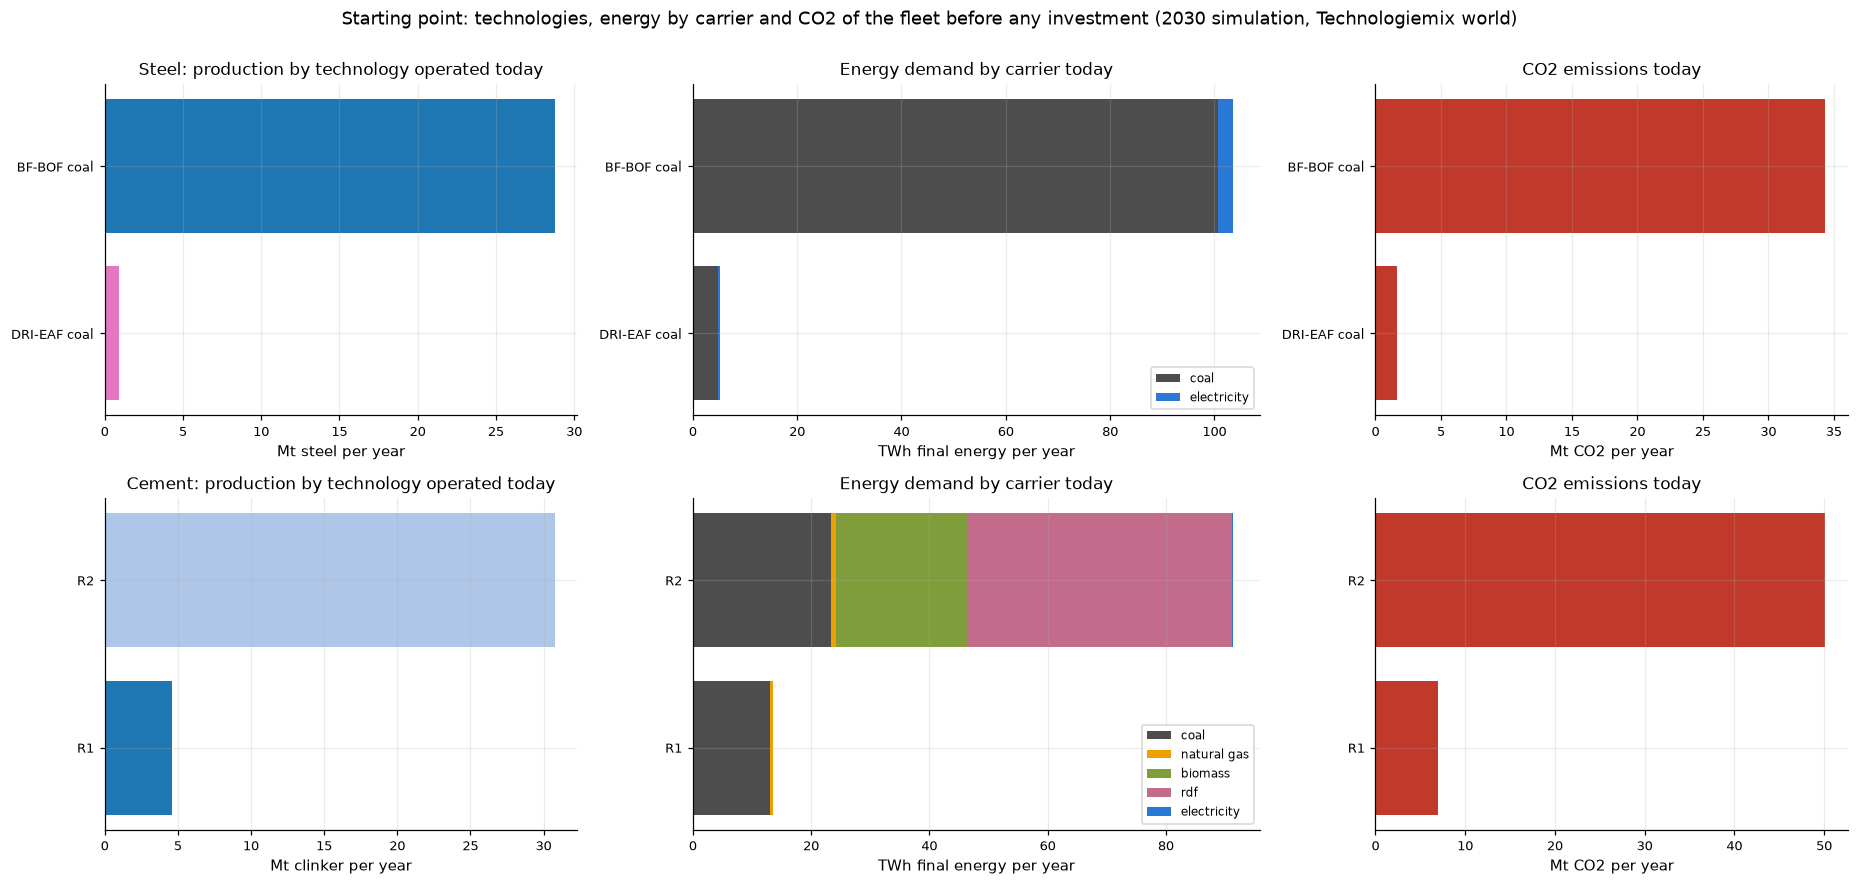

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(17, 8), gridspec_kw={"width_ratios": [1, 1.2, 1]})
for row, s in enumerate(SECTORS):
    f = FLEET0[s]
    g = f.groupby("technology")[["production_Mt", "co2_Mt", *[c + "_TWh" for c in CARRIERS]]].sum()
    g = g.loc[sorted(g.index, key=lambda t: -g.loc[t, "production_Mt"])]
    names = [tech_label(s, t) for t in g.index]
    y = np.arange(len(g))
    ax = axes[row, 0]
    ax.barh(y, g["production_Mt"], color=[TECH_COLOR[(s, t)] for t in g.index])
    ax.set_yticks(y, names); ax.invert_yaxis()
    ax.set_xlabel(f"Mt {SECTORS[s]['unit'].split(' ')[-1]} per year")
    ax.set_title(f"{SECTORS[s]['title']}: production by technology operated today")
    ax = axes[row, 1]
    left = np.zeros(len(g))
    for car in CARRIERS:
        v = g[car + "_TWh"].to_numpy()
        if v.sum() < 1e-9:
            continue
        ax.barh(y, v, left=left, color=CARRIER_COLOR[car], label=car.replace("_", " "))
        left += v
    ax.set_yticks(y, names); ax.invert_yaxis()
    ax.set_xlabel("TWh final energy per year")
    ax.set_title("Energy demand by carrier today")
    ax.legend(loc="lower right", fontsize=8)
    ax = axes[row, 2]
    ax.barh(y, g["co2_Mt"], color="#c0392b")
    ax.set_yticks(y, names); ax.invert_yaxis()
    ax.set_xlabel("Mt CO2 per year")
    ax.set_title("CO2 emissions today")
fig.suptitle(f"Starting point: technologies, energy by carrier and CO2 of the fleet before any investment ({CURRENT_YEAR} simulation, {MACRO_TITLE[CURRENT_WORLD]} world)", y=1.0)
fig.tight_layout()
plt.show()

**Key findings: the starting point**

* **Steel.** Nine plants produce 29.7 Mt of crude steel a year. Eight are coal-based BF-BOF plants (28.8 Mt, 97 percent of production), one is a coal-based DRI-EAF plant (0.9 Mt). Coal supplies 97 percent of the 109 TWh of final energy (3.6 MWh per tonne in BF-BOF), electricity only about 3 TWh. The plants emit 36 Mt CO2 a year, 1.2 t per t of steel.
* **Cement.** 32 plants produce 35.3 Mt of clinker a year. 27 of them (30.8 Mt) already burn the alternative-fuel mix of route R2 (coal 26 percent, biomass 24 percent, RDF 49 percent), five (4.6 Mt) run route R1 on coal. Final energy is 105 TWh (2.97 MWh per tonne): 35 percent coal, 21 percent biomass, 43 percent RDF, practically no electricity or hydrogen. The simulated CO2 is 57 Mt a year (1.6 t per t of clinker) and includes the biogenic CO2 of biomass and RDF; the carbon price charges only part of it.
* **What this means for the story.** Both sectors start with almost no electricity and no hydrogen. Every unit of electricity or hydrogen that appears in sections 6 and 7 is therefore the result of an adoption decision, and the CO2 of this fleet is the reference line against which the abatement of every case is measured (the no-investment line in section 7.5).

## 3. Future price developments: the scenario worlds

**Question.** The fleet of section 2 is almost entirely fossil. What it will be worth to keep or replace it depends on the future prices of electricity, fuels, hydrogen and CO2, and nobody knows which development will occur. The six macro scenarios below span the range that FLEXIMOD and AURIS consider. Technology economics (section 5) and therefore every investment decision (section 6) are functions of these prices, so they are built on them.

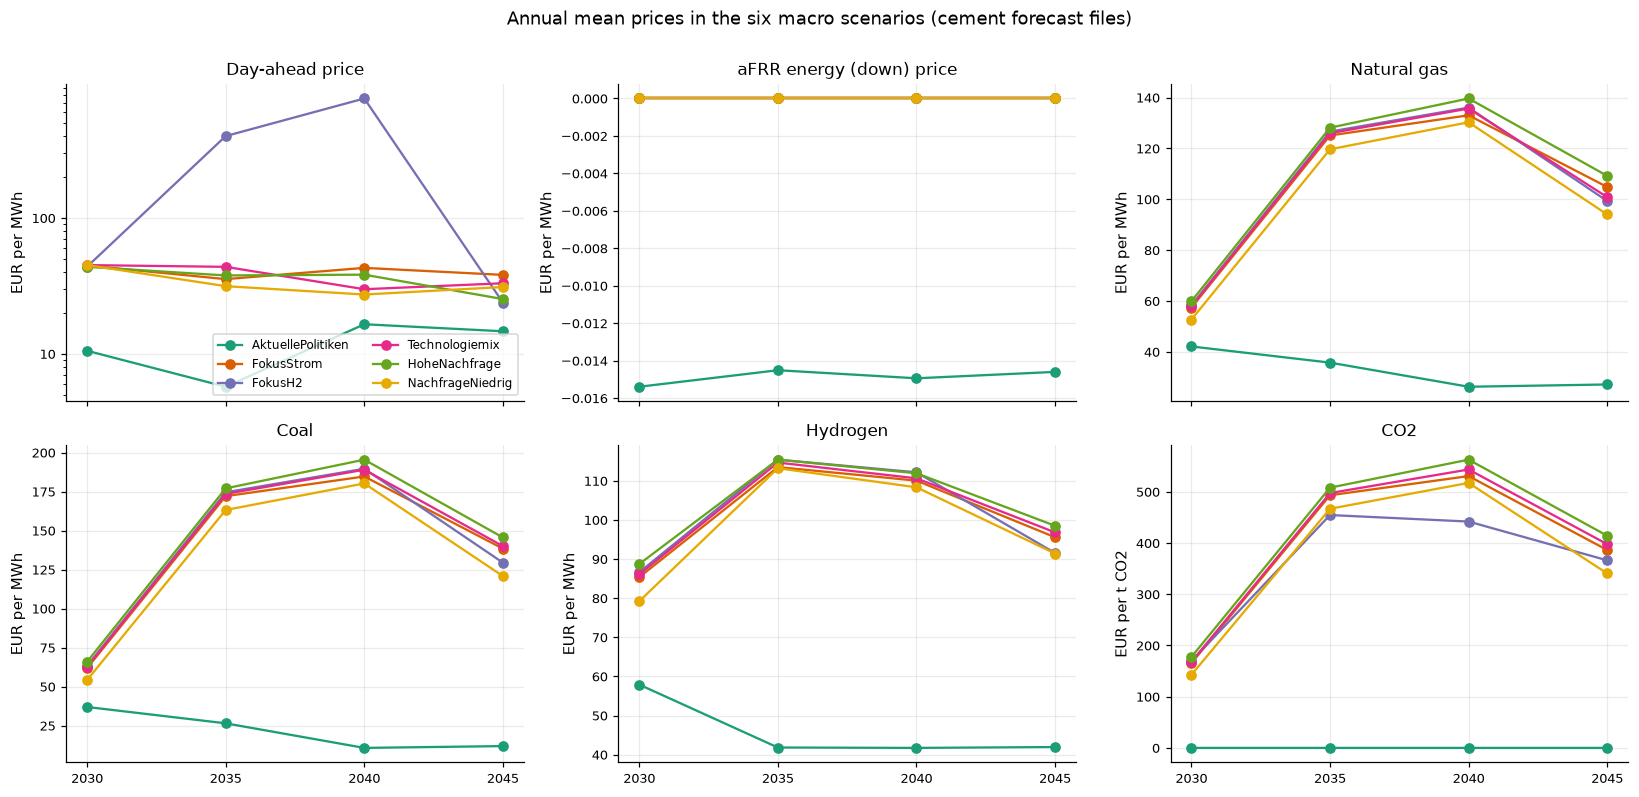

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7.2), sharex=True)
macro_color = dict(zip(MACROS, plt.get_cmap("Dark2").colors))
for ax, (col, title) in zip(axes.ravel(), PRICE_COLS.items()):
    for macro in MACROS:
        sub = price_annual[(price_annual.sector == "cement") & (price_annual.macro == macro)].sort_values("year")
        ax.plot(sub.year, sub[col], marker="o", color=macro_color[macro], label=MACRO_TITLE[macro])
    ax.set_title(title)
    ax.set_ylabel("EUR per MWh" if col != "co2_price" else "EUR per t CO2")
    ax.set_xticks(ANCHORS)
    if col == "DE_DA_price":
        ax.set_yscale("log")
        ax.yaxis.set_major_formatter(mtick.ScalarFormatter())
        ax.yaxis.set_minor_formatter(mtick.NullFormatter())
axes[0, 0].legend(ncol=2)
fig.suptitle("Annual mean prices in the six macro scenarios (cement forecast files)", y=1.0)
fig.tight_layout()
plt.show()

**The other price drivers.** The forecast files hold more than the six drivers above. Iron ore and lime are materials of the steel route; biomass, naphtha and refuse-derived fuel (RDF) are fuels of the cement routes; the aFRR capacity price is the revenue basis of reserve provision. Each is shown for the sector whose files contain it.

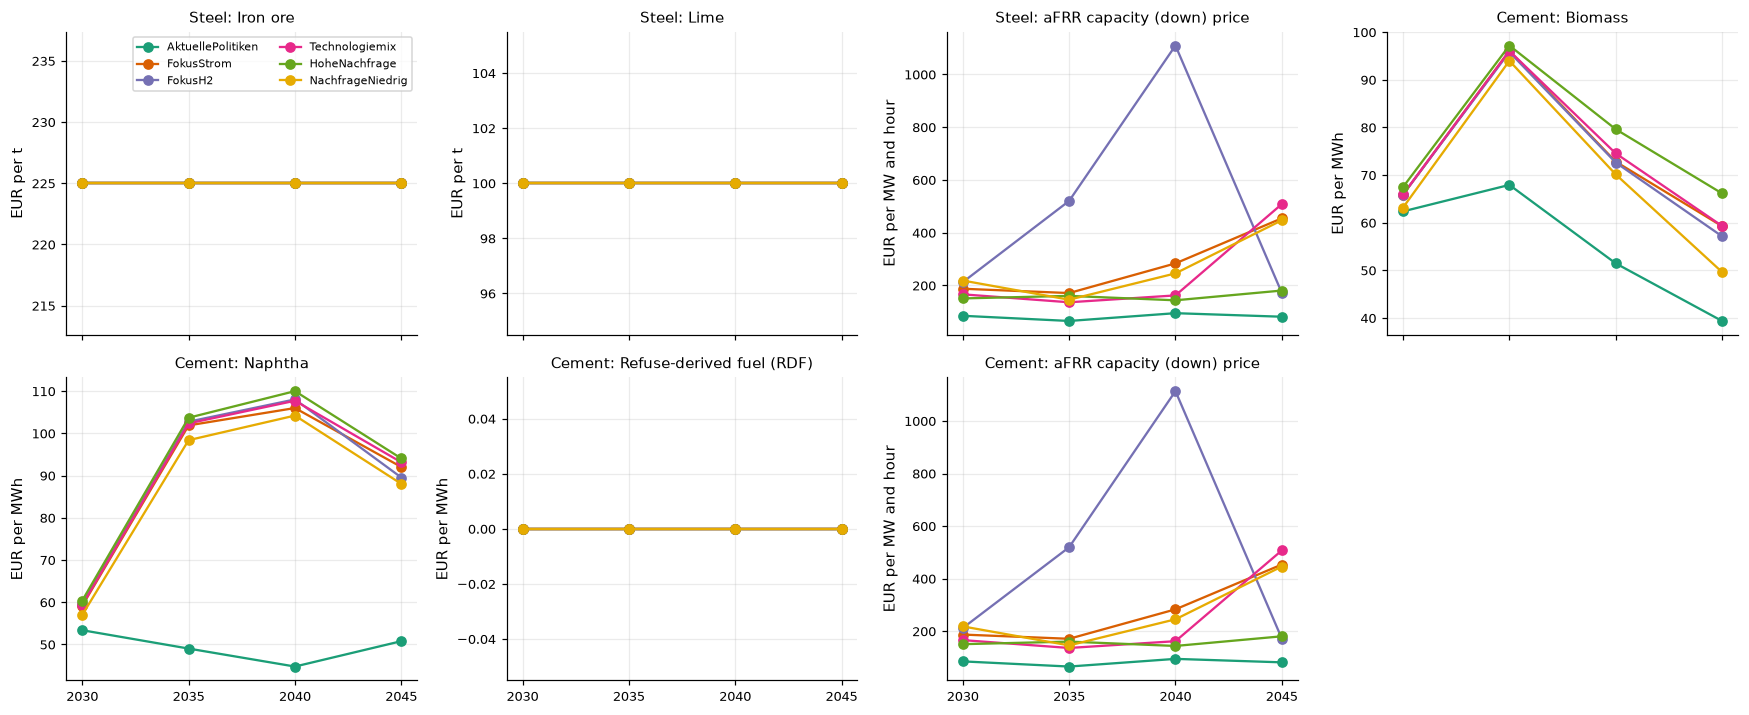

In [9]:
panels = [("steel", "iron_ore_price"), ("steel", "lime_price"), ("steel", "aFRR_capacity_down_price"),
          ("cement", "biomass_price"), ("cement", "naphtha_price"), ("cement", "rdf_price"), ("cement", "aFRR_capacity_down_price")]
fig, axes = plt.subplots(2, 4, figsize=(16, 6.6), sharex=True)
for ax in axes.ravel():
    ax.set_visible(False)
for ax, (sector, col) in zip(axes.ravel(), panels):
    ax.set_visible(True)
    for macro in MACROS:
        sub = price_annual[(price_annual.sector == sector) & (price_annual.macro == macro)].sort_values("year")
        ax.plot(sub.year, sub[col], marker="o", color=macro_color[macro], label=MACRO_TITLE[macro])
    ax.set_title(f"{SECTORS[sector]['title']}: {OTHER_PRICE_COLS[col][0]}", fontsize=10)
    ax.set_ylabel(OTHER_PRICE_COLS[col][1]); ax.set_xticks(ANCHORS)
axes[0, 0].legend(ncol=2, fontsize=7)
fig.tight_layout()
plt.show()

rows = []
for sector in SECTORS:
    for col in ALL_PRICE_COLS:
        sub = price_annual[(price_annual.sector == sector) & (price_annual.year == 2040)]
        if col in sub and sub[col].notna().any():
            name = PRICE_COLS.get(col) or OTHER_PRICE_COLS[col][0]
            rows.append({"sector": sector, "driver": name, **{MACRO_TITLE[m]: sub[sub.macro == m][col].iloc[0] for m in MACROS}})
display(pd.DataFrame(rows).set_index(["sector", "driver"]).style.format("{:,.1f}")
        .set_caption("All price drivers, annual mean in 2040 (EUR per MWh, per t for iron ore, lime and CO2)"))

In [10]:
# Steel and cement read separate forecast files. Check that they agree before treating the
# scenario drivers as common to both sectors.
cmp = price_annual.pivot_table(index=["macro", "year"], columns="sector", values=list(PRICE_COLS))
rows = []
for col, title in PRICE_COLS.items():
    diff = (cmp[(col, "steel")] - cmp[(col, "cement")]).abs()
    rel = diff / cmp[(col, "cement")].abs().replace(0, np.nan)
    rows.append({"driver": title, "max abs difference": diff.max(), "max relative difference": rel.max()})
price_consistency = pd.DataFrame(rows).set_index("driver")
display(price_consistency.style.format({"max abs difference": "{:,.2f}", "max relative difference": "{:.1%}"})
        .set_caption("Steel versus cement forecast inputs, annual means (should be ~0 if identical)"))

,max abs difference,max relative difference
driver,,
Day-ahead price,1.10,0.3%
aFRR energy (down) price,0.00,0.0%
Natural gas,0.00,0.0%
Coal,0.00,0.0%
Hydrogen,0.07,0.1%
CO2,104.87,22.4%


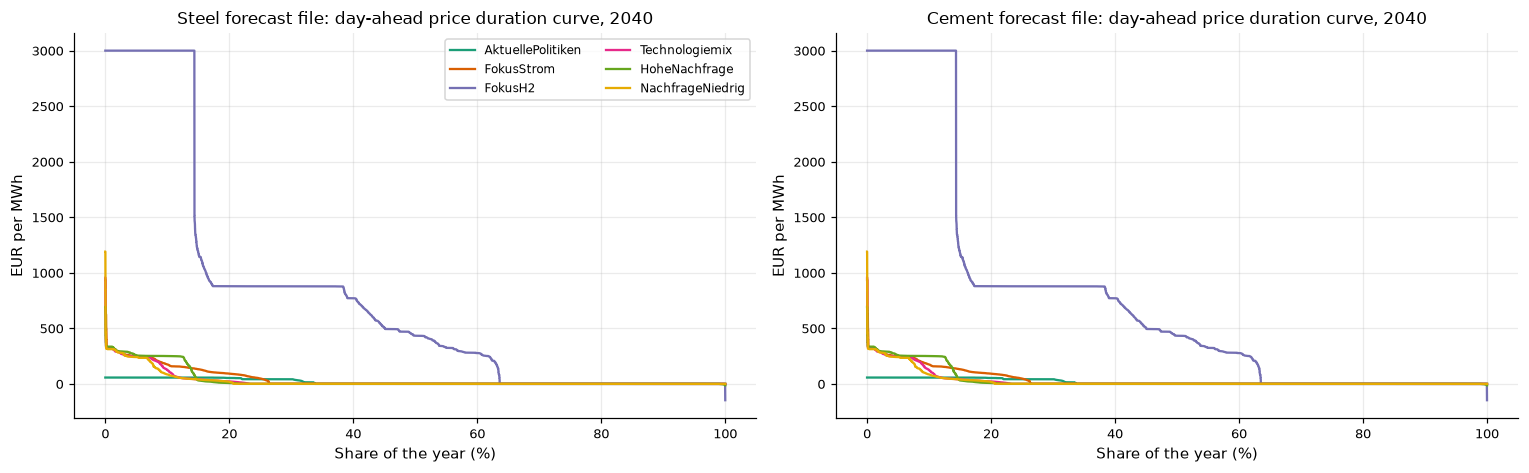

,mean,p10,p90,share_zero_or_negative,p90_minus_p10
macro,,,,,
AktuellePolitiken,16.5,0.0,56.4,66.3%,56.4
FokusH2,758.1,0.0,3000.0,36.5%,3000.0
FokusStrom,42.9,0.0,174.2,73.4%,174.2
HoheNachfrage,38.3,0.0,250.5,78.3%,250.5
NachfrageNiedrig,27.3,0.0,84.5,79.2%,84.5
Technologiemix,29.9,0.0,123.5,76.8%,123.5


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
for ax, sector in zip(axes, SECTORS):
    for macro in MACROS:
        d = PRICES[sector]
        da = d[(d.macro == macro) & (d.year == 2040)]["DE_DA_price"].sort_values(ascending=False).to_numpy()
        ax.plot(np.linspace(0, 100, len(da)), da, color=macro_color[macro], label=MACRO_TITLE[macro])
    ax.set_title(f"{SECTORS[sector]['title']} forecast file: day-ahead price duration curve, 2040")
    ax.set_xlabel("Share of the year (%)")
    ax.set_ylabel("EUR per MWh")
axes[0].legend(ncol=2)
fig.tight_layout()
plt.show()

spread = (PRICES["cement"][PRICES["cement"].year == 2040]
          .groupby("macro")["DE_DA_price"].agg(mean="mean", p10=lambda s: s.quantile(.1), p90=lambda s: s.quantile(.9),
                                               share_zero_or_negative=lambda s: (s <= 0).mean()))
spread["p90_minus_p10"] = spread["p90"] - spread["p10"]
display(spread.rename(index=MACRO_TITLE).style.format({"mean": "{:.1f}", "p10": "{:.1f}", "p90": "{:.1f}",
                                                       "share_zero_or_negative": "{:.1%}", "p90_minus_p10": "{:.1f}"})
        .set_caption("Cement forecast file, 2040 day-ahead price distribution"))

**Key findings: scenario drivers**

* **AktuellePolitiken is a different world, not a variation.** Its CO2 price is zero in every year, gas costs 26 to 42 EUR/MWh, coal 11 to 37 and hydrogen 42 to 58, and the mean day-ahead price is only 6 to 17 EUR/MWh. In the other five scenarios the CO2 price rises from 143 to 178 EUR/t in 2030 to 442 to 563 EUR/t in 2035 to 2040, and falls to 341 to 414 EUR/t in 2045; gas rises from 52 to 60 to 120 to 140 EUR/MWh.
* **FokusH2 is a scarcity world.** Its mean day-ahead price is 44, 401, 758 and 24 EUR/MWh in 2030, 2035, 2040 and 2045. In 2035 29 percent of all hours and in 2040 16 percent are at or above 1000 EUR/MWh (the series is capped at 3000 EUR/MWh). In every other scenario the price is zero or negative in 66 to 79 percent of the hours of 2040 (36 percent in FokusH2).
* **aFRR energy has no price signal.** The aFRR down-energy price is zero in all scenarios (about minus 0.015 EUR/MWh in AktuellePolitiken), so these runs give no price incentive to aFRR energy.
* **The remaining drivers.** Iron ore (225 EUR/t) and lime (100 EUR/t) are constant in every scenario and year; refuse-derived fuel is free (0). Biomass ranges from 39 to 97 EUR/MWh (lowest in AktuellePolitiken) and naphtha from 45 to 110 EUR/MWh. The aFRR capacity-down price ranges from about 65 EUR/MW and hour (AktuellePolitiken) to 1,110 (FokusH2 in 2040, after 520 in 2035 and before 170 in 2045).
* **Data flag.** Steel and cement forecast files agree on day-ahead, fuel and hydrogen prices to within 0.3 percent, but the CO2 price differs by up to 105 EUR/t (22 percent), mostly in 2030 and 2040 for FokusH2, FokusStrom and Technologiemix. Steel sees the lower value. This should be harmonised before final results are quoted.

## 4. Beliefs: how investors weigh the price worlds

Each risk-neutral case has one belief vector, which puts about 56 percent on its own macro scenario and about 6 percent on each other one (AktuellePolitiken puts 62.5 percent on itself). The risk-averse cases use the whole set of belief vectors and protect against the worst of them.

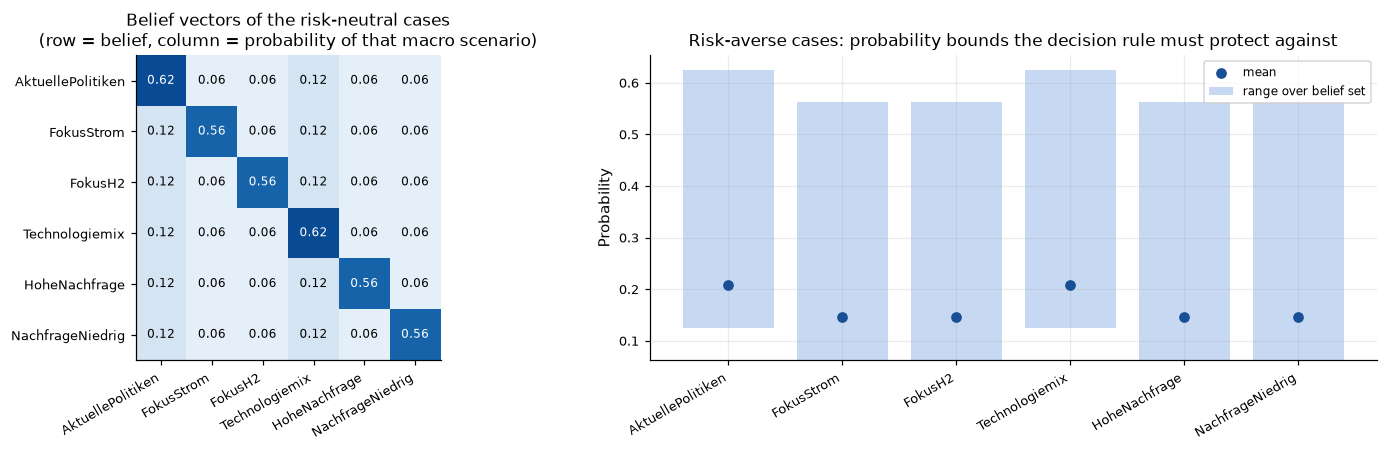

In [12]:
prob = pd.read_csv(SECTORS["cement"]["auris_in"] / "Technologiemix_risk_neutral/scenarios/scenario_probabilities.csv").set_index("scenario_id")
prob.columns = [c.replace("B_", "") for c in prob.columns]
P = prob.loc[MACROS, [MACRO_TITLE[m] for m in MACROS]].T   # rows = belief, columns = macro scenario
P.columns = [MACRO_TITLE[m] for m in MACROS]
P.index.name = "belief"
check_steel = pd.read_csv(SECTORS["steel"]["auris_in"] / "Technologiemix_risk_neutral/scenarios/scenario_probabilities.csv").set_index("scenario_id")
assert np.allclose(check_steel.loc[MACROS].to_numpy(), prob.loc[MACROS].to_numpy()), "steel and cement beliefs differ"

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), gridspec_kw={"width_ratios": [1.1, 1]})
im = axes[0].imshow(P.to_numpy(), cmap="Blues", vmin=0, vmax=0.7)
axes[0].set_xticks(range(6), [MACRO_TITLE[m] for m in MACROS], rotation=30, ha="right")
axes[0].set_yticks(range(6), P.index)
for i in range(6):
    for j in range(6):
        axes[0].text(j, i, f"{P.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8,
                     color="white" if P.iloc[i, j] > 0.35 else "black")
axes[0].set_title("Belief vectors of the risk-neutral cases\n(row = belief, column = probability of that macro scenario)")
axes[0].grid(False)
bs = AUR["steel"][CASES[6]]["beliefs"].set_index("scenario").loc[MACROS]
x = np.arange(6)
axes[1].bar(x, bs["p_upper"] - bs["p_lower"], bottom=bs["p_lower"], color="#c7d9f2", label="range over belief set")
axes[1].scatter(x, bs["p_mean"], color="#184f95", zorder=3, label="mean")
axes[1].set_xticks(x, [MACRO_TITLE[m] for m in MACROS], rotation=30, ha="right")
axes[1].set_ylabel("Probability")
axes[1].set_title("Risk-averse cases: probability bounds the decision rule must protect against")
axes[1].legend()
fig.tight_layout()
plt.show()

## 5. Technology economics: what each option costs and burns in each world

**Question.** Given the scenario prices, what does each technology cost, burn and emit per tonne of product? This is the *unit economics* that the investment model compares. If a technology wins a decision, the reason must be visible here (cheap energy mix, low CO2 exposure) or in the CAPEX of section 6.

**All cost components.** For every plant, technology, macro scenario and anchor year the operating cost is rebuilt as *quantity times scenario price*, component by component:

| Component | Quantity (FLEXIMOD simulation) | Price |
|---|---|---|
| Coal, natural gas, biomass, RDF | fuel use, MWh | fuel price of the scenario |
| Bought hydrogen | hydrogen use, MWh (zero when an on-site electrolyser makes it) | hydrogen price |
| Iron ore, lime (steel) | tonnes used | material price |
| CO2 allowances | CO2 that is charged, t (after capture, excluding biogenic CO2) | CO2 price |
| Electricity market | day-ahead and aFRR energy settlement | recorded in the simulation |
| Grid fees and levies | per-MWh charges | recorded in the simulation |
| Hydrogen and gas network charges | peak withdrawal, kW | 25 and 7.06 EUR per kW and year |
| Electricity grid capacity charge | peak power, kW | 11.39 or 53.06 EUR per kW and year, reduced to 20, 15 or 10 percent at 7000, 7500 or 8000 full-load hours |
| Annualised CAPEX | AURIS CAPEX per plant | 5 percent annuity over the technology life |

The first eight lines add up to FLEXIMOD's *process cost*; with the next two they equal its *gross operating cost*. Both identities are checked below (column *other / unexplained*). The AURIS cost input is then compared with the sum of all operating components.

In [13]:
H2_NETWORK_TARIFF = 25.0       # EUR per kW and year, bought hydrogen
GAS_NETWORK_TARIFF = 7.06      # EUR per kW and year
GRID_TARIFF_LOW, GRID_TARIFF_HIGH = 11.39, 53.06   # EUR per kW and year, below / from 2500 full-load hours


def hydrogen_is_bought(sector: str, tech: str) -> bool:
    return not (tech.endswith("electrolyser") if sector == "steel" else tech.endswith("b"))


def annuity_factor(years: float, rate: float = DISCOUNT_RATE) -> float:
    return rate / (1 - (1 + rate) ** -years)


def auris_parameters(sector: str, parameters: list[str]) -> pd.DataFrame:
    f = SECTORS[sector]["auris_in"] / "Technologiemix_risk_neutral/scenarios/scenarios.csv"
    d = pd.read_csv(f, usecols=["scenario_id", "plant_id", "technology_id", "year", "parameter", "value"])
    d = d[d.year.isin(ANCHORS) & d.parameter.isin(parameters)]
    out = d.pivot_table(index=["scenario_id", "plant_id", "technology_id", "year"], columns="parameter", values="value").reset_index()
    return out.rename(columns={"scenario_id": "macro", "technology_id": "technology"})


COMPONENTS = ["coal", "natural gas", "biomass", "RDF", "bought hydrogen", "iron ore", "lime", "CO2 allowances",
              "electricity market (DA + aFRR)", "grid fees and levies", "other / unexplained",
              "network and capacity charges"]


def build_costs(sector: str) -> pd.DataFrame:
    d = SIM[sector].merge(price_annual[price_annual.sector == sector].drop(columns="sector"), on=["macro", "year"], how="left")
    bought = d["technology"].map(lambda t: hydrogen_is_bought(sector, t)).astype(float)
    price = lambda col: d[col] if col in d else 0.0
    c = pd.DataFrame(index=d.index)
    c["coal"] = d["total_coal_consumption_MWh"] * d["coal_price"]
    c["natural gas"] = d["total_natural_gas_consumption_MWh"] * d["natural_gas_price"]
    c["biomass"] = d["biomass_MWh"] * price("biomass_price")
    c["RDF"] = d["rdf_MWh"] * price("rdf_price")
    c["bought hydrogen"] = d["total_hydrogen_consumption_MWh"] * d["hydrogen_price"] * bought
    c["iron ore"] = d["total_iron_ore_consumption_t"] * d["iron_ore_price"] if sector == "steel" else 0.0
    c["lime"] = d["total_lime_consumption_t"] * d["lime_price"] if sector == "steel" else 0.0
    c["CO2 allowances"] = d["co2_charged_t"] * d["co2_price"]
    c["electricity market (DA + aFRR)"] = d["total_electricity_market_cost_EUR"]
    c["grid fees and levies"] = d["total_additional_electricity_charges_cost_EUR"]
    explained = c[["coal", "natural gas", "biomass", "RDF", "bought hydrogen", "iron ore", "lime", "CO2 allowances"]].sum(axis=1)
    c["other / unexplained"] = d["process_cost_EUR"] - explained
    flh = d["total_electricity_consumption_MWh"] / d["peak_el_MW"].replace(0, np.nan)
    tariff = np.where(flh >= 2500, GRID_TARIFF_HIGH, GRID_TARIFF_LOW) * np.select([flh >= 8000, flh >= 7500, flh >= 7000], [0.10, 0.15, 0.20], 1.0)
    c["network and capacity charges"] = (d["peak_h2_MW"] * 1000 * H2_NETWORK_TARIFF * bought + d["peak_gas_MW"] * 1000 * GAS_NETWORK_TARIFF
                                         + d["peak_el_MW"] * 1000 * np.nan_to_num(tariff))
    c["operating cost"] = c[COMPONENTS].sum(axis=1)
    c["gross_operating_cost_EUR"] = d["gross_operating_cost_EUR"]
    capex = auris_parameters(sector, ["capex"])
    life = pd.read_csv(SECTORS[sector]["auris_in"] / "Technologiemix_risk_neutral/technology.csv").set_index("technology")["depreciation_period_years"]
    keys = d[["macro", "plant_id", "technology", "year"]]
    cap = keys.merge(capex, on=["macro", "plant_id", "technology", "year"], how="left")["capex"].to_numpy()
    c["annualised CAPEX"] = cap * d["technology"].map(life).map(annuity_factor).to_numpy()
    out = pd.concat([d[["plant_id", "macro", "year", "technology", "production_t"]], c], axis=1)
    out["sector"] = sector
    return out


COST = {s: build_costs(s) for s in SECTORS}

**The numbers behind the chart below.** These are the section 3 prices for the world and year the next chart uses (2040, the reference world); every bar segment in that chart is one of these prices times the matching FLEXIMOD quantity. The table's own caption below names the world.

In [14]:
bridge = price_annual[(price_annual.year == 2040) & (price_annual.macro == REFERENCE_MACRO)].set_index("sector")
cols = [c for c in [*PRICE_COLS, *OTHER_PRICE_COLS] if c in bridge.columns]
display(bridge[cols].rename(columns={**PRICE_COLS, **{k: v[0] for k, v in OTHER_PRICE_COLS.items()}}).T
        .style.format("{:,.1f}", na_rep="-").set_caption(f"2040, {MACRO_TITLE[REFERENCE_MACRO]}: the prices that price x quantity turns into the cost components below"))

sector,steel,cement
Day-ahead price,16.6,16.5
aFRR energy (down) price,-0.0,-0.0
Natural gas,26.3,26.3
Coal,10.7,10.7
Hydrogen,41.7,41.7
CO2,-0.0,-0.0
aFRR capacity (down) price,94.9,94.8
Iron ore,225.0,-
Lime,100.0,-
Biomass,-,51.5


{'steel': ['bf_bof_hybrid_hydrogen_natural_gas_external', 'bf_bof_hydrogen_electrolyser', 'dri_bof_hybrid_hydrogen_natural_gas_external', 'dri_eaf_hybrid_hydrogen_natural_gas_external', 'dri_eaf_hydrogen_electrolyser'], 'cement': ['R11a', 'R15a', 'R4', 'R8', 'R9']}


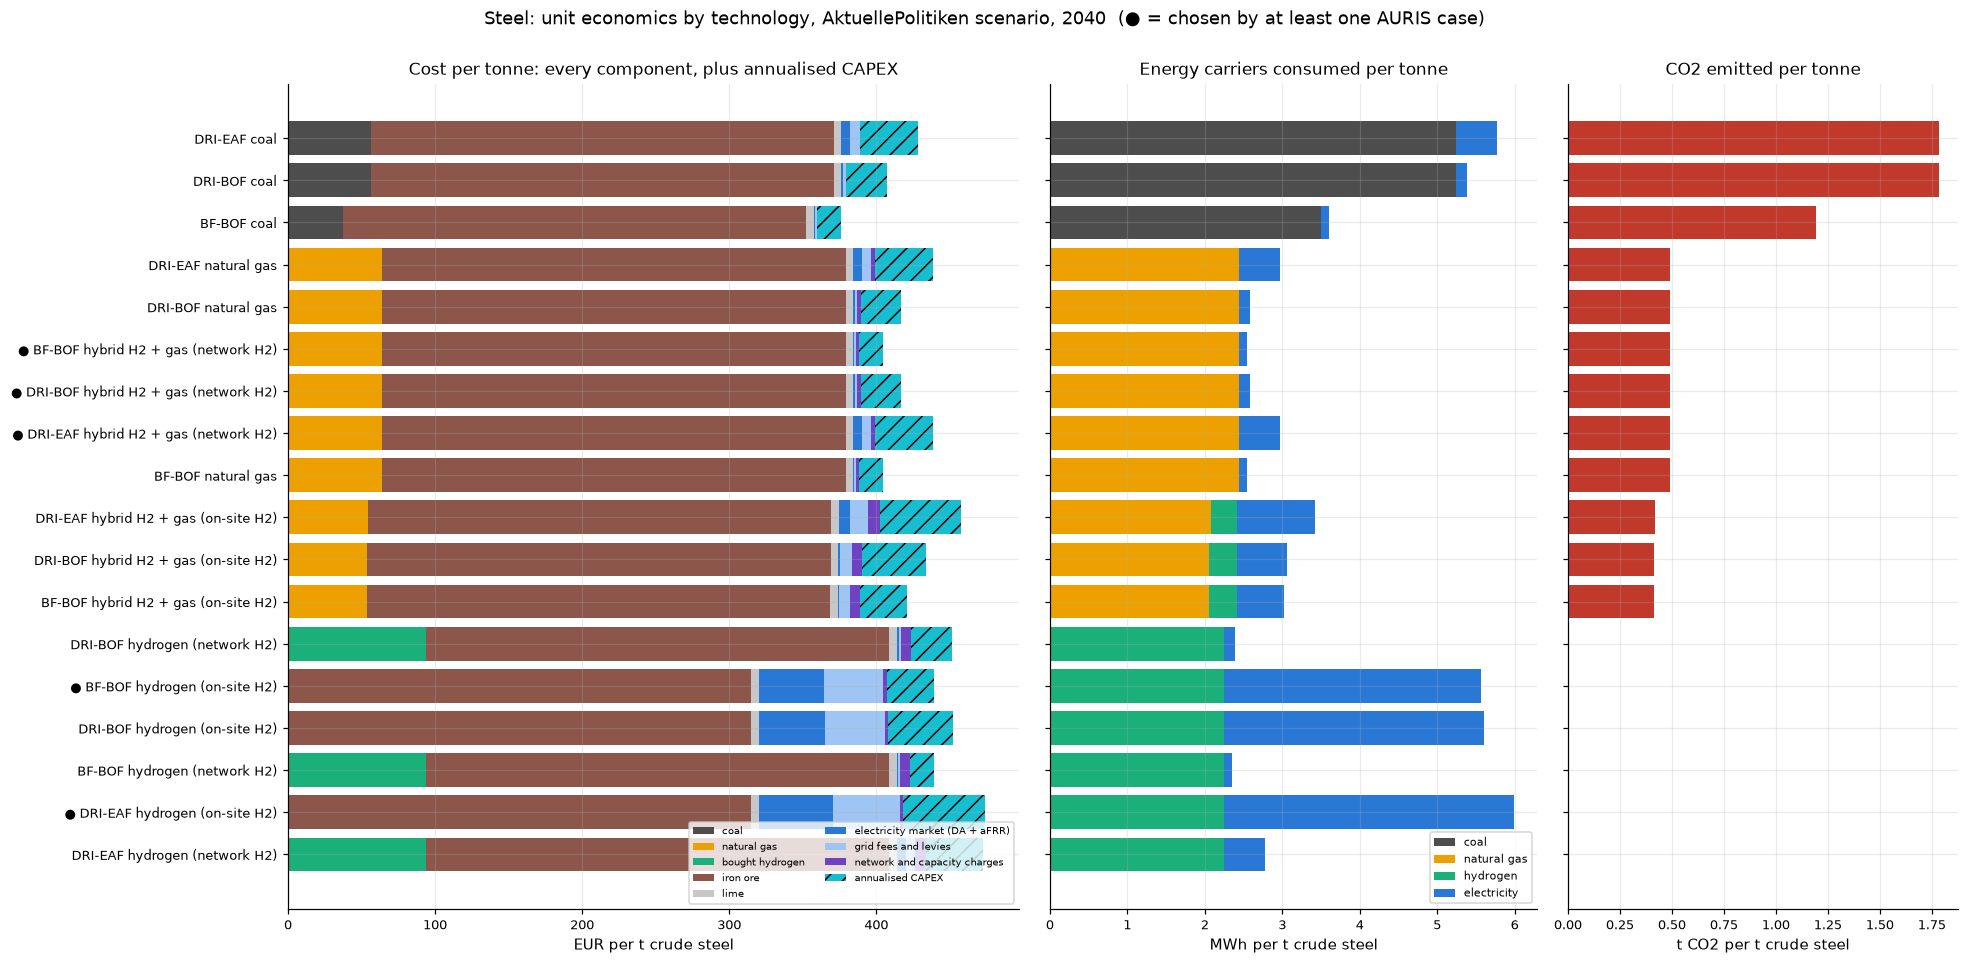

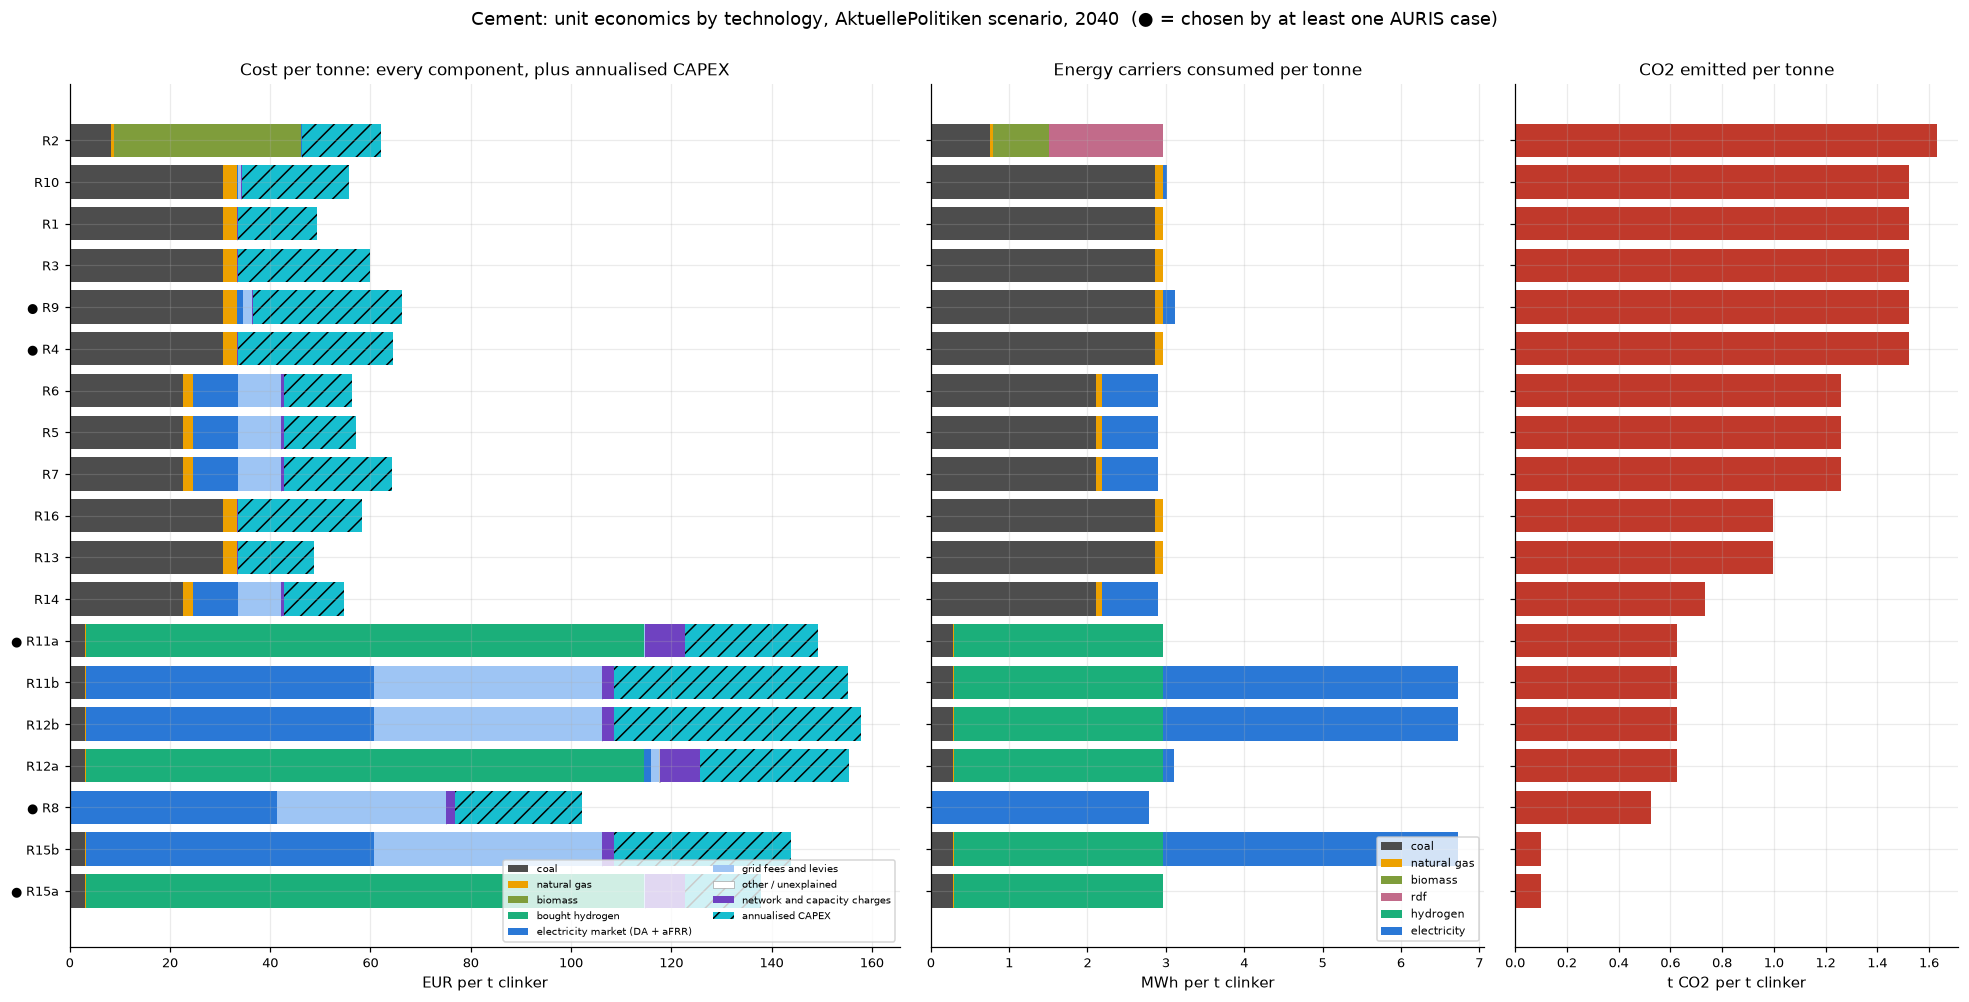

,natural gas,iron ore,lime,CO2 allowances,electricity market (DA + aFRR),grid fees and levies,other / unexplained,network and capacity charges,annualised CAPEX,operating cost
BF-BOF hybrid H2 + gas (network H2),64.1,315.0,5.0,-0.0,0.9,1.2,-0.0,2.2,16.1,388.4
BF-BOF hydrogen (on-site H2),0.0,315.0,5.0,-0.0,44.7,40.1,-0.0,2.2,32.1,407.0
DRI-BOF hybrid H2 + gas (network H2),64.1,315.0,5.0,-0.0,1.3,1.7,-0.0,2.2,27.8,389.3
DRI-EAF hybrid H2 + gas (network H2),64.1,315.0,5.0,-0.0,6.2,6.4,-0.0,2.5,39.1,399.2
DRI-EAF hydrogen (on-site H2),0.0,315.0,5.0,-0.0,50.7,45.3,-0.0,2.5,55.1,418.5


,coal,natural gas,bought hydrogen,CO2 allowances,electricity market (DA + aFRR),grid fees and levies,other / unexplained,network and capacity charges,annualised CAPEX,operating cost
R11a,3.1,0.3,111.2,-0.0,0.1,0.1,0.1,8.0,26.4,122.8
R15a,3.1,0.3,111.2,-0.0,0.1,0.1,0.1,8.0,15.2,122.8
R4,30.6,2.6,0.0,-0.0,0.1,0.1,-0.0,0.1,30.9,33.5
R8,0.0,0.0,0.0,-0.0,41.3,33.7,-0.0,1.8,25.3,76.8
R9,30.6,2.6,0.0,-0.0,1.3,1.8,-0.0,0.2,29.7,36.6


In [15]:
def pathway_techs(sector: str) -> set[str]:
    return set().union(*[set(AUR[sector][c]["pathway"].active_technology_id) for c in CASES])


USED = {s: pathway_techs(s) for s in SECTORS}
print({s: sorted(v) for s, v in USED.items()})

COMPONENT_COLOR = {
    "coal": "#4d4d4d", "natural gas": "#eda100", "biomass": "#7f9d3b", "RDF": "#c26b8a", "bought hydrogen": "#1baf7a",
    "iron ore": "#8c564b", "lime": "#c7c7c7", "CO2 allowances": "#c0392b",
    "electricity market (DA + aFRR)": "#2a78d6", "grid fees and levies": "#9ec5f4", "other / unexplained": "#ffffff",
    "network and capacity charges": "#6f42c1", "annualised CAPEX": "#17becf",
}


def unit_economics(sector: str, macro: str, year: int) -> pd.DataFrame:
    c = COST[sector]
    c = c[(c.macro == macro) & (c.year == year)]
    g = c.groupby("technology").sum(numeric_only=True)
    t = g["production_t"]
    out = pd.DataFrame(index=g.index)
    for col in [*COMPONENTS, "annualised CAPEX", "operating cost"]:
        out[col] = g[col] / t
    out["total_cost"] = g["gross_operating_cost_EUR"] / t       # FLEXIMOD gross operating cost
    d = SIM[sector]
    d = d[(d.macro == macro) & (d.year == year)].groupby("technology").sum(numeric_only=True)
    for car, col in CARRIER_COL.items():
        out[f"{car}_MWh_per_t"] = d[col] / t
    out["co2_t_per_t"] = d["total_co2_emissions_t"] / t
    out["production_Mt"] = t / 1e6
    return out


def plot_unit_economics(sector: str, macro: str, year: int):
    ue = unit_economics(sector, macro, year).sort_values("co2_t_per_t", ascending=False)
    labels = [("● " if t in USED[sector] else "   ") + tech_label(sector, t) for t in ue.index]
    fig, axes = plt.subplots(1, 3, figsize=(18, 0.34 * len(ue) + 2.6), sharey=True, gridspec_kw={"width_ratios": [1.5, 1, 0.8]})
    y = np.arange(len(ue))
    left = np.zeros(len(ue))
    for col in [*COMPONENTS, "annualised CAPEX"]:
        vals = ue[col].clip(lower=0).to_numpy()
        if vals.sum() <= 0:
            continue
        axes[0].barh(y, vals, left=left, color=COMPONENT_COLOR[col], edgecolor="#999999" if col == "other / unexplained" else None,
                     linewidth=0.4, label=col, hatch="//" if col == "annualised CAPEX" else None)
        left += vals
    axes[0].set_title("Cost per tonne: every component, plus annualised CAPEX")
    axes[0].set_xlabel(f"EUR per {SECTORS[sector]['unit']}")
    axes[0].legend(loc="lower right", fontsize=6.8, ncol=2)
    left = np.zeros(len(ue))
    for car in CARRIERS:
        v = ue[f"{car}_MWh_per_t"].to_numpy()
        if v.sum() <= 0:
            continue
        axes[1].barh(y, v, left=left, color=CARRIER_COLOR[car], label=car.replace("_", " "))
        left += v
    axes[1].set_title("Energy carriers consumed per tonne"); axes[1].set_xlabel(f"MWh per {SECTORS[sector]['unit']}")
    axes[1].legend(loc="lower right", fontsize=7)
    axes[2].barh(y, ue["co2_t_per_t"], color="#c0392b")
    axes[2].set_title("CO2 emitted per tonne"); axes[2].set_xlabel(f"t CO2 per {SECTORS[sector]['unit']}")
    axes[0].set_yticks(y, labels)
    axes[0].invert_yaxis()
    fig.suptitle(f"{SECTORS[sector]['title']}: unit economics by technology, {MACRO_TITLE[macro]} scenario, {year}  "
                 "(● = chosen by at least one AURIS case)", y=1.0)
    fig.tight_layout()
    plt.show()
    return ue


UE = {s: plot_unit_economics(s, REFERENCE_MACRO, 2040) for s in SECTORS}

# the same numbers as a table, for the technologies that AURIS actually selects
for s in SECTORS:
    t = UE[s].loc[sorted(USED[s]), [*COMPONENTS, "annualised CAPEX", "operating cost"]].copy()
    t.index = [tech_label(s, i) for i in t.index]
    t = t.loc[:, (t.abs() > 1e-9).any(axis=0)]
    display(t.style.format("{:,.1f}").set_caption(f"{SECTORS[s]['title']}: cost components of the technologies selected by AURIS, EUR per {SECTORS[s]['unit']}, 2040, {MACRO_TITLE[REFERENCE_MACRO]} world"))

### 5.1 Energy mix of every configuration: share of each carrier and energy per tonne

Before the scenarios decide *which* technology is cheapest, it helps to see *what each configuration physically burns*. The two panels per sector answer this for **all** technology options (not only the ones AURIS chooses), in the reference world and for 2040:

* **Left, share of final energy.** The percentage of each carrier (coal, natural gas, biomass, refuse-derived fuel RDF, hydrogen, electricity) in the final energy that the configuration consumes per tonne of product. This is the configuration's *fuel signature*: it shows how exposed the technology is to each price.
* **Right, energy per tonne.** The same split in absolute terms, in MWh per tonne of crude steel (steel) and MWh per tonne of clinker (cement). The bar length is the energy intensity; the sum of the numbers printed at the bar end is the total.

Variants with an **on-site electrolyser** (hatched hydrogen) produce their hydrogen from electricity that is already counted as electricity, so hydrogen and electricity overlap for them. Compare shares across technologies with that in mind; for the bought-hydrogen variants no overlap exists. Technologies marked ● are chosen by at least one AURIS case. Quantities are the plant-level simulation results divided by the production of the same technology (steel: tonnes of steel, cement: tonnes of clinker).

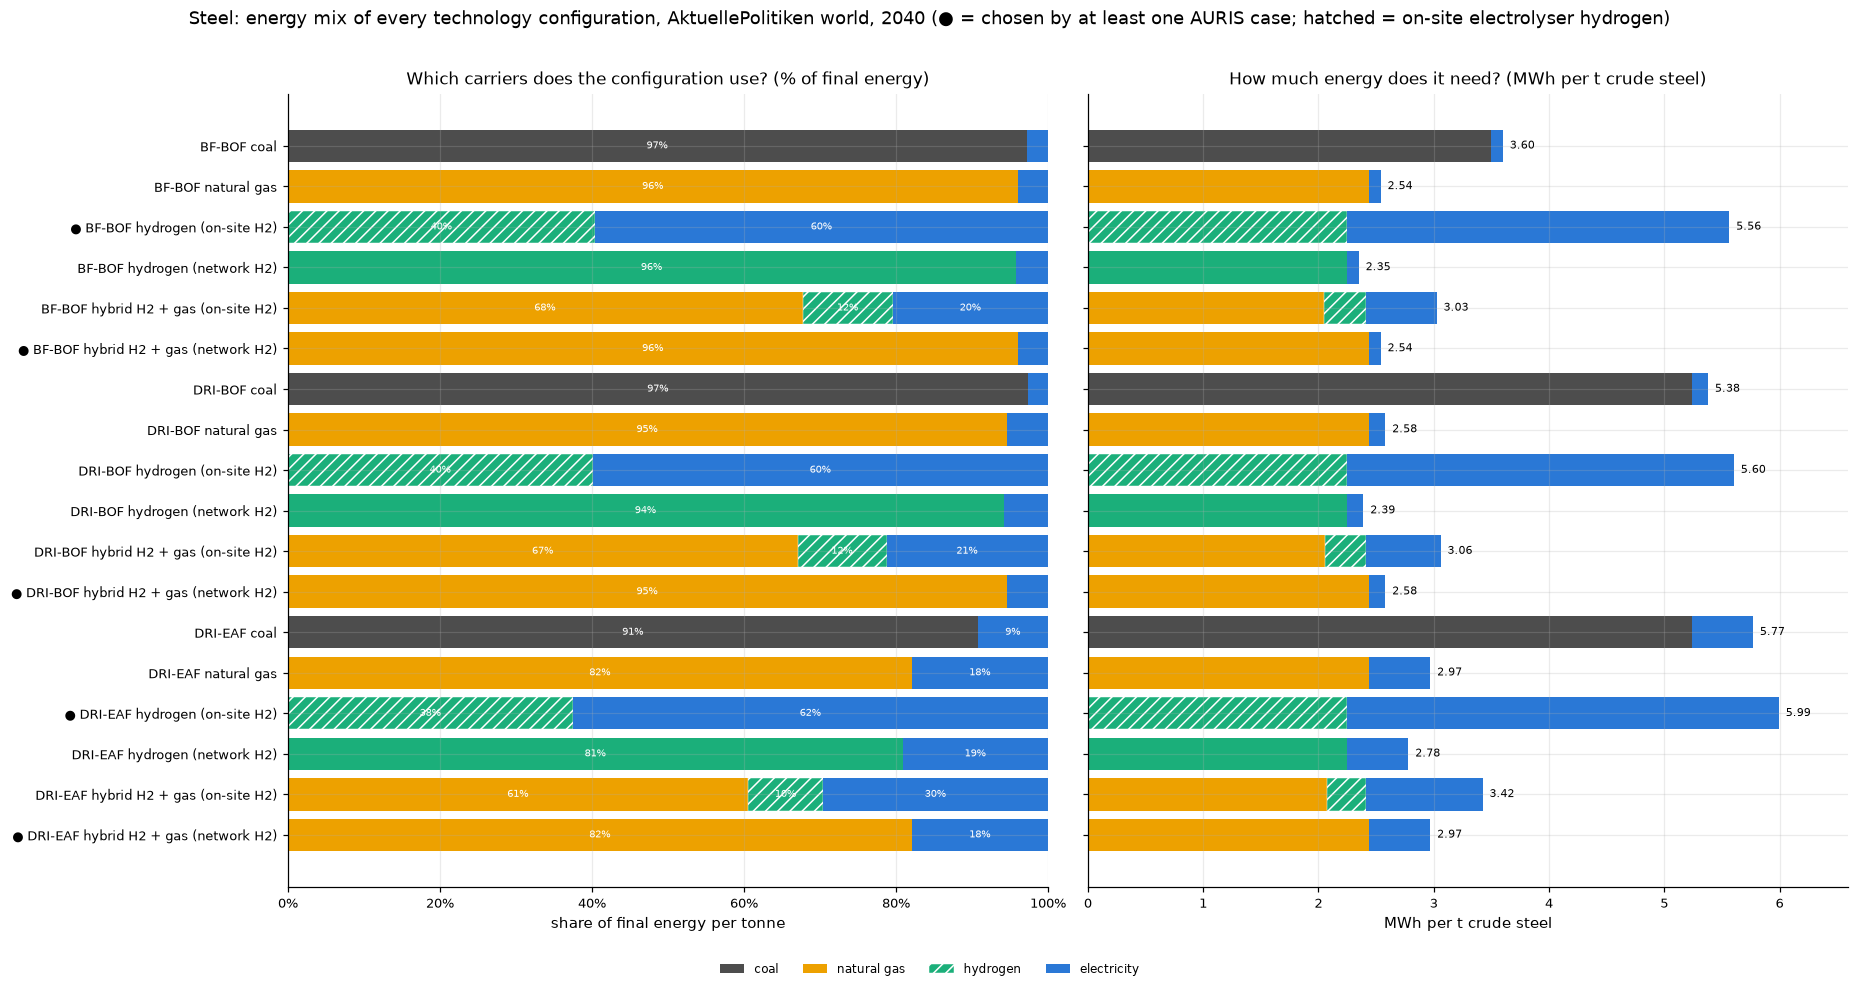

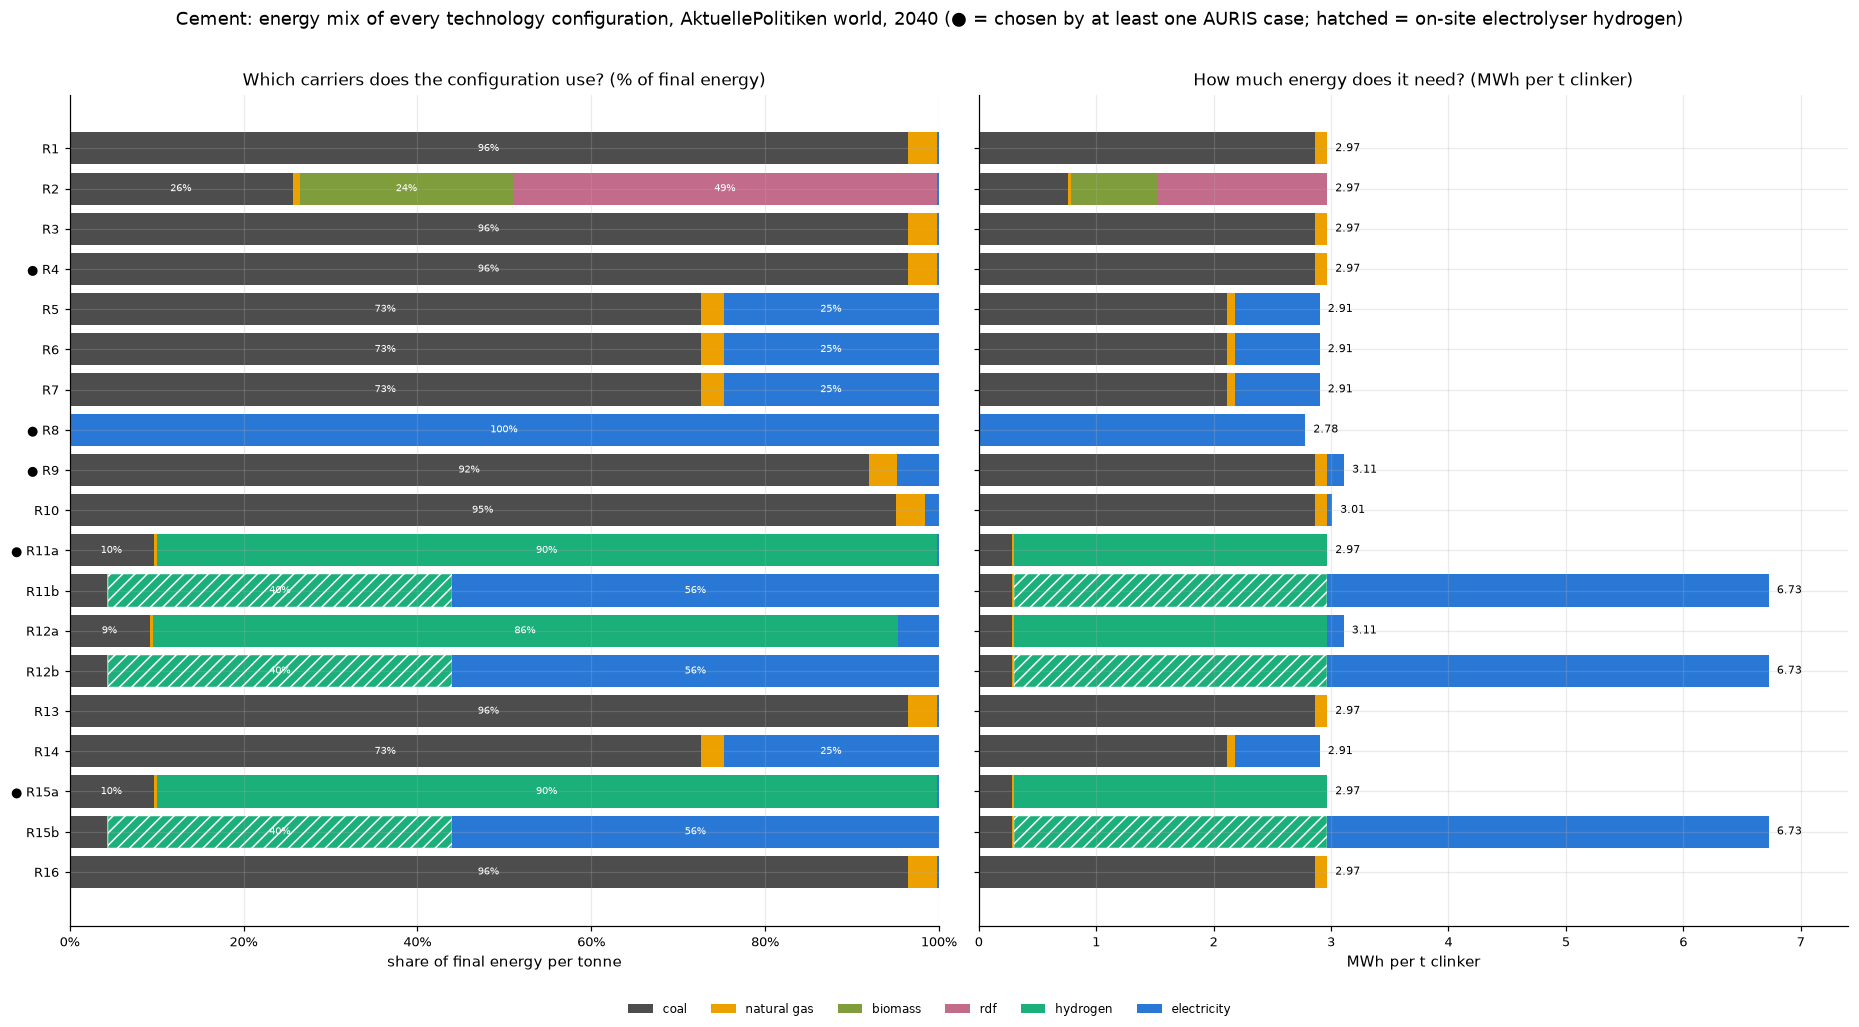

,MWh per t crude steel,coal share,natural gas share,biomass share,rdf share,hydrogen share,electricity share
BF-BOF coal,3.60,97%,0%,0%,0%,0%,3%
BF-BOF natural gas,2.54,0%,96%,0%,0%,0%,4%
BF-BOF hydrogen (on-site H2),5.56,0%,0%,0%,0%,40%,60%
BF-BOF hydrogen (network H2),2.35,0%,0%,0%,0%,96%,4%
BF-BOF hybrid H2 + gas (on-site H2),3.03,0%,68%,0%,0%,12%,20%
BF-BOF hybrid H2 + gas (network H2),2.54,0%,96%,0%,0%,0%,4%
DRI-BOF coal,5.38,97%,0%,0%,0%,0%,3%
DRI-BOF natural gas,2.58,0%,95%,0%,0%,0%,5%
DRI-BOF hydrogen (on-site H2),5.60,0%,0%,0%,0%,40%,60%
DRI-BOF hydrogen (network H2),2.39,0%,0%,0%,0%,94%,6%


,MWh per t clinker,coal share,natural gas share,biomass share,rdf share,hydrogen share,electricity share
R1,2.97,96%,3%,0%,0%,0%,0%
R2,2.97,26%,1%,24%,49%,0%,0%
R3,2.97,96%,3%,0%,0%,0%,0%
R4,2.97,96%,3%,0%,0%,0%,0%
R5,2.91,73%,3%,0%,0%,0%,25%
R6,2.91,73%,3%,0%,0%,0%,25%
R7,2.91,73%,3%,0%,0%,0%,25%
R8,2.78,0%,0%,0%,0%,0%,100%
R9,3.11,92%,3%,0%,0%,0%,5%
R10,3.01,95%,3%,0%,0%,0%,2%


In [16]:
def sort_key(sector: str, tech: str):
    if sector == "cement":
        m = re.match(r"R(\d+)([ab]?)", tech, re.I)
        return (int(m.group(1)), m.group(2))
    process, fuel, supply = steel_parts(tech)
    return (list(STEEL_PROCESS.values()).index(process), list(STEEL_FUEL.values()).index(fuel), supply)


def is_onsite_h2(sector: str, tech: str) -> bool:
    return tech.endswith("electrolyser") if sector == "steel" else tech.lower() in {"r11b", "r12b", "r15b"}


def plot_configuration_energy(sector: str, macro: str = REFERENCE_MACRO, year: int = 2040):
    ue = unit_economics(sector, macro, year)
    techs = sorted(ue.index, key=lambda t: sort_key(sector, t))
    en = ue.loc[techs, [c + "_MWh_per_t" for c in CARRIERS]]
    en.columns = CARRIERS
    total = en.sum(axis=1)
    share = en.div(total, axis=0)
    labels = [("● " if t in USED[sector] else "   ") + tech_label(sector, t) for t in techs]
    y = np.arange(len(techs))
    fig, axes = plt.subplots(1, 2, figsize=(17, 0.36 * len(techs) + 2.4), sharey=True)
    for k, (ax, data) in enumerate(zip(axes, (share, en))):
        left = np.zeros(len(techs))
        for car in CARRIERS:
            v = data[car].to_numpy()
            if v.sum() <= 0:
                continue
            for i, t in enumerate(techs):
                hatch = "///" if car == "hydrogen" and is_onsite_h2(sector, t) else None
                ax.barh(y[i], v[i], left=left[i], color=CARRIER_COLOR[car], hatch=hatch, edgecolor="white" if hatch else None, linewidth=0.3,
                        label=car.replace("_", " ") if i == int(np.argmax(v)) else None)
            if k == 0:
                for i in range(len(techs)):
                    if v[i] >= 0.07:
                        ax.text(left[i] + v[i] / 2, y[i], f"{v[i]:.0%}", ha="center", va="center", fontsize=6.5, color="white")
            left += v
        if k == 0:
            ax.set_xlim(0, 1)
            ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
            ax.set_xlabel("share of final energy per tonne")
            ax.set_title("Which carriers does the configuration use? (% of final energy)")
        else:
            for i, v in enumerate(total.to_numpy()):
                ax.text(v + total.max() * 0.01, y[i], f"{v:.2f}", va="center", fontsize=7)
            ax.set_xlim(0, total.max() * 1.1)
            ax.set_xlabel(f"MWh per {SECTORS[sector]['unit']}")
            ax.set_title(f"How much energy does it need? (MWh per {SECTORS[sector]['unit']})")
    axes[0].set_yticks(y, labels)
    axes[0].invert_yaxis()
    handles, names = axes[1].get_legend_handles_labels()
    if not handles:
        handles, names = axes[0].get_legend_handles_labels()
    fig.legend(handles, names, loc="lower center", ncol=len(CARRIERS), fontsize=8, frameon=False)
    fig.suptitle(f"{SECTORS[sector]['title']}: energy mix of every technology configuration, {MACRO_TITLE[macro]} world, {year} "
                 "(● = chosen by at least one AURIS case; hatched = on-site electrolyser hydrogen)", y=0.995)
    fig.tight_layout(rect=(0, 0.035, 1, 0.985))
    plt.show()
    out = share.copy()
    out.columns = [c.replace("_", " ") + " share" for c in CARRIERS]
    out.insert(0, f"MWh per {SECTORS[sector]['unit']}", total)
    out.index = [tech_label(sector, t) if sector == "steel" else t for t in techs]
    return out


CONFIG_MIX = {s: plot_configuration_energy(s) for s in SECTORS}
for s in SECTORS:
    display(CONFIG_MIX[s].style.format({c: "{:.0%}" for c in CONFIG_MIX[s].columns if "share" in c} | {CONFIG_MIX[s].columns[0]: "{:.2f}"})
            .set_caption(f"{SECTORS[s]['title']}: carrier shares and energy intensity of every configuration (2040, {MACRO_TITLE[REFERENCE_MACRO]})"))

**Key findings: what each configuration burns (2040, AktuellePolitiken, the current reference)**

* **Steel's hybrid routes have switched fuel.** The network-hydrogen hybrid routes AURIS actually chooses now burn 95 to 96 percent natural gas and almost no hydrogen (0.8 to 2.35 MWh/t gas versus a trace of hydrogen); under the Technologiemix reference the identical routes burned 94 to 96 percent hydrogen. This is the AktuellePolitiken-specific behaviour flagged in the earlier version of this section: with no carbon price (section 3), gas is cheaper than hydrogen for these plants, so the optimiser switches fuel within the same installed technology. The on-site-electrolyser hybrid routes move less completely: 61 to 68 percent gas, 10 to 12 percent hydrogen and 20 to 30 percent electricity, against roughly even gas/hydrogen/electricity thirds under Technologiemix.
* **Steel's single-fuel routes and cement are effectively unaffected.** Pure coal, gas and bought-hydrogen routes keep the same 82 to 97 percent fuel share as under any other world, because they have no second fuel to switch to. Cement's fuel shares are likewise essentially unchanged from the Technologiemix figures (R1, R3, R4, R9, R10, R13, R16 at 92 to 96 percent coal; R5, R6, R14 at 25 percent electricity; R8 at 100 percent electricity; R11a, R12a, R15a at 86 to 90 percent hydrogen) -- cement's calciner and kiln fuel shares are mostly set by the route design, not by which world is priced (confirmed in the next figure).
* **Steel energy intensity is about 2.3 to 3.0 MWh per tonne for every route with bought fuel or hydrogen, and 5.0 to 6.0 MWh per tonne for on-site electrolyser routes**, unchanged from Technologiemix: this is an accounting effect (the electrolyser's input electricity and output hydrogen are both counted), not a response to the price world.
* **Energy intensity of clinker lies in a narrow band** (2.8 to 3.3 MWh per tonne of clinker) for all routes except the electrolyser variants R11b, R12b and R15b (about 6.7, same double count), unchanged from Technologiemix.
* **The AURIS-chosen technologies (●) are not all low-fossil by fuel, and under AktuellePolitiken one of them no longer is at all.** For steel the on-site-electrolyser routes stay low-fossil, but the network-hydrogen hybrid routes are now gas-fired, as the first bullet shows. For cement R8 (electricity), R11a and R15a (hydrogen) are low-fossil by fuel, while R4 and R9 still take about 90 to 96 percent coal and are chosen for their carbon capture -- capture that, as section 6 and 7 show, earns no CO2-price credit in this world and is correspondingly less valuable than it was under Technologiemix.

**Is the mix a fixed property of the configuration?** The next figure repeats the carrier shares for every anchor year and every macro scenario. A narrow spread means the configuration's fuel signature is set by the plant design (what the process needs), a wide spread means the operating strategy reacts to prices (for example by switching between gas and hydrogen or by choosing when to run an electric calciner). Each marker is one world and year; the bar spans their range.

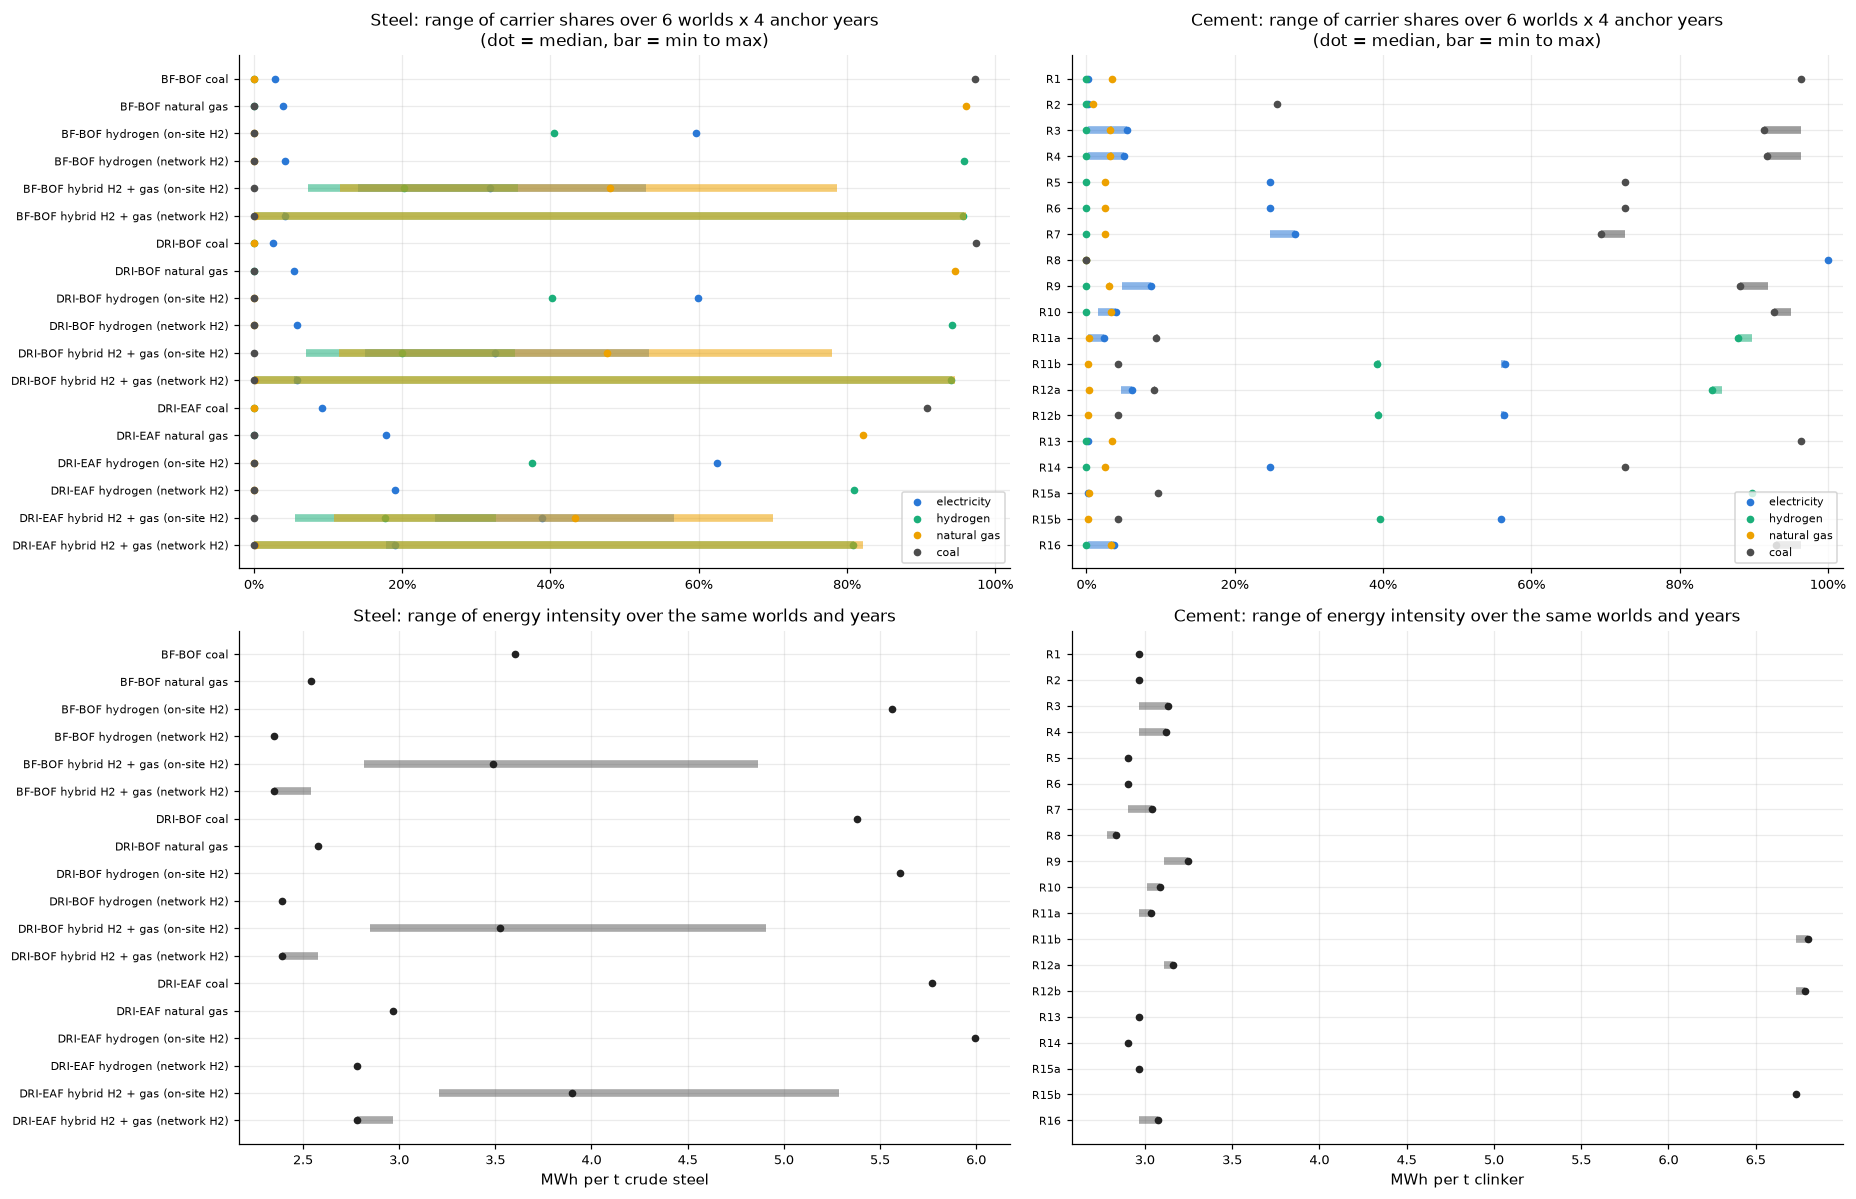

Steel: largest range of any carrier share across worlds/years, top 5:
technology
BF-BOF hybrid H2 + gas (network H2)    96.10
DRI-BOF hybrid H2 + gas (network H2)   94.60
DRI-EAF hybrid H2 + gas (network H2)   82.20
BF-BOF hybrid H2 + gas (on-site H2)    67.10
DRI-BOF hybrid H2 + gas (on-site H2)   66.50 percentage points

Cement: largest range of any carrier share across worlds/years, top 5:
technology
R3    5.20
R4    4.80
R9    4.00
R16   3.50
R7    3.40 percentage points



In [17]:
def mix_spread(sector: str) -> pd.DataFrame:
    rows = []
    for macro in MACROS:
        for year in ANCHORS:
            ue = unit_economics(sector, macro, year)
            en = ue[[c + "_MWh_per_t" for c in CARRIERS]]
            en.columns = CARRIERS
            sh = en.div(en.sum(axis=1), axis=0)
            for t in sh.index:
                rows.append({"technology": t, "macro": macro, "year": year, "MWh_per_t": en.loc[t].sum(), **sh.loc[t].to_dict()})
    return pd.DataFrame(rows)


SPREAD = {s: mix_spread(s) for s in SECTORS}
fig, axes = plt.subplots(2, 2, figsize=(17, 11), gridspec_kw={"height_ratios": [1, 1]})
for col, sector in enumerate(SECTORS):
    d = SPREAD[sector]
    techs = sorted(d.technology.unique(), key=lambda t: sort_key(sector, t))
    y = np.arange(len(techs))
    ax = axes[0, col]
    for car in ("electricity", "hydrogen", "natural_gas", "coal"):
        g = d.groupby("technology")[car]
        lo, hi, md_ = g.min().reindex(techs), g.max().reindex(techs), g.median().reindex(techs)
        if hi.max() < 0.005:
            continue
        ax.hlines(y, lo, hi, color=CARRIER_COLOR[car], linewidth=5, alpha=0.55)
        ax.plot(md_, y, "o", color=CARRIER_COLOR[car], markersize=4, label=car.replace("_", " "))
    ax.set_yticks(y, [tech_label(sector, t) for t in techs], fontsize=7.5)
    ax.invert_yaxis()
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_xlim(-0.02, 1.02)
    ax.set_title(f"{SECTORS[sector]['title']}: range of carrier shares over 6 worlds x 4 anchor years\n(dot = median, bar = min to max)")
    ax.legend(fontsize=7, loc="lower right")
    ax = axes[1, col]
    g = d.groupby("technology")["MWh_per_t"]
    lo, hi, md_ = g.min().reindex(techs), g.max().reindex(techs), g.median().reindex(techs)
    ax.hlines(y, lo, hi, color="#555555", linewidth=5, alpha=0.5)
    ax.plot(md_, y, "o", color="#222222", markersize=4)
    ax.set_yticks(y, [tech_label(sector, t) for t in techs], fontsize=7.5)
    ax.invert_yaxis()
    ax.set_xlabel(f"MWh per {SECTORS[sector]['unit']}")
    ax.set_title(f"{SECTORS[sector]['title']}: range of energy intensity over the same worlds and years")
fig.tight_layout()
plt.show()

spread_tab = {}
for s in SECTORS:
    d = SPREAD[s]
    sp = (d.groupby("technology")[CARRIERS].max() - d.groupby("technology")[CARRIERS].min()).max(axis=1)
    spread_tab[s] = sp.sort_values(ascending=False)
    print(f"{SECTORS[s]['title']}: largest range of any carrier share across worlds/years, top 5:")
    print((spread_tab[s].head(5) * 100).round(1).rename(index=lambda t: tech_label(s, t)).to_string(), "percentage points\n")

**Key findings: stability of the fuel signature**

* **For almost all configurations the mix does not move with the world or the year.** The largest range of any carrier share is below 6 percentage points for every cement route. The cement plant's mix is set by the route, not by the price scenario.
* **The exception is the steel hybrid hydrogen-plus-gas family.** With network hydrogen it burns hydrogen (81 to 96 percent) in five of the six worlds and switches to natural gas (82 to 96 percent) in AktuellePolitiken, where there is no carbon price and gas is cheap; the range reaches 96 percentage points for the BF-BOF variant. With on-site electrolysers the share also moves strongly between worlds and years (range 67 percentage points).
* **Consequence for the decision.** The hybrid route is a real option, not a hydrogen route in disguise: its fuel, and with it its CO2, depends on the world.

**How scenario-dependent is the ranking?** The heat maps give the operating cost per tonne of every technology in every macro scenario (2040). A technology whose cost is low only in one scenario is a bet on that scenario; a technology that is cheap everywhere is the robust choice. The rank row shows how often the cheapest technology changes.

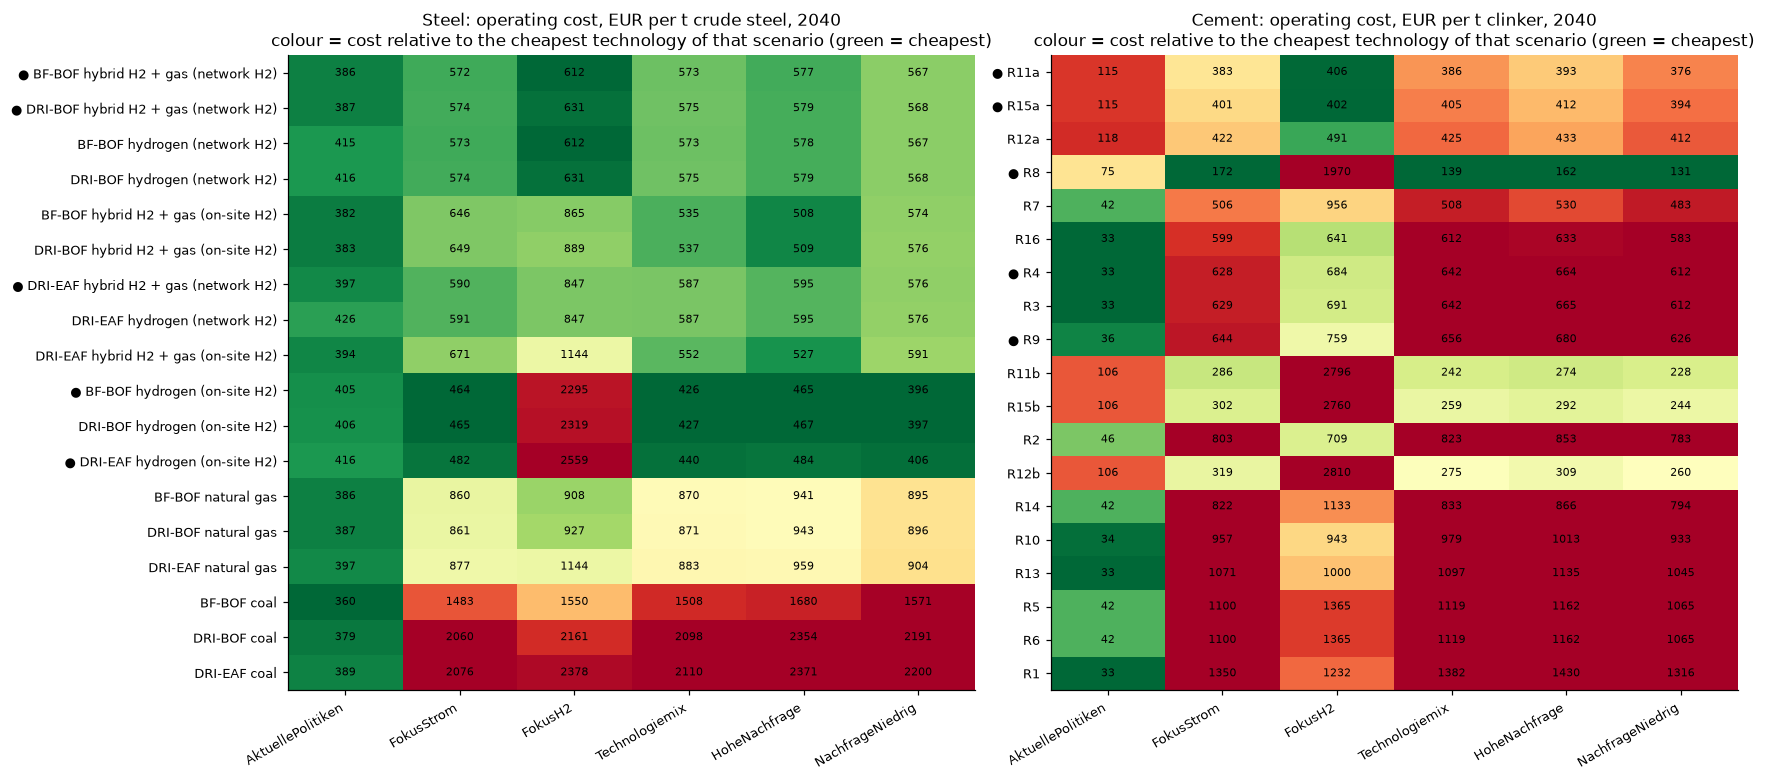

year                                                     2030  \
sector macro                                                    
cement AktuellePolitiken                                   R8   
       FokusH2                                             R8   
       FokusStrom                                          R8   
       HoheNachfrage                                       R8   
       NachfrageNiedrig                                    R8   
       Technologiemix                                      R8   
steel  AktuellePolitiken         BF-BOF hydrogen (on-site H2)   
       FokusH2                   BF-BOF hydrogen (on-site H2)   
       FokusStrom         BF-BOF hybrid H2 + gas (on-site H2)   
       HoheNachfrage             BF-BOF hydrogen (on-site H2)   
       NachfrageNiedrig   BF-BOF hybrid H2 + gas (on-site H2)   
       Technologiemix     BF-BOF hybrid H2 + gas (on-site H2)   

year                                                     2035  \
sector macro                                                    
cement AktuellePolitiken                                   R8   
       FokusH2                                           R11a   
       FokusStrom                                          R8   
       HoheNachfrage                                       R8   
       NachfrageNiedrig                                    R8   
       Technologiemix                                      R8   
steel  AktuellePolitiken         BF-BOF hydrogen (on-site H2)   
       FokusH2            BF-BOF hybrid H2 + gas (network H2)   
       FokusStrom                BF-BOF hydrogen (on-site H2)   
       HoheNachfrage             BF-BOF hydrogen (on-site H2)   
       NachfrageNiedrig          BF-BOF hydrogen (on-site H2)   
       Technologiemix            BF-BOF hydrogen (on-site H2)   

year                                                     2040  \
sector macro                                                    
cement AktuellePolitiken                                   R1   
       FokusH2                                           R15a   
       FokusStrom                                          R8   
       HoheNachfrage                                       R8   
       NachfrageNiedrig                                    R8   
       Technologiemix                                      R8   
steel  AktuellePolitiken                          BF-BOF coal   
       FokusH2            BF-BOF hybrid H2 + gas (network H2)   
       FokusStrom                BF-BOF hydrogen (on-site H2)   
       HoheNachfrage             BF-BOF hydrogen (on-site H2)   
       NachfrageNiedrig          BF-BOF hydrogen (on-site H2)   
       Technologiemix            BF-BOF hydrogen (on-site H2)   

year                                              2045  
sector macro                                            
cement AktuellePolitiken                            R1  
       FokusH2                                      R8  
       FokusStrom                                   R8  
       HoheNachfrage                                R8  
       NachfrageNiedrig                             R8  
       Technologiemix                               R8  
steel  AktuellePolitiken                   BF-BOF coal  
       FokusH2            BF-BOF hydrogen (on-site H2)  
       FokusStrom         BF-BOF hydrogen (on-site H2)  
       HoheNachfrage      BF-BOF hydrogen (on-site H2)  
       NachfrageNiedrig   BF-BOF hydrogen (on-site H2)  
       Technologiemix     BF-BOF hydrogen (on-site H2)

In [18]:
def cost_matrix(sector: str, year: int) -> pd.DataFrame:
    cols = {}
    for macro in MACROS:
        cols[macro] = unit_economics(sector, macro, year)["total_cost"]
    return pd.DataFrame(cols)


fig, axes = plt.subplots(1, 2, figsize=(16, 7.2), gridspec_kw={"width_ratios": [1, 1]})
for ax, sector in zip(axes, SECTORS):
    cm = cost_matrix(sector, 2040)
    order = cm.mean(axis=1).sort_values().index
    cm = cm.loc[order]
    # colour by cost relative to the scenario's cheapest technology (so columns are comparable)
    rel = cm / cm.min(axis=0)
    im = ax.imshow(np.log2(rel.to_numpy()), cmap="RdYlGn_r", aspect="auto", vmin=0, vmax=2)
    ax.set_xticks(range(len(MACROS)), [MACRO_TITLE[m] for m in MACROS], rotation=30, ha="right")
    ax.set_yticks(range(len(cm)), [("● " if t in USED[sector] else "   ") + tech_label(sector, t) for t in cm.index])
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, f"{cm.iloc[i, j]:.0f}", ha="center", va="center", fontsize=7.5)
    ax.set_title(f"{SECTORS[sector]['title']}: operating cost, EUR per {SECTORS[sector]['unit']}, 2040\n"
                 "colour = cost relative to the cheapest technology of that scenario (green = cheapest)")
    ax.grid(False)
fig.tight_layout()
plt.show()

rank_rows = []
for sector in SECTORS:
    for year in ANCHORS:
        cm = cost_matrix(sector, year)
        for macro in MACROS:
            rank_rows.append({"sector": sector, "year": year, "macro": MACRO_TITLE[macro],
                              "cheapest technology": tech_label(sector, cm[macro].idxmin()),
                              "cost EUR/t": cm[macro].min(),
                              "cheapest chosen by an AURIS case": cm[macro].idxmin() in USED[sector]})
cheapest = pd.DataFrame(rank_rows)
display(cheapest.pivot_table(index=["sector", "macro"], columns="year", values="cheapest technology", aggfunc="first"))

**Carbon and fuel exposure.** The decision to move away from fossil routes depends on how much a CO2 price and fuel prices add to each technology. The next view multiplies each technology's CO2 intensity by the scenario CO2 price (an *exposure* measure) and shows how it grows between 2030 and 2040.

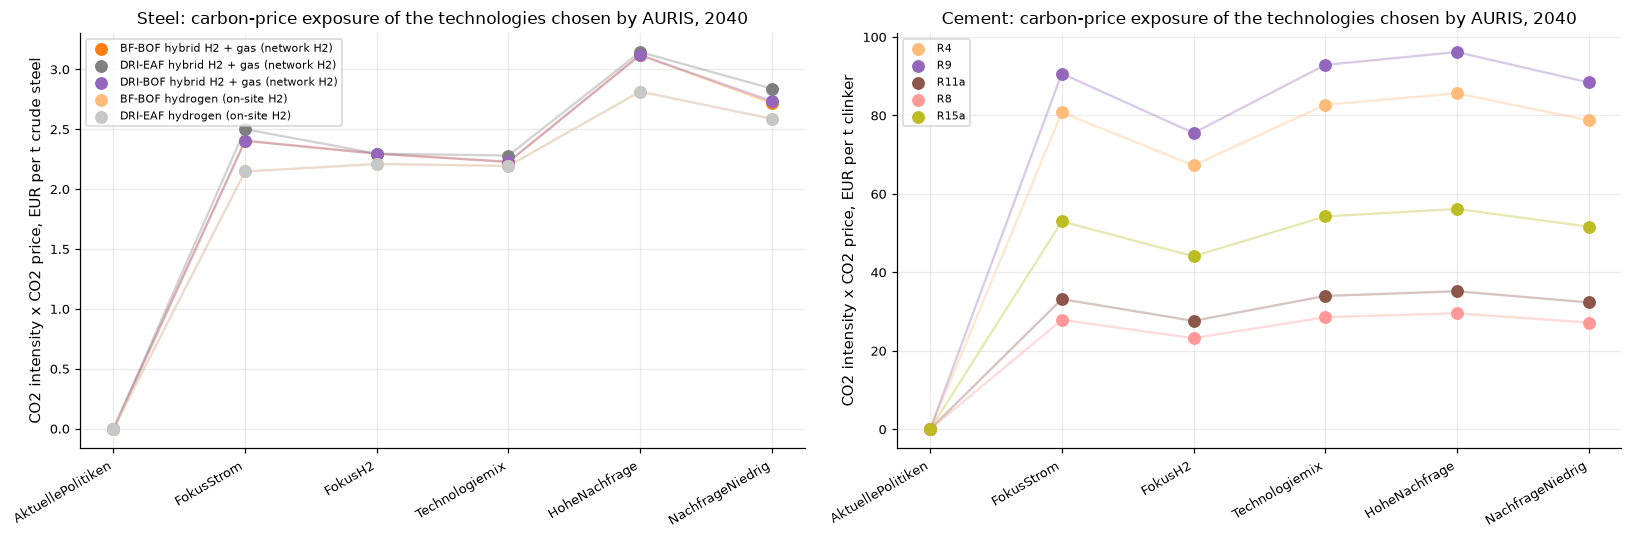

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, sector in zip(axes, SECTORS):
    co2_price = price_annual[price_annual.sector == sector].set_index(["macro", "year"])["co2_price"]
    show = sorted(USED[sector], key=lambda t: -UE[sector].loc[t, "co2_t_per_t"])
    for t in show:
        vals = []
        for macro in MACROS:
            u = unit_economics(sector, macro, 2040).loc[t, "co2_t_per_t"]
            vals.append(u * co2_price[(macro, 2040)])
        ax.scatter(range(len(MACROS)), vals, s=55, color=TECH_COLOR[(sector, t)], label=tech_label(sector, t), zorder=3)
        ax.plot(range(len(MACROS)), vals, color=TECH_COLOR[(sector, t)], alpha=0.35)
    ax.set_xticks(range(len(MACROS)), [MACRO_TITLE[m] for m in MACROS], rotation=30, ha="right")
    ax.set_ylabel(f"CO2 intensity x CO2 price, EUR per {SECTORS[sector]['unit']}")
    ax.set_title(f"{SECTORS[sector]['title']}: carbon-price exposure of the technologies chosen by AURIS, 2040")
    ax.legend(fontsize=7, loc="upper left")
fig.tight_layout()
plt.show()

**Key findings: technology economics (2040, AktuellePolitiken world, the current reference; Technologiemix figures given for comparison)**

* **Zero CO2 price changes the ranking completely.** AktuellePolitiken has no carbon price in any year (section 3), so every technology's CO2 allowance cost is zero here, and fuel cost alone decides the ranking. This is the opposite of Technologiemix, where the CO2 price (442 to 563 EUR/t in 2035 to 2040) was often the largest single cost component.
* **Steel, technologies AURIS actually selects.** The network-hydrogen hybrid routes now burn natural gas, not hydrogen (section 5.1), and that gas is cheap and untaxed: operating cost is 388 to 399 EUR/t, against 407 to 419 EUR/t for the on-site-electrolyser routes (which still pay for electricity plus grid fees, 85 to 96 EUR/t combined, with no CO2 saving to offset it). Under Technologiemix the ordering was reversed: on-site electrolyser was the cheapest option (about 430 EUR/t) and network hydrogen the second cheapest (about 575 EUR/t). Iron ore (315 EUR/t) and lime (5 EUR/t) are unchanged and are now 80 to 82 percent of the network-route cost.
* **Cement, technologies AURIS actually selects.** The fossil-with-capture routes are now the cheapest: R4 at 33.5 EUR/t and R9 at 36.6 EUR/t, both almost entirely coal cost, since the capture equipment is running but earns no CO2-price credit. R8 (fully electric) costs 76.8 EUR/t (electricity 41.3, grid fees and levies 33.7), more than double R4/R9. The hydrogen routes R11a and R15a are now the most expensive at 122.8 EUR/t, almost all of it bought hydrogen (111.2 EUR/t) with no carbon saving to justify the premium. Under Technologiemix the ordering was the opposite: R8 was cheapest (about 141 EUR/t) and the fossil-with-capture routes were among the most expensive (about 640 to 660 EUR/t) because of their CO2 allowance cost.
* **Reconciliation.** Price times quantity explains FLEXIMOD's gross operating cost to within 0.15 percent (95th percentile, steel) and 0.02 percent (cement), and the rebuilt operating cost lies within +0.8 percent (steel) and +0.1 percent (cement) of the AURIS cost input at the median (this check is not reference-world-specific; it holds over every macro scenario and year in the data).
* **The ranking depends on the world, not only on AktuellePolitiken.** In FokusH2 the electrified cement route R8 costs 1970 EUR/t against 402 to 406 for the hydrogen routes, and the on-site-electrolyser steel routes cost 2295 to 2559 EUR/t against 612 to 631 for network hydrogen: the reverse of AktuellePolitiken's zero-carbon-price ranking above. These two worlds bracket the six macro scenarios.
* **Reading for the investment decision.** Electrified and on-site-hydrogen technologies are bets on abundant cheap electricity and a high CO2 price. Network-hydrogen and hydrogen-fired routes are insurance against electricity scarcity. Fossil and fossil-with-capture routes are a bet that no CO2 price materialises, which is exactly the world now shown as the reference above -- the gap between this ranking and the Technologiemix ranking is the size of the bet each AURIS case is making on the carbon price.

## 6. Technology adoption: the investment decision

**Question.** Which technology does each plant choose, when, and why?

AURIS evaluates, for every plant and every year, a set of candidate decisions: *continue* with the current technology, *invest in* each alternative technology, or *reinvest* in the same one. For every candidate and every macro scenario it discounts the annual cash flow (revenue minus operating cost minus CAPEX plus residual value) at 5 percent to the decision year. A candidate's score then depends on the decision rule:

* **Risk-neutral:** probability-weighted mean NPV under the case's belief vector (`expected_npv`).
* **Risk-averse, worst-case mean:** the lowest mean NPV over the plausible belief vectors.
* **Risk-averse, tail risk:** the expected shortfall of the NPV distribution (worst 5 percent, `tail_alpha` 0.95).

The best-scoring candidate is selected. If it is an investment, the technology changes from that year on. The sections below open this box step by step.

### 6.1 Adoption over time: fleet technology mix

Share of installed capacity by technology, 2025 to 2049, per case. This is the structural change that drives everything below.

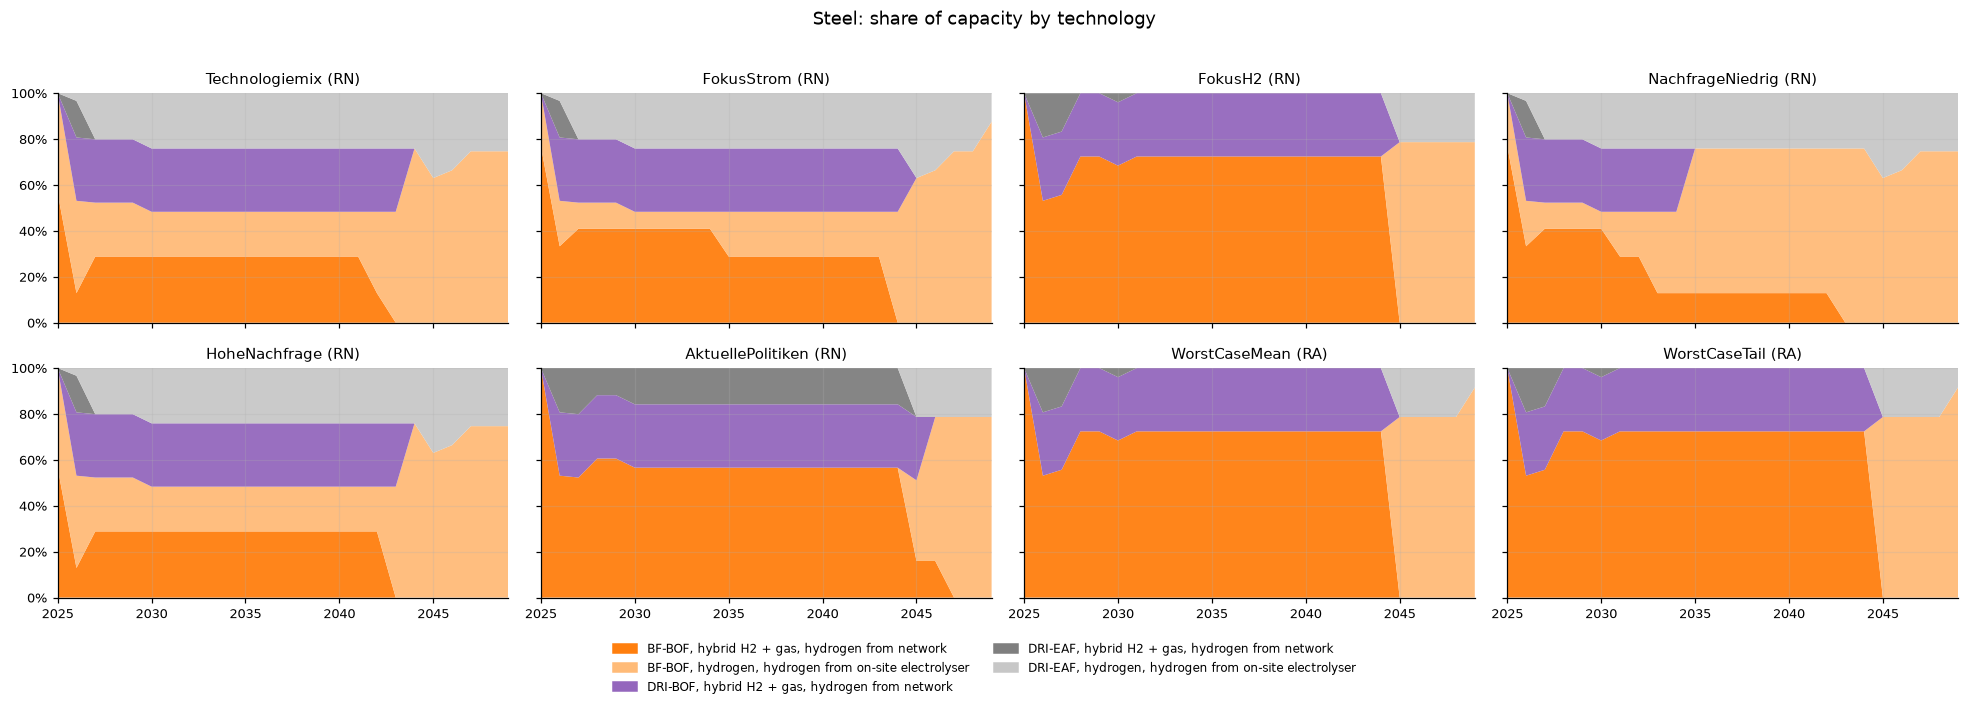

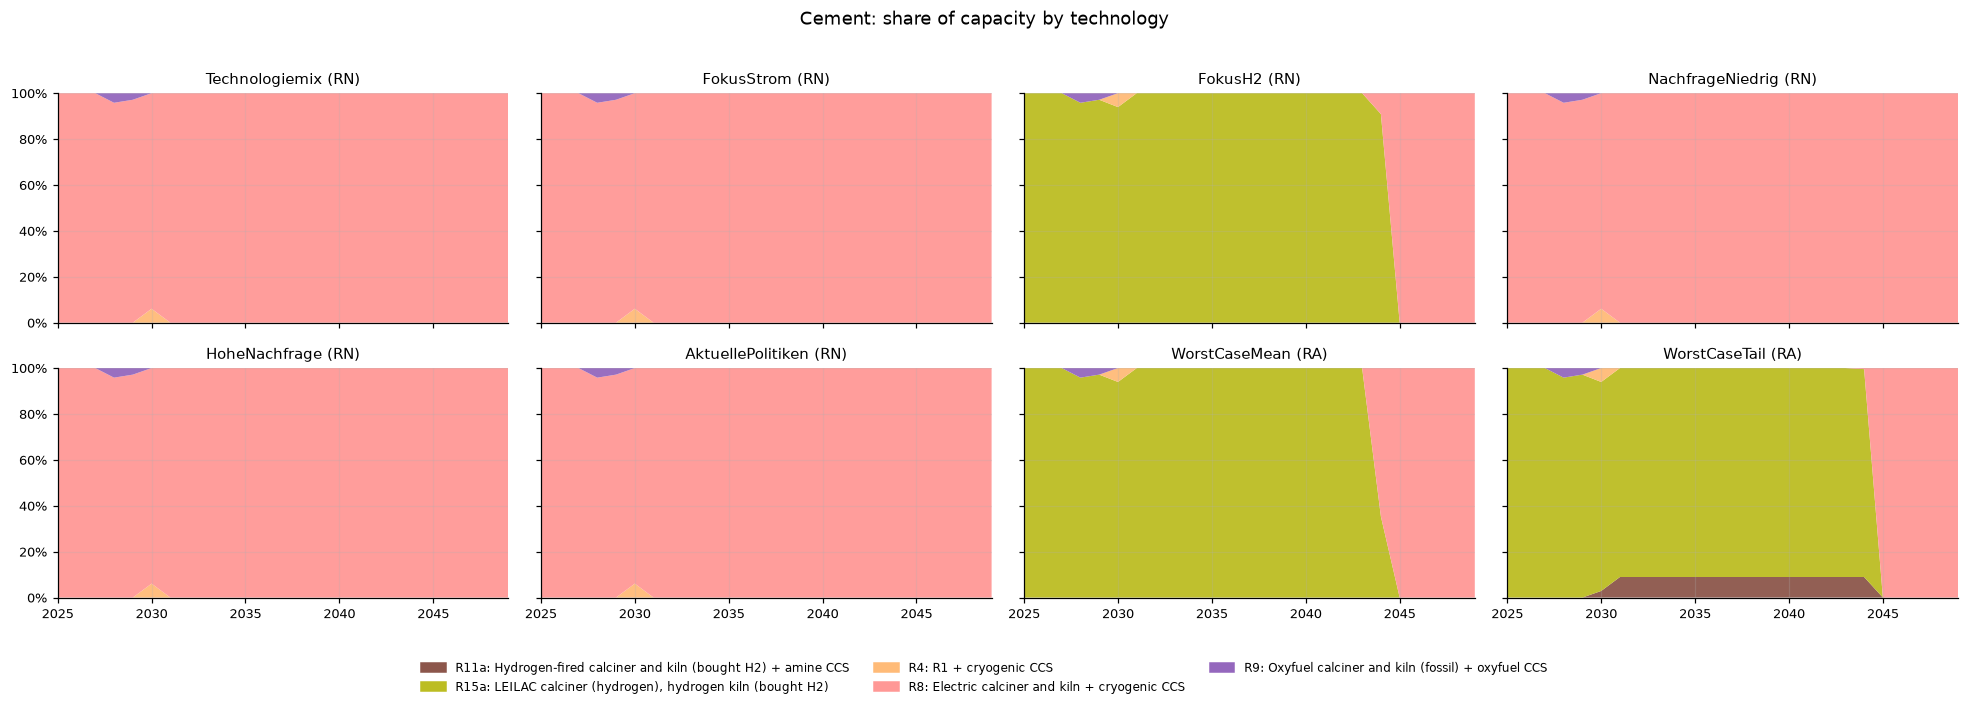

In [20]:
def plot_fleet_mix(sector: str):
    techs = sorted(USED[sector])
    fig, axes = plt.subplots(2, 4, figsize=(18, 6.3), sharey=True, sharex=True)
    for ax, case in zip(axes.ravel(), CASES):
        pw = AUR[sector][case]["pathway"]
        cap = pw.pivot_table(index="year", columns="active_technology_id", values="capacity", aggfunc="sum").reindex(columns=techs).fillna(0.0)
        share = cap.div(cap.sum(axis=1), axis=0)
        ax.stackplot(share.index, share.T.to_numpy(), colors=[TECH_COLOR[(sector, t)] for t in techs], alpha=0.95)
        ax.set_title(CASE_SHORT[case], fontsize=10)
        ax.set_xlim(2025, 2049); ax.set_ylim(0, 1)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    handles = [plt.matplotlib.patches.Patch(color=TECH_COLOR[(sector, t)], label=tech_long(sector, t)) for t in techs]
    fig.legend(handles=handles, loc="lower center", ncol=2 if sector == "steel" else 3, fontsize=8, frameon=False)
    fig.suptitle(f"{SECTORS[sector]['title']}: share of capacity by technology", y=0.995)
    fig.tight_layout(rect=(0, 0.09, 1, 0.98))
    plt.show()


for s in SECTORS:
    plot_fleet_mix(s)

### 6.2 Pathways: which technology, which plant, which year

One panel per case. Each row is a plant, each column a year; the colour is the technology the plant operates. A colour change along a row is an investment. Plants are sorted by capacity.

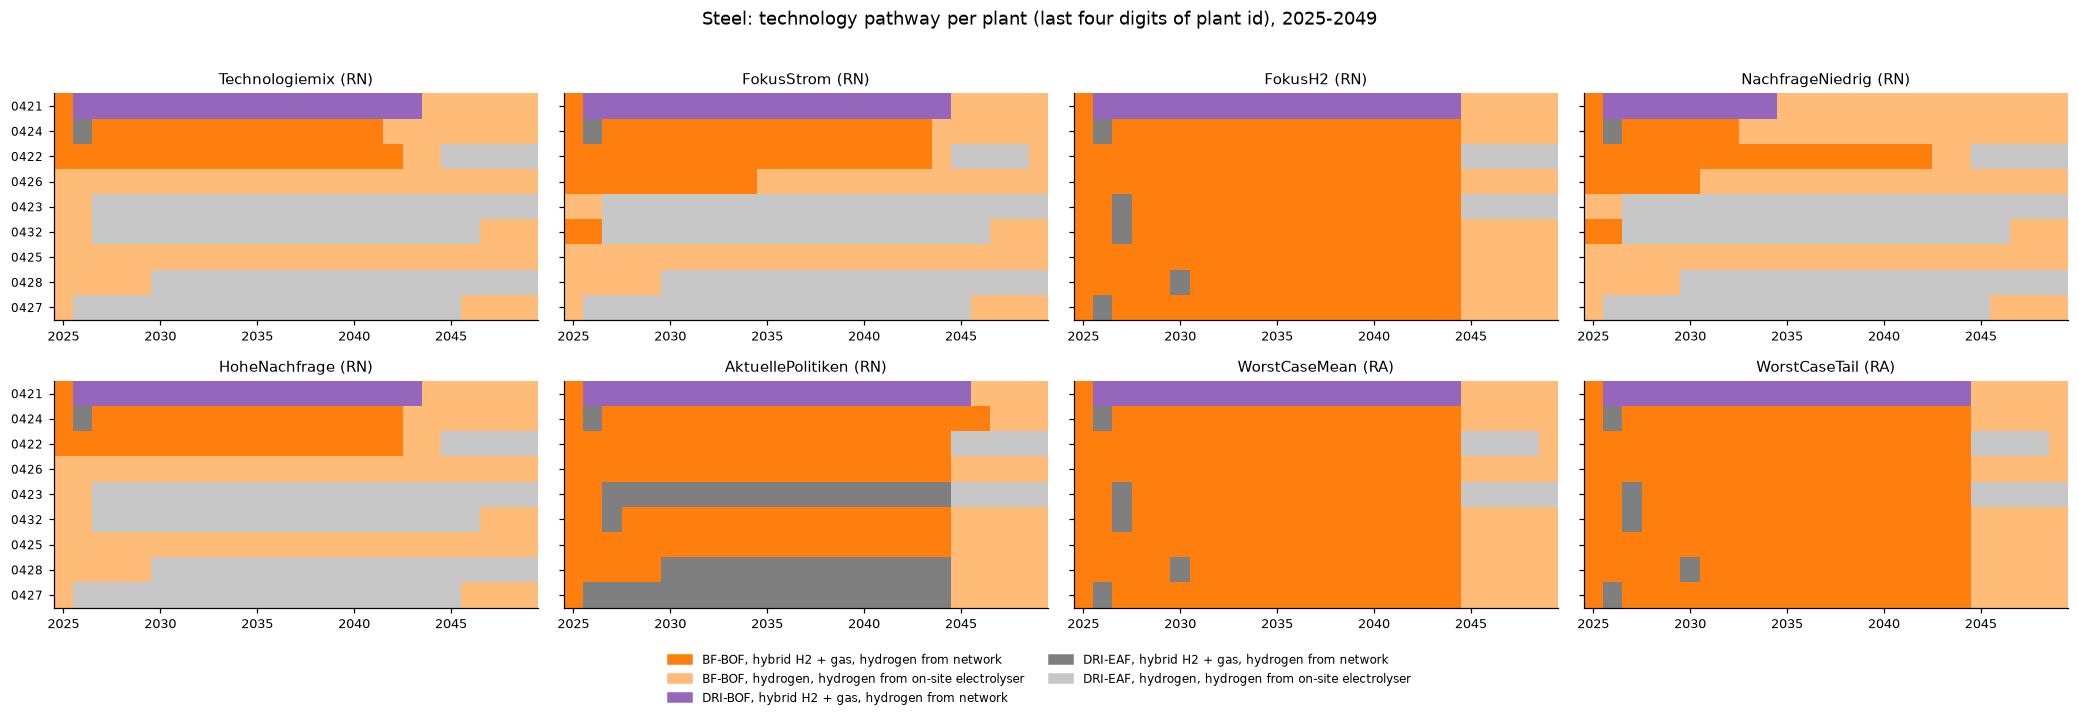

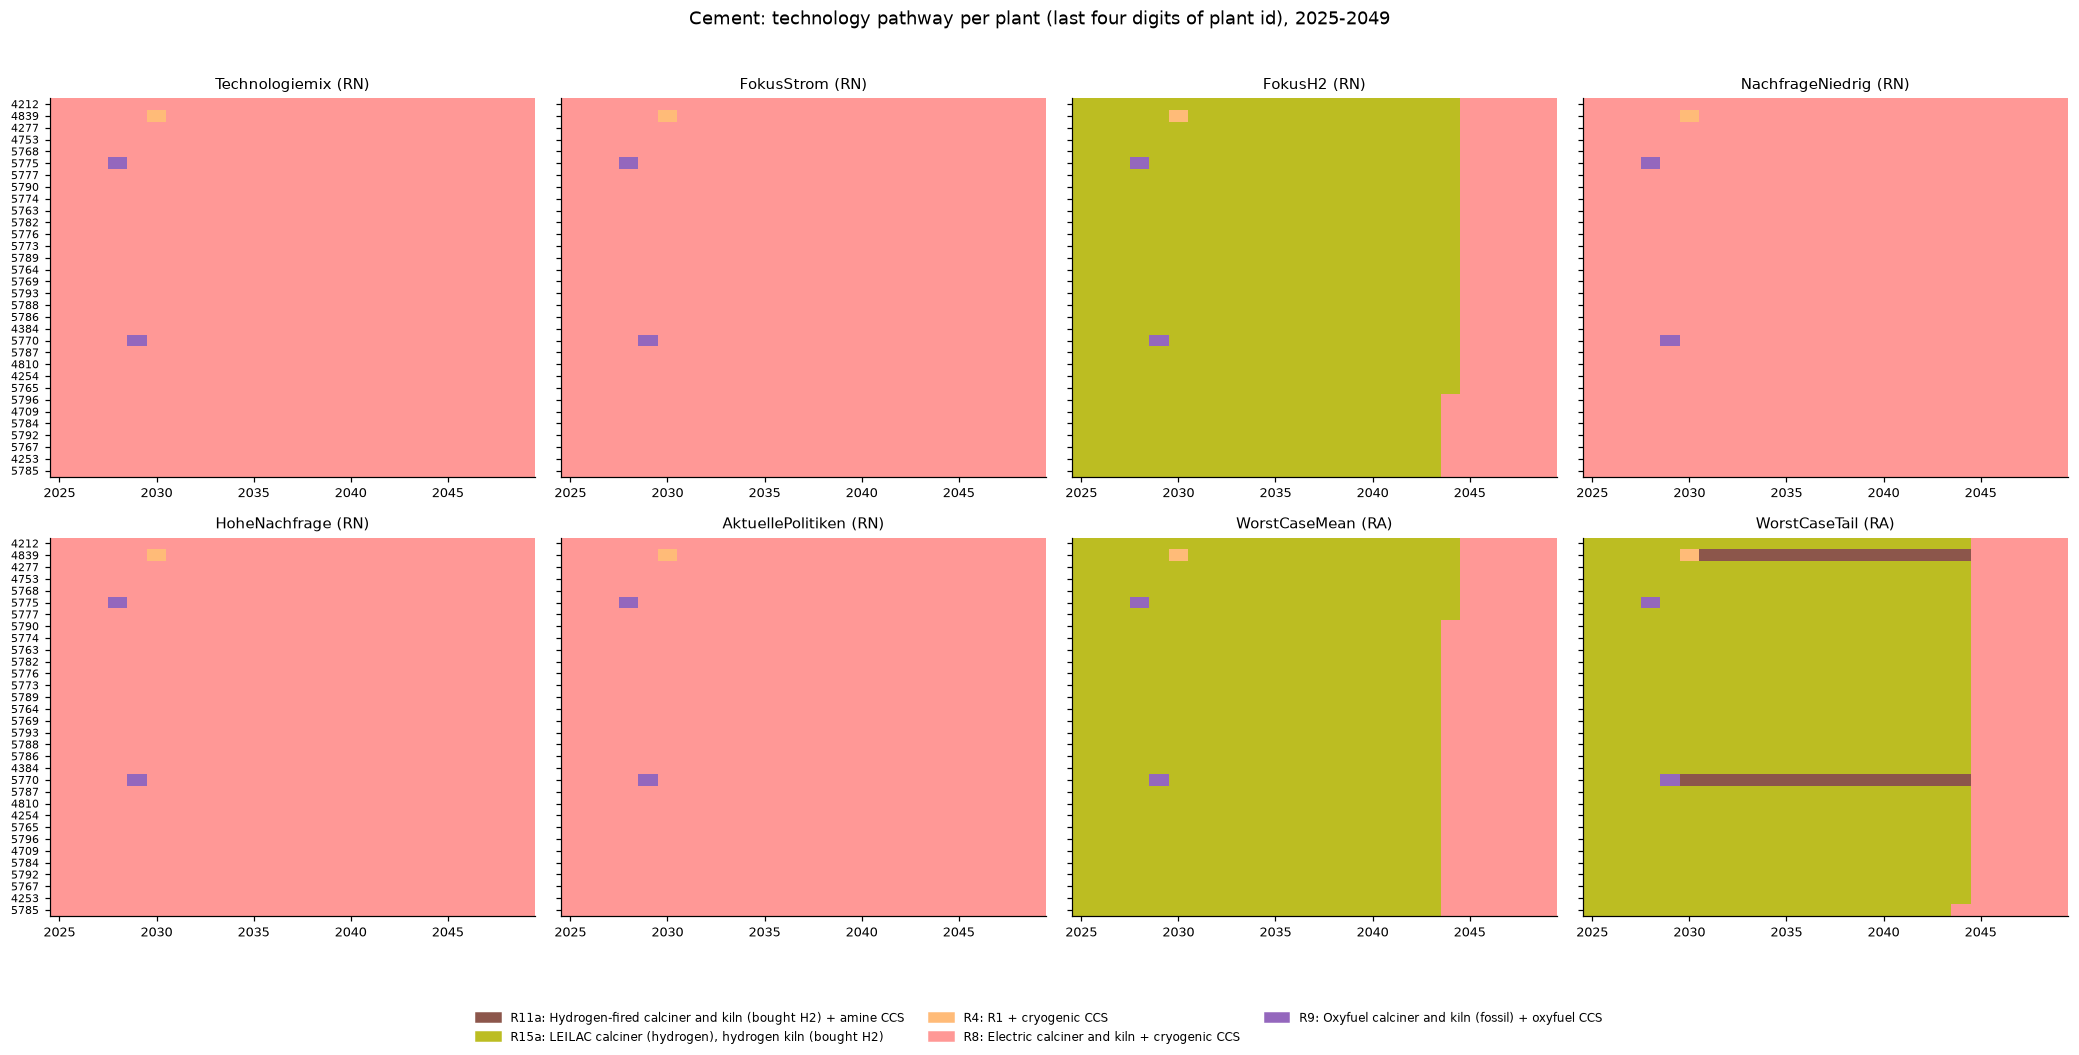

In [21]:
def plot_pathways(sector: str):
    techs = sorted(USED[sector])
    code_of = {t: i for i, t in enumerate(techs)}
    cmap = matplotlib_cmap = plt.matplotlib.colors.ListedColormap([TECH_COLOR[(sector, t)] for t in techs])
    cap = AUR[sector][CASES[0]]["pathway"].groupby("plant_id")["capacity"].max().sort_values(ascending=False)
    order = list(cap.index)
    fig, axes = plt.subplots(2, 4, figsize=(19, 6.4 if sector == "steel" else 9.5), sharey=True)
    for ax, case in zip(axes.ravel(), CASES):
        pw = AUR[sector][case]["pathway"].pivot(index="plant_id", columns="year", values="active_technology_id").loc[order]
        arr = pw.replace(code_of).to_numpy(dtype=float)
        ax.imshow(arr, cmap=cmap, aspect="auto", vmin=-0.5, vmax=len(techs) - 0.5, interpolation="nearest")
        ax.set_xticks(range(0, len(YEARS), 5), YEARS[::5])
        ax.set_title(CASE_SHORT[case], fontsize=10)
        ax.grid(False)
    short_ids = [pid[-4:] for pid in order]
    axes[0, 0].set_yticks(range(len(order)), short_ids, fontsize=7 if sector == "cement" else 8)
    axes[1, 0].set_yticks(range(len(order)), short_ids, fontsize=7 if sector == "cement" else 8)
    handles = [plt.matplotlib.patches.Patch(color=TECH_COLOR[(sector, t)], label=tech_long(sector, t)) for t in techs]
    fig.legend(handles=handles, loc="lower center", ncol=2 if sector == "steel" else 3, fontsize=8, frameon=False)
    fig.suptitle(f"{SECTORS[sector]['title']}: technology pathway per plant (last four digits of plant id), 2025-2049", y=0.995)
    fig.tight_layout(rect=(0, 0.09, 1, 0.98))
    plt.show()


for s in SECTORS:
    plot_pathways(s)

**Key findings: pathways**

* **Steel.** All nine plants leave coal BF-BOF in 2025 or 2026 in every case. Technologiemix and HoheNachfrage put 44 percent of capacity on on-site-electrolyser BF-BOF at once and 24 percent on on-site DRI-EAF from 2030; FokusStrom and NachfrageNiedrig do the same to a lesser extent. FokusH2, AktuellePolitiken and both risk-averse cases stay on network-hydrogen hybrid routes until 2044 and move to electrolysers from 2045.
* **Cement.** Five risk-neutral cases (Technologiemix, FokusStrom, NachfrageNiedrig, HoheNachfrage, AktuellePolitiken) move every plant to R8 in 2025; 6 percent of capacity shows R4 in 2030, which corresponds to the mandatory Ruedersdorf project in the AURIS inputs. FokusH2 and both risk-averse cases choose the hydrogen route R15a in 2025 (WorstCaseTail adds 9 percent R11a) and replace it by R8 in 2044 and 2045.
* **Agreement.** The five cement R8 cases are identical (agreement 1.00). For steel, FokusH2 and both risk-averse cases choose identical pathways, and Technologiemix and HoheNachfrage are identical. Only about 40 percent of steel plant-years agree between these two groups.

### 6.3 Timing and investment volume

How many plants invest in each year, and how much capital does that require? The CAPEX is the capital AURIS charges when the investment takes effect (`investment_capex` in the investment events).

sector,case,investments,plants_investing,technology_switches,capex_bn,first_year,last_year
cement,AktuellePolitiken (RN),38,32,38,18.9,2025,2031
cement,FokusH2 (RN),70,32,70,25.4,2025,2045
cement,FokusStrom (RN),38,32,38,19.0,2025,2031
cement,HoheNachfrage (RN),38,32,38,20.4,2025,2031
cement,NachfrageNiedrig (RN),38,32,38,18.2,2025,2031
cement,Technologiemix (RN),38,32,38,19.0,2025,2031
cement,WorstCaseMean (RA),70,32,70,25.5,2025,2045
cement,WorstCaseTail (RA),70,32,70,25.9,2025,2045
steel,AktuellePolitiken (RN),27,9,26,27.6,2025,2047
steel,FokusH2 (RN),29,9,29,27.9,2025,2045


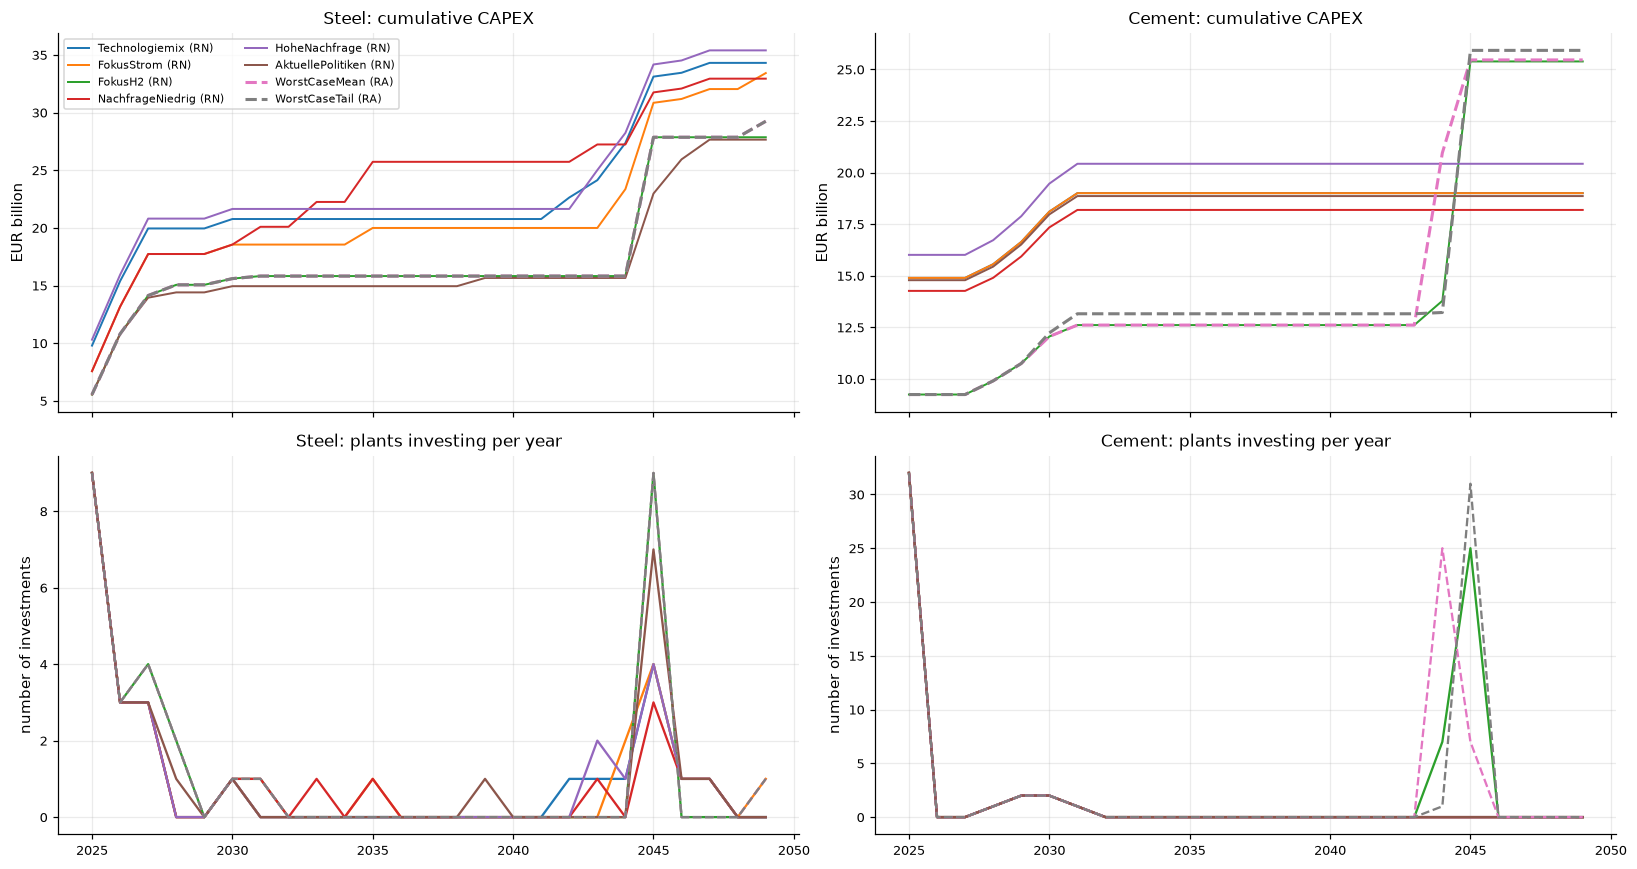

In [22]:
ev_frames = []
for s in SECTORS:
    for c in CASES:
        e = AUR[s][c]["events"].copy()
        e["sector"], e["case"] = s, c
        ev_frames.append(e)
EVENTS = pd.concat(ev_frames, ignore_index=True)
EVENTS["capex_bn"] = EVENTS["investment_capex"] / 1e9
EVENTS["is_new_technology"] = EVENTS["old_technology_id"] != EVENTS["new_technology_id"]

summary_events = (EVENTS.groupby(["sector", "case"])
                  .agg(investments=("plant_id", "size"), plants_investing=("plant_id", "nunique"),
                       technology_switches=("is_new_technology", "sum"), capex_bn=("capex_bn", "sum"),
                       first_year=("year", "min"), last_year=("year", "max"))
                  .reset_index())
summary_events["case"] = summary_events["case"].map(CASE_SHORT)
display(summary_events.style.format({"capex_bn": "{:.1f}"}).hide(axis="index")
        .set_caption("Investment events per case (a reinvestment in the same technology counts as an investment, not a switch)"))

fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex="col")
for col, sector in enumerate(SECTORS):
    sub = EVENTS[EVENTS.sector == sector]
    for case in CASES:
        d = sub[sub.case == case]
        by_year = d.groupby("year")["capex_bn"].sum().reindex(YEARS, fill_value=0.0)
        axes[0, col].plot(YEARS, by_year.cumsum(), label=CASE_SHORT[case], marker=None,
                          linestyle="--" if case.endswith("risk_averse") else "-", linewidth=2 if case.endswith("risk_averse") else 1.3)
        n = d.groupby("year").size().reindex(YEARS, fill_value=0)
        axes[1, col].plot(YEARS, n, linestyle="--" if case.endswith("risk_averse") else "-")
    axes[0, col].set_title(f"{SECTORS[sector]['title']}: cumulative CAPEX")
    axes[0, col].set_ylabel("EUR billion")
    axes[1, col].set_title(f"{SECTORS[sector]['title']}: plants investing per year")
    axes[1, col].set_ylabel("number of investments")
axes[0, 0].legend(fontsize=7, ncol=2)
fig.tight_layout()
plt.show()

**Key findings: timing and volume of investment**

* **Steel** needs 25 to 30 investments and 27.6 to 35.4 EUR bn of CAPEX per case (risk-averse: 30 investments, 29.2 EUR bn). The first 2025 and 2026 investments dominate; a second wave of reinvestments falls in 2044 to 2047 (up to 9 investments in 2045) when the 20-year lives of the 2025 and 2026 investments end.
* **Cement** needs 38 investments and 18.2 to 20.4 EUR bn in the R8 cases. The hydrogen-first cases (FokusH2 and both risk-averse cases) need 70 investments and 25.4 to 25.9 EUR bn, because every plant invests twice: R15a in 2025 and R8 in 2044 or 2045. R15a has a 25-year life, so the second investment is an early replacement. It happens when the FokusH2 scarcity prices of 2035 to 2040 are gone (mean day-ahead price 24 EUR/MWh in 2045).

### 6.4 How well does each decision rule perform?

AURIS stores the annual cash flows of every candidate in every macro scenario, so the value of a decision can be re-computed under *any* belief, not just the one it was chosen with. I rebuild the NPV of each plant's first decision (taken in 2025) under every macro scenario, sum over plants to a portfolio, and then evaluate that portfolio under each belief vector. This is a like-for-like comparison of the eight cases.

Check: the rebuilt expected NPV of a decision must equal the `expected_npv` reported by AURIS. The check cell below asserts that.

In [23]:
import pyarrow.csv as pacsv
import pyarrow.compute as pc

CF_COLS = ["plant_id", "decision_year", "candidate_decision_id", "action", "candidate_technology_id", "scenario",
           "operating_year", "revenue", "annual_net_operating_cost", "capex", "residual_value", "cashflow"]


def aggregate_cashflows(sector: str, case: str) -> pd.DataFrame:
    """Discounted components per plant, decision year, candidate and scenario (cached)."""
    cache_file = CACHE / f"cashflow_agg_{sector}_{case}.parquet"
    if cache_file.exists():
        return pd.read_parquet(cache_file)
    path = SECTORS[sector]["auris_out"] / case / "dynamic_investment_results" / "dynamic_annual_cashflows.csv"
    table = pacsv.read_csv(path, convert_options=pacsv.ConvertOptions(include_columns=CF_COLS))
    df = table.to_pandas()
    for c in ("revenue", "annual_net_operating_cost", "capex", "residual_value", "cashflow"):
        df[c] = df[c].fillna(0.0)
    df["df"] = (1 + DISCOUNT_RATE) ** -(df["operating_year"] - df["decision_year"])
    # AURIS discounts (cashflow - capex); the stored `cashflow` already contains the terminal value in the last year.
    df["d_npv"] = (df["cashflow"] - df["capex"]) * df["df"]
    df["d_revenue"] = df["revenue"] * df["df"]
    df["d_opex"] = df["annual_net_operating_cost"] * df["df"]
    df["d_capex"] = df["capex"] * df["df"]
    keys = ["plant_id", "decision_year", "candidate_decision_id", "action", "candidate_technology_id", "scenario"]
    agg = df.groupby(keys, as_index=False)[["d_npv", "d_revenue", "d_opex", "d_capex"]].sum().rename(columns={"d_npv": "npv"})
    # whatever is not operating margin or CAPEX is the terminal (residual) value at the horizon
    agg["d_terminal"] = agg["npv"] - (agg["d_revenue"] - agg["d_opex"] - agg["d_capex"])
    agg.to_parquet(cache_file)
    return agg


with ThreadPoolExecutor(8) as pool:
    jobs = {(s, c): pool.submit(aggregate_cashflows, s, c) for s in SECTORS for c in CASES}
CF = {k: j.result() for k, j in jobs.items()}
print({k: len(v) for k, v in list(CF.items())[:3]}, "... aggregated cash-flow rows per case")

# --- check: rebuilt expected NPV equals the value stored by AURIS -------------------------------------------
for sector in SECTORS:
    case = CASES[0]
    sel = AUR[sector][case]["selected"]
    sel25 = sel[sel.year == 2025]
    agg = CF[(sector, case)]
    prob_b = P.loc["Technologiemix"]
    inv_map = {MACRO_TITLE[m]: m for m in MACROS}
    errs = []
    for _, r in sel25.iterrows():
        x = agg[(agg.candidate_decision_id == r.selected_decision_id) & (agg.decision_year == 2025)].set_index("scenario")["npv"]
        expected = sum(x[m] * prob_b[MACRO_TITLE[m]] for m in MACROS)
        errs.append(abs(expected - r.expected_npv) / abs(r.expected_npv))
    print(f"{sector}: max relative deviation between rebuilt and reported expected NPV = {max(errs):.2e}")
    assert max(errs) < 1e-6

{('steel', 'Technologiemix_risk_neutral'): 23754, ('steel', 'FokusStrom_risk_neutral'): 23760, ('steel', 'FokusH2_risk_neutral'): 23766} ... aggregated cash-flow rows per case
steel: max relative deviation between rebuilt and reported expected NPV = 1.68e-16
cement: max relative deviation between rebuilt and reported expected NPV = 1.70e-16


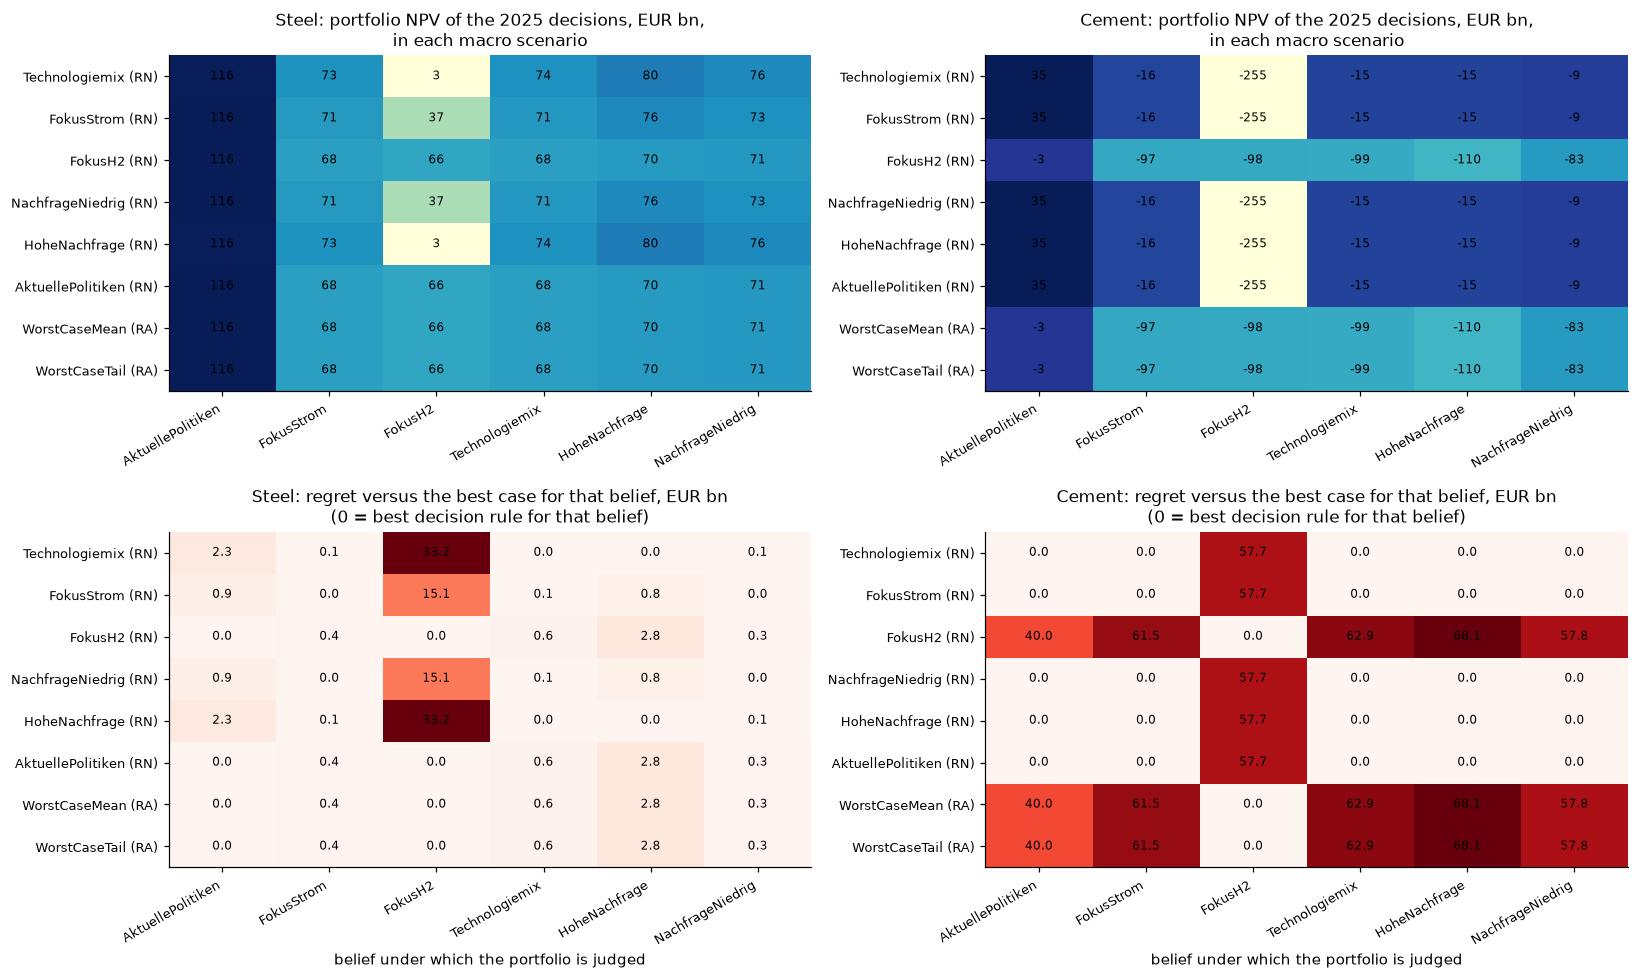

In [24]:
# Portfolio NPV of the 2025 decision of every case under every macro scenario.
rows = []
for sector in SECTORS:
    for case in CASES:
        sel = AUR[sector][case]["selected"]
        sel25 = sel[sel.year == 2025][["plant_id", "selected_decision_id"]]
        agg = CF[(sector, case)]
        x = agg[(agg.decision_year == 2025) & agg.candidate_decision_id.isin(sel25.selected_decision_id)]
        by_s = x.groupby("scenario")["npv"].sum()
        for m in MACROS:
            rows.append({"sector": sector, "case": case, "macro": m, "npv_bn": by_s[m] / 1e9})
NPV_SCEN = pd.DataFrame(rows)

# belief-weighted values of each case's portfolio
beliefs = list(P.index)
perf_rows = []
for sector in SECTORS:
    for case in CASES:
        v = NPV_SCEN[(NPV_SCEN.sector == sector) & (NPV_SCEN.case == case)].set_index("macro")["npv_bn"]
        for b in beliefs:
            perf_rows.append({"sector": sector, "case": case, "belief": b,
                              "expected_npv_bn": sum(v[m] * P.loc[b, MACRO_TITLE[m]] for m in MACROS)})
PERF = pd.DataFrame(perf_rows)
PERF["regret_bn"] = PERF.groupby(["sector", "belief"])["expected_npv_bn"].transform("max") - PERF["expected_npv_bn"]

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for col, sector in enumerate(SECTORS):
    m1 = NPV_SCEN[NPV_SCEN.sector == sector].pivot(index="case", columns="macro", values="npv_bn").loc[CASES, MACROS]
    ax = axes[0, col]
    im = ax.imshow(m1.to_numpy(), cmap="YlGnBu", aspect="auto")
    ax.set_xticks(range(6), [MACRO_TITLE[m] for m in MACROS], rotation=30, ha="right")
    ax.set_yticks(range(8), [CASE_SHORT[c] for c in CASES])
    for i in range(8):
        for j in range(6):
            ax.text(j, i, f"{m1.iloc[i, j]:.0f}", ha="center", va="center", fontsize=8)
    ax.set_title(f"{SECTORS[sector]['title']}: portfolio NPV of the 2025 decisions, EUR bn,\nin each macro scenario")
    ax.grid(False)
    m2 = PERF[PERF.sector == sector].pivot(index="case", columns="belief", values="regret_bn").loc[CASES, beliefs]
    ax = axes[1, col]
    ax.imshow(m2.to_numpy(), cmap="Reds", aspect="auto")
    ax.set_xticks(range(6), beliefs, rotation=30, ha="right")
    ax.set_yticks(range(8), [CASE_SHORT[c] for c in CASES])
    for i in range(8):
        for j in range(6):
            ax.text(j, i, f"{m2.iloc[i, j]:.1f}", ha="center", va="center", fontsize=8)
    ax.set_xlabel("belief under which the portfolio is judged")
    ax.set_title(f"{SECTORS[sector]['title']}: regret versus the best case for that belief, EUR bn\n(0 = best decision rule for that belief)")
    ax.grid(False)
fig.tight_layout()
plt.show()

In [25]:
rob = []
for sector in SECTORS:
    for case in CASES:
        d = PERF[(PERF.sector == sector) & (PERF.case == case)]
        v = NPV_SCEN[(NPV_SCEN.sector == sector) & (NPV_SCEN.case == case)]
        rob.append({"sector": sector, "case": CASE_SHORT[case],
                    "mean over beliefs (EUR bn)": d.expected_npv_bn.mean(),
                    "worst belief (EUR bn)": d.expected_npv_bn.min(),
                    "worst scenario (EUR bn)": v.npv_bn.min(),
                    "max regret over beliefs (EUR bn)": d.regret_bn.max()})
ROBUST = pd.DataFrame(rob)
display(ROBUST.style.hide(axis="index").format({c: "{:,.1f}" for c in ROBUST.columns if "EUR" in c})
        .set_caption("Performance of the 2025 decisions: average, worst case and regret"))

sector,case,mean over beliefs (EUR bn),worst belief (EUR bn),worst scenario (EUR bn),max regret over beliefs (EUR bn)
steel,Technologiemix (RN),73.2,39.9,3.5,33.2
steel,FokusStrom (RN),76.3,57.9,37.1,15.1
steel,FokusH2 (RN),78.5,73.0,65.6,2.8
steel,NachfrageNiedrig (RN),76.3,57.9,37.1,15.1
steel,HoheNachfrage (RN),73.2,39.9,3.5,33.2
steel,AktuellePolitiken (RN),78.5,73.0,65.6,2.8
steel,WorstCaseMean (RA),78.5,73.0,65.6,2.8
steel,WorstCaseTail (RA),78.5,73.0,65.6,2.8
cement,Technologiemix (RN),-39.0,-143.5,-255.1,57.7
cement,FokusStrom (RN),-39.0,-143.5,-255.1,57.7


### 6.4b Robust frontier: what hedging buys

Every case trades off two numbers: how it does on average over the beliefs it considers plausible (`mean over beliefs`), and how it does in the single worst macro scenario (`worst scenario`, the same column as in the table above). Plotting one against the other turns the eight cases into a frontier: cases on the upper-right edge are *efficient* (no other case does better on both), cases below and to the left of the frontier are dominated. The risk-averse cases are chosen for where they sit on the x-axis, not the y-axis: they give up expected value to move right, away from a bad worst case.

The callout marks the gap between the best risk-neutral case's point and the best risk-averse case's point: how much worst-scenario loss hedging avoids, and what it costs in expectation to buy that protection.

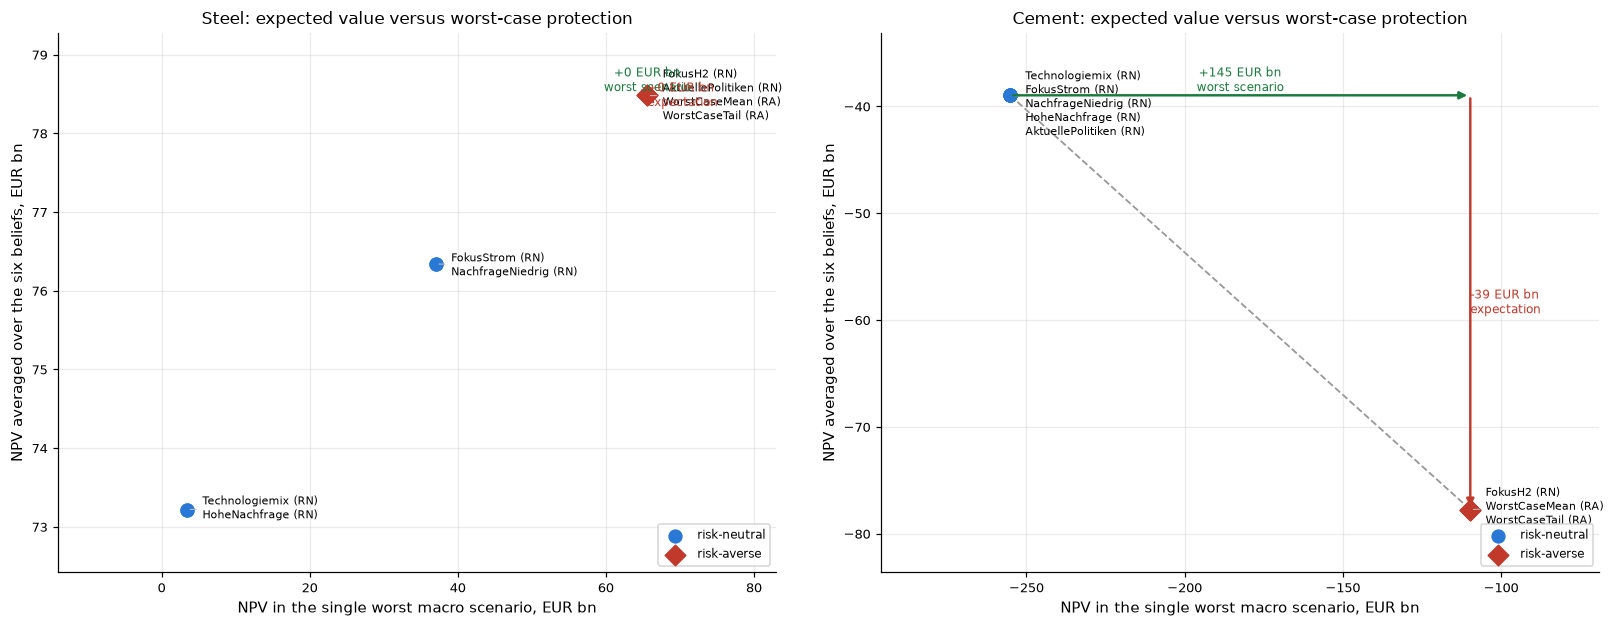

What hedging buys, best risk-neutral case versus best risk-averse case (by worst-scenario NPV):
  Steel: WorstCaseMean (RA) saves 0.0 EUR bn in the worst scenario versus FokusH2 (RN), at a cost of -0.0 EUR bn of expected value.
  Cement: WorstCaseMean (RA) saves 145.4 EUR bn in the worst scenario versus Technologiemix (RN), at a cost of 38.8 EUR bn of expected value.


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))
for ax, sector in zip(axes, SECTORS):
    ax.margins(x=0.28, y=0.15)
    d = ROBUST[ROBUST.sector == sector].set_index("case")
    x, y = d["worst scenario (EUR bn)"], d["mean over beliefs (EUR bn)"]
    is_ra = pd.Series([c.endswith("(RA)") for c in d.index], index=d.index)
    # Pareto frontier: a case is efficient if no other case has both a weakly higher x and a weakly higher y
    eff = [not ((x >= x[c]) & (y >= y[c]) & ((x > x[c]) | (y > y[c]))).any() for c in d.index]
    order = x[eff].sort_values().index
    ax.plot(x[order], y[order], color="#999999", linestyle="--", zorder=1, linewidth=1.2)
    ax.scatter(x[~is_ra], y[~is_ra], s=70, color="#2a78d6", label="risk-neutral", zorder=3)
    ax.scatter(x[is_ra], y[is_ra], s=90, color="#c0392b", marker="D", label="risk-averse", zorder=3)
    # several cases often land on exactly the same point (identical portfolios); group them so labels do not overlap
    groups: dict[tuple[float, float], list[str]] = {}
    for c in d.index:
        groups.setdefault((round(x[c], 2), round(y[c], 2)), []).append(c)
    yr = y.max() - y.min() or 1.0
    for k, (xy, cases) in enumerate(sorted(groups.items(), key=lambda kv: -kv[0][0])):
        gx, gy = xy
        dy_off = (0.05 + 0.055 * (k % 4)) * yr * (1 if k % 2 == 0 else -1.4)
        ax.annotate("\n".join(cases), (gx, gy), fontsize=7.3, xytext=(10, dy_off), textcoords="offset points",
                   ha="left", va="center", arrowprops=dict(arrowstyle="-", color="#bbbbbb", lw=0.7))
    best_rn = d[~is_ra]["mean over beliefs (EUR bn)"].idxmax()
    best_ra = d[is_ra]["worst scenario (EUR bn)"].idxmax()
    dx, dy = x[best_ra] - x[best_rn], y[best_ra] - y[best_rn]
    ax.annotate("", xy=(x[best_ra], y[best_rn]), xytext=(x[best_rn], y[best_rn]),
               arrowprops=dict(arrowstyle="-|>", color="#1b7a3d", lw=1.6))
    ax.annotate("", xy=(x[best_ra], y[best_ra]), xytext=(x[best_ra], y[best_rn]),
               arrowprops=dict(arrowstyle="-|>", color="#c0392b", lw=1.6))
    ax.text((x[best_ra] + x[best_rn]) / 2, y[best_rn], f"+{dx:,.0f} EUR bn\nworst scenario", color="#1b7a3d", fontsize=8,
           ha="center", va="bottom" if dx >= 0 else "top")
    ax.text(x[best_ra], (y[best_ra] + y[best_rn]) / 2, f"{dy:+,.0f} EUR bn\nexpectation", color="#c0392b", fontsize=8,
           ha="left", va="center")
    ax.set_xlabel("NPV in the single worst macro scenario, EUR bn")
    ax.set_ylabel("NPV averaged over the six beliefs, EUR bn")
    ax.set_title(f"{SECTORS[sector]['title']}: expected value versus worst-case protection")
    ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
plt.show()

print("What hedging buys, best risk-neutral case versus best risk-averse case (by worst-scenario NPV):")
for sector in SECTORS:
    d = ROBUST[ROBUST.sector == sector].set_index("case")
    is_ra = pd.Series([c.endswith("(RA)") for c in d.index], index=d.index)
    best_rn = d.loc[~is_ra, "mean over beliefs (EUR bn)"].idxmax()
    best_ra = d.loc[is_ra, "worst scenario (EUR bn)"].idxmax()
    dx = d.loc[best_ra, "worst scenario (EUR bn)"] - d.loc[best_rn, "worst scenario (EUR bn)"]
    dy = d.loc[best_ra, "mean over beliefs (EUR bn)"] - d.loc[best_rn, "mean over beliefs (EUR bn)"]
    print(f"  {SECTORS[sector]['title']}: {best_ra} saves {dx:,.1f} EUR bn in the worst scenario versus {best_rn}, "
         f"at a cost of {-dy:,.1f} EUR bn of expected value.")

### 6.4c One plant, one technology versus the risk-neutral alternative, world by world

The frontier above compresses each case into two numbers. This opens the decision back up for a single plant: which technology each of the two risk-averse rules (WorstCaseMean, WorstCaseTailRisk) commits to for its 2025 decision, against which technology a risk-neutral case commits to for the same plant and year, and what each would actually be worth if every one of the six worlds in turn is the one that occurs. The label above each world is the mean of the two risk-averse bars minus the best risk-neutral bar: negative where being robust gives something up, positive where it would have been the better choice even without hedging.

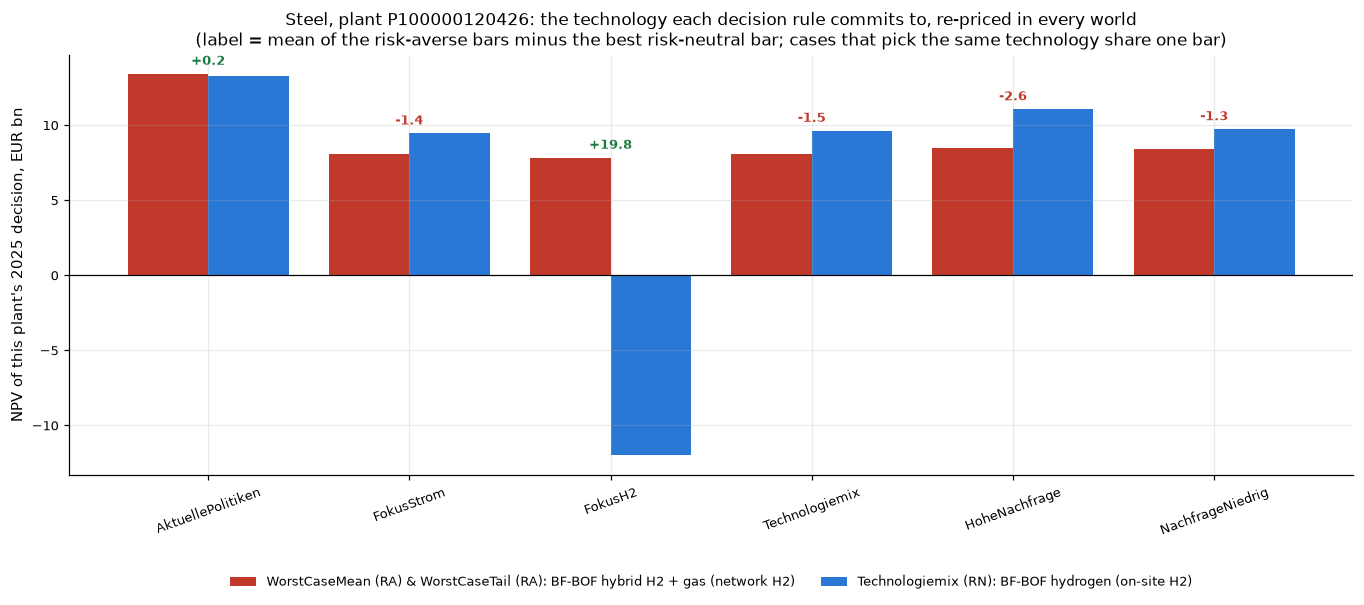

Steel, plant P100000120426, by world:
  AktuellePolitiken WorstCaseMean (RA)/WorstCaseTail (RA) +13.42  Technologiemix (RN) +13.25
  FokusStrom       WorstCaseMean (RA)/WorstCaseTail (RA)  +8.08  Technologiemix (RN)  +9.44
  FokusH2          WorstCaseMean (RA)/WorstCaseTail (RA)  +7.82  Technologiemix (RN) -12.00
  Technologiemix   WorstCaseMean (RA)/WorstCaseTail (RA)  +8.09  Technologiemix (RN)  +9.62
  HoheNachfrage    WorstCaseMean (RA)/WorstCaseTail (RA)  +8.49  Technologiemix (RN) +11.05
  NachfrageNiedrig WorstCaseMean (RA)/WorstCaseTail (RA)  +8.38  Technologiemix (RN)  +9.72


In [27]:
def plant_robustness_frontier(sector: str, plant_id: str, cases: list[str], year: int = 2025):
    """One plant's 2025 decision: the technology each named case commits to, re-priced in every world --
    the loss or gain of each decision rule's choice relative to the others, world by world. Cases that
    land on the identical technology are drawn as one bar (not stacked invisibly on top of each other)."""
    chosen = {}
    for case in cases:
        sel = AUR[sector][case]["selected"]
        chosen[case] = sel[(sel.plant_id == plant_id) & (sel.year == year)].selected_technology_id.iloc[0]

    groups: dict[str, list[str]] = {}
    for case, tech in chosen.items():
        groups.setdefault(tech, []).append(case)

    rows = []
    for tech, group_cases in groups.items():
        rep_case = group_cases[0]
        agg = CF[(sector, rep_case)]
        a = agg[(agg.plant_id == plant_id) & (agg.decision_year == year) & (agg.candidate_technology_id == tech)]
        npv = a.set_index("scenario")["npv"].reindex(MACROS) / 1e9
        rows.append((tech, group_cases, npv))
    # order groups the same way `cases` lists them (first case that picks each technology)
    rows.sort(key=lambda r: cases.index(r[1][0]))

    fig, ax = plt.subplots(figsize=(12.5, 5.8))
    x = np.arange(len(MACROS))
    w = 0.8 / len(rows)
    palette = ["#c0392b", "#2a78d6", "#1b7a3d", "#8e44ad"]
    for k, (tech, group_cases, npv) in enumerate(rows):
        all_ra = all(c.endswith("risk_averse") for c in group_cases)
        color = "#c0392b" if all_ra else ("#2a78d6" if all(not c.endswith("risk_averse") for c in group_cases) else palette[k % len(palette)])
        names = " & ".join(CASE_SHORT[c] for c in group_cases)
        ax.bar(x + (k - (len(rows) - 1) / 2) * w, npv, width=w, color=color, label=f"{names}: {tech_label(sector, tech)}")
    for i, macro in enumerate(MACROS):
        ra_vals = [npv[macro] for tech, group_cases, npv in rows if all(c.endswith("risk_averse") for c in group_cases)]
        rn_vals = [npv[macro] for tech, group_cases, npv in rows if any(not c.endswith("risk_averse") for c in group_cases)]
        if ra_vals and rn_vals:
            gap = (sum(ra_vals) / len(ra_vals)) - max(rn_vals)
            y = max(npv[macro] for _, _, npv in rows)
            ax.text(i, y + 0.6, f"{gap:+.1f}", ha="center", fontsize=8.5, fontweight="bold",
                   color="#1b7a3d" if gap >= 0 else "#c0392b")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x, [MACRO_TITLE[m] for m in MACROS], rotation=20)
    ax.set_ylabel("NPV of this plant's 2025 decision, EUR bn")
    ax.set_title(f"{SECTORS[sector]['title']}, plant {plant_id}: the technology each decision rule commits to, "
                 f"re-priced in every world\n(label = mean of the risk-averse bars minus the best risk-neutral bar; "
                 f"cases that pick the same technology share one bar)")
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.3), fontsize=8.5, frameon=False, ncol=2)
    fig.tight_layout()
    plt.show()
    print(f"{SECTORS[sector]['title']}, plant {plant_id}, by world:")
    for macro in MACROS:
        line = "  ".join(f"{'/'.join(CASE_SHORT[c] for c in group_cases)} {npv[macro]:+6.2f}" for tech, group_cases, npv in rows)
        print(f"  {MACRO_TITLE[macro]:<16} {line}")


FEATURED_PLANT = {"steel": "P100000120426"}
plant_robustness_frontier("steel", FEATURED_PLANT["steel"],
                          ["WorstCaseMean_risk_averse", "WorstCaseTailRisk_risk_averse", "Technologiemix_risk_neutral"])

**Key findings: how the decision rules perform**

* **Steel.** The robust choice dominates. The portfolio chosen by FokusH2, AktuellePolitiken and the risk-averse rules has an NPV between 66 and 116 EUR bn in all six worlds. Technologiemix and HoheNachfrage reach 116, 73, 3, 74, 80, 76 EUR bn: in the FokusH2 world their on-site-electrolyser plants earn almost nothing (3 against 66 EUR bn, a regret of 33 EUR bn). The robust portfolio also has the best average over the six beliefs (78.5 against 73.2 EUR bn), so hedging is free here.
* **Cement.** The R8 portfolio chosen by five risk-neutral cases has an NPV of 35 EUR bn in AktuellePolitiken but minus 255 EUR bn in FokusH2. The hydrogen portfolio ranges from minus 110 to minus 3 EUR bn. Hedging costs about 39 EUR bn of average NPV (minus 39.0 against minus 77.7) and improves the worst scenario by about 145 EUR bn. By the criterion of maximum regret the R8 portfolio is slightly better (57.7 against 68.1 EUR bn), by the worst-case criterion the hydrogen portfolio is better. The cement NPVs are negative because the assumed cement price does not cover the cost of the low-carbon routes; only their ranking carries meaning.
* **The beliefs matter less than the rule.** The eight cases collapse onto a few portfolios: three distinct 2025 portfolios in steel (Technologiemix and HoheNachfrage; FokusStrom and NachfrageNiedrig; FokusH2, AktuellePolitiken and both risk-averse rules) and two in cement (the R8 portfolio of five risk-neutral cases; the hydrogen portfolio of FokusH2 and both risk-averse rules).

### 6.5 Why was this technology chosen? A decision dossier

The function below opens the box for any plant, case and decision year. It lists the candidates with their scores, rebuilds the NPV of the selected option and its closest rivals in every macro scenario, and decomposes the advantage of the selected option over *continue* into four terms: lower operating cost, change in revenue, CAPEX paid, and closing value. The closing value is the lump sum AURIS books when an option ends: a residual value in the last year of the horizon for long-lived options, and a continuation value in the year an old plant reaches the end of its life (for the old coal steel plants this appears as a lump sum in 2031, six years after the decision). A negative operating-cost saving means the selected option spends more, usually because it keeps the plant producing for longer. All terms are discounted to the decision year.

Steel | Technologiemix (RN) | plant P100000120421 | decision year 2025 | rule: expected_npv


rank,action,technology,expected NPV (bn),worst-case mean NPV (bn),expected shortfall NPV (bn),max regret (bn)
1.000000,invest_alternative_technology,bf_bof_hybrid_hydrogen_natural_gas_external,22.70,22.18,19.82,3.60
2.000000,invest_alternative_technology,bf_bof_hydrogen_external,22.34,21.74,19.65,3.62
3.000000,invest_alternative_technology,bf_bof_hybrid_hydrogen_natural_gas_electrolyser,21.81,15.41,8.67,11.15
4.000000,invest_alternative_technology,bf_bof_hydrogen_electrolyser,21.47,-10.68,-40.26,60.08
5.000000,invest_alternative_technology,dri_bof_hybrid_hydrogen_natural_gas_external,21.34,20.46,17.77,4.94
6.000000,invest_alternative_technology,dri_bof_hydrogen_external,20.97,20.02,17.60,4.96


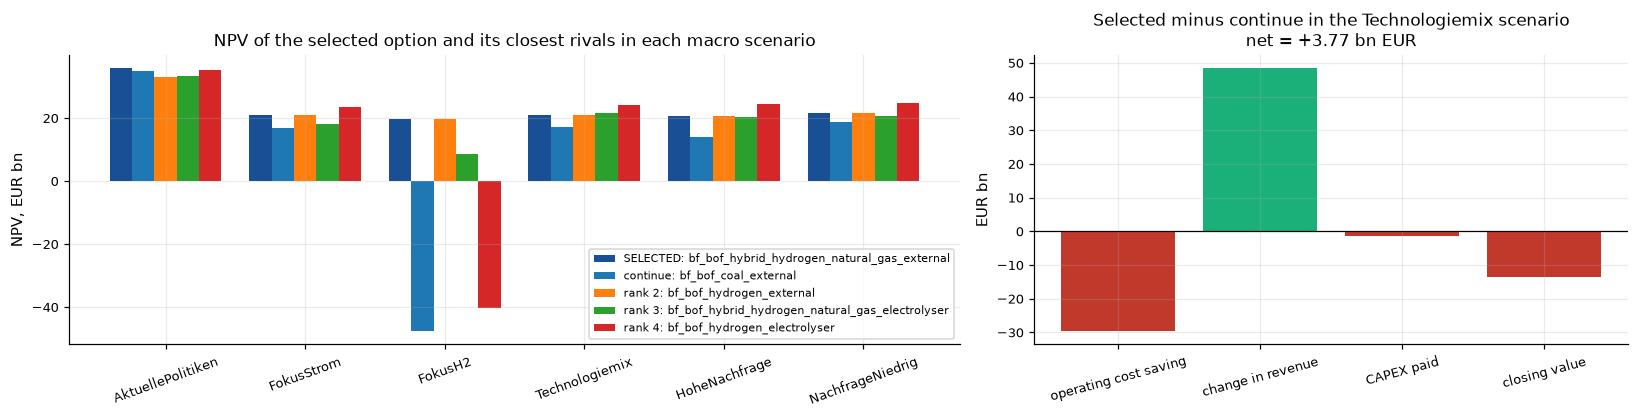

Steel | FokusH2 (RN) | plant P100000120421 | decision year 2025 | rule: expected_npv


rank,action,technology,expected NPV (bn),worst-case mean NPV (bn),expected shortfall NPV (bn),max regret (bn)
1.000000,invest_alternative_technology,bf_bof_hybrid_hydrogen_natural_gas_external,22.18,22.18,19.82,3.60
2.000000,invest_alternative_technology,bf_bof_hydrogen_external,21.74,21.74,19.65,3.62
3.000000,invest_alternative_technology,dri_bof_hybrid_hydrogen_natural_gas_external,20.46,20.46,17.77,4.94
4.000000,invest_alternative_technology,dri_bof_hydrogen_external,20.02,20.02,17.60,4.96
5.000000,invest_alternative_technology,bf_bof_hybrid_hydrogen_natural_gas_electrolyser,15.41,15.41,8.67,11.15
6.000000,continue_current,bf_bof_coal_external,13.67,12.73,8.30,nan


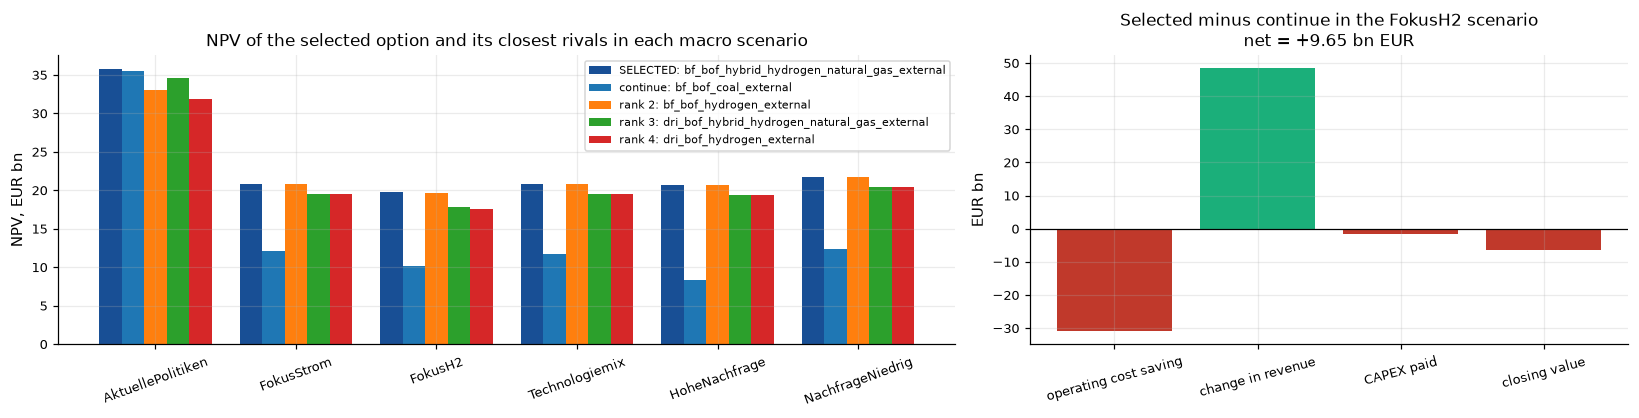

Steel | WorstCaseMean (RA) | plant P100000120421 | decision year 2025 | rule: worst_case_mean


rank,action,technology,expected NPV (bn),worst-case mean NPV (bn),expected shortfall NPV (bn),max regret (bn)
1.000000,invest_alternative_technology,bf_bof_hybrid_hydrogen_natural_gas_external,22.70,22.18,19.82,3.60
2.000000,invest_alternative_technology,bf_bof_hydrogen_external,22.34,21.74,19.65,3.62
3.000000,invest_alternative_technology,dri_bof_hybrid_hydrogen_natural_gas_external,21.34,20.46,17.77,4.94
4.000000,invest_alternative_technology,dri_bof_hydrogen_external,20.97,20.02,17.60,4.96
5.000000,invest_alternative_technology,bf_bof_hybrid_hydrogen_natural_gas_electrolyser,21.81,15.41,8.67,11.15
6.000000,invest_alternative_technology,dri_bof_hybrid_hydrogen_natural_gas_electrolyser,20.42,13.61,6.51,13.31


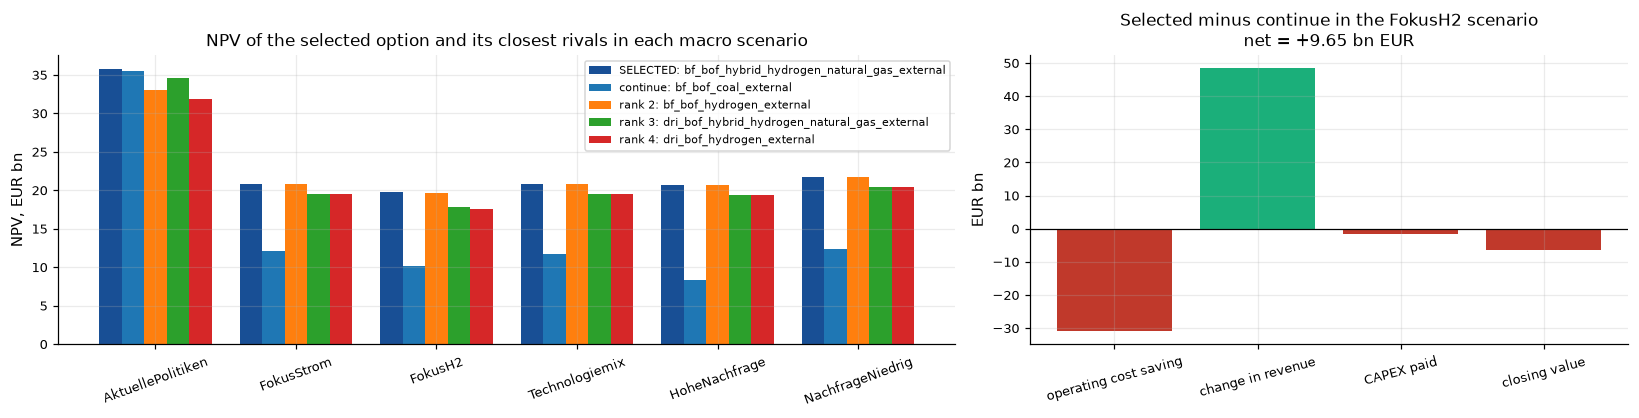

Cement | Technologiemix (RN) | plant P100000124212 | decision year 2025 | rule: expected_npv


rank,action,technology,expected NPV (bn),worst-case mean NPV (bn),expected shortfall NPV (bn),max regret (bn)
1.000000,invest_alternative_technology,R8,-1.71,-9.81,-17.34,11.09
2.000000,invest_alternative_technology,R15a,-5.52,-5.87,-7.02,5.86
3.000000,invest_alternative_technology,R15b,-5.63,-16.53,-26.80,20.56
4.000000,invest_alternative_technology,R11a,-5.65,-6.00,-7.10,5.94
5.000000,invest_alternative_technology,R7,-5.69,-7.79,-10.72,6.26
6.000000,invest_alternative_technology,R11b,-5.80,-16.92,-27.35,21.11


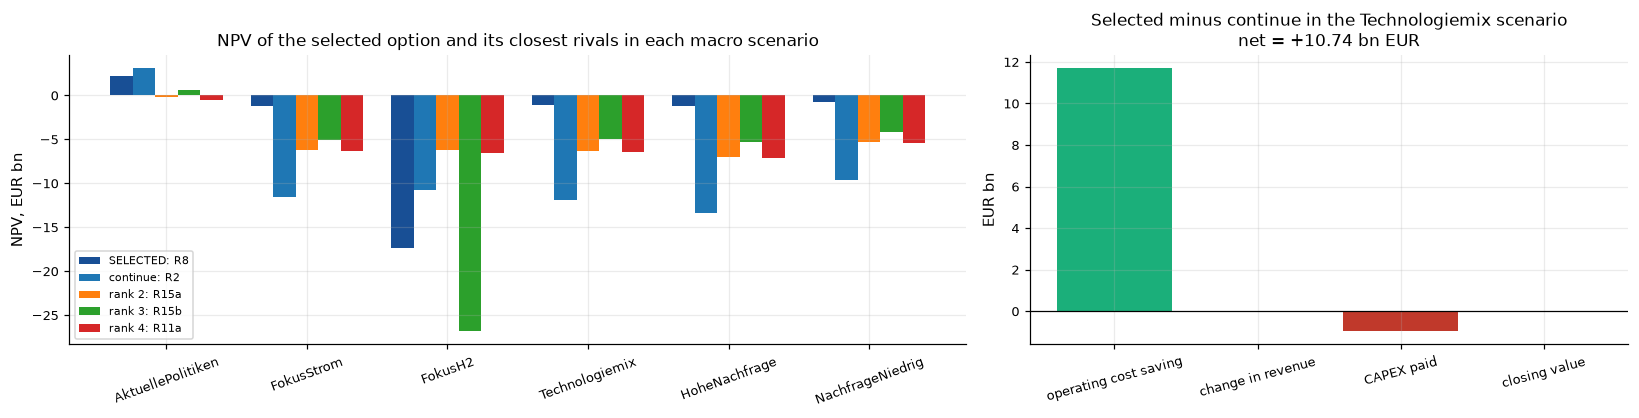

Cement | FokusH2 (RN) | plant P100000124212 | decision year 2025 | rule: expected_npv


rank,action,technology,expected NPV (bn),worst-case mean NPV (bn),expected shortfall NPV (bn),max regret (bn)
1.000000,invest_alternative_technology,R15a,-5.48,-5.87,-7.02,5.86
2.000000,invest_alternative_technology,R11a,-5.73,-6.00,-7.10,5.94
3.000000,invest_alternative_technology,R12a,-6.88,-6.96,-8.17,7.02
4.000000,invest_alternative_technology,R16,-7.02,-7.49,-9.32,8.17
5.000000,invest_alternative_technology,R3,-7.69,-8.09,-10.02,8.87
6.000000,invest_alternative_technology,R7,-7.79,-7.79,-10.72,6.26


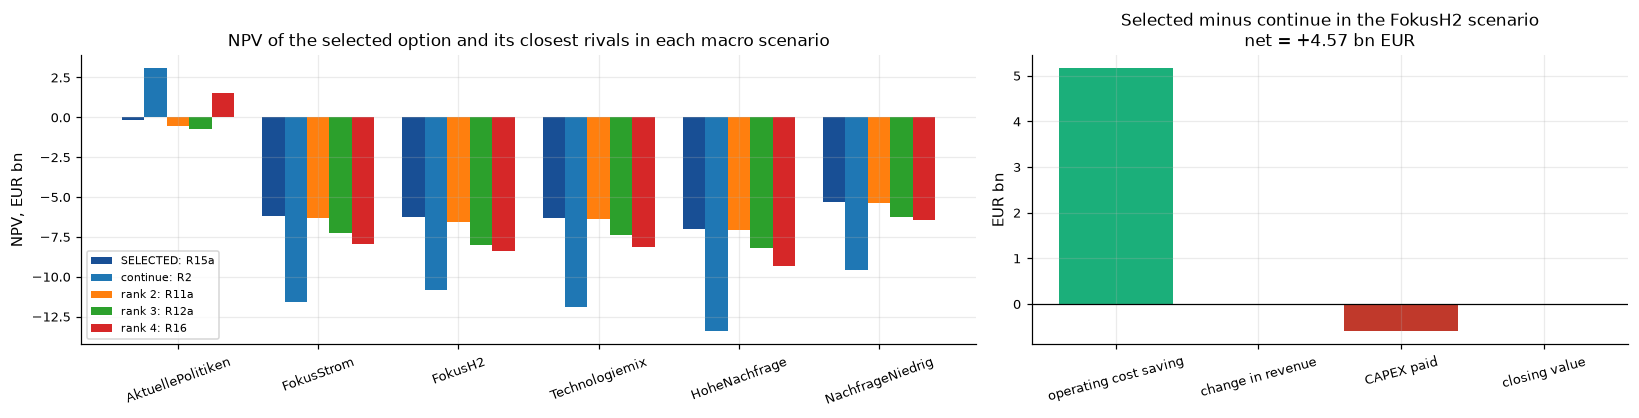

Cement | WorstCaseMean (RA) | plant P100000124212 | decision year 2025 | rule: worst_case_mean


rank,action,technology,expected NPV (bn),worst-case mean NPV (bn),expected shortfall NPV (bn),max regret (bn)
1.000000,invest_alternative_technology,R15a,-5.52,-5.87,-7.02,5.86
2.000000,invest_alternative_technology,R11a,-5.65,-6.00,-7.10,5.94
3.000000,invest_alternative_technology,R12a,-6.56,-6.96,-8.17,7.02
4.000000,invest_alternative_technology,R16,-6.91,-7.49,-9.32,8.17
5.000000,invest_alternative_technology,R7,-5.69,-7.79,-10.72,6.26
6.000000,invest_alternative_technology,R3,-7.48,-8.09,-10.02,8.87


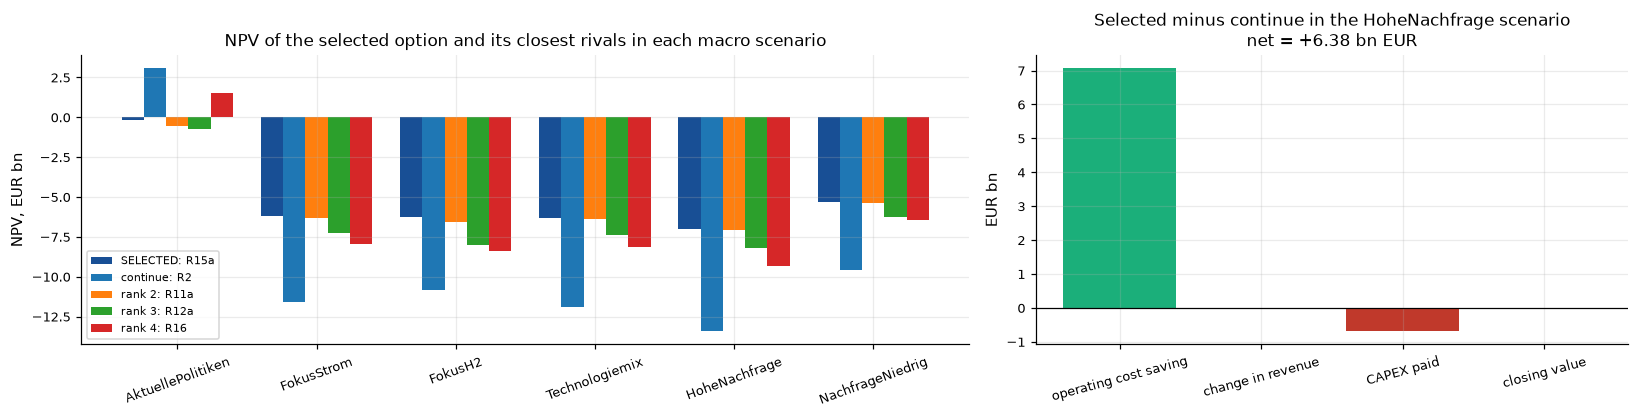

In [28]:
def explain_decision(sector: str, case: str, plant_id: str, year: int = 2025, n_rivals: int = 3, show: bool = True):
    scores = AUR[sector][case]["scores"]
    sc = scores[(scores.plant_id == plant_id) & (scores.year == year)].sort_values("rank")
    sel = sc[sc.selected].iloc[0]
    agg = CF[(sector, case)]
    a = agg[(agg.plant_id == plant_id) & (agg.decision_year == year)]
    cont = sc[sc.action == "continue_current"].iloc[0]
    rivals = sc[~sc.selected & (sc.action != "continue_current")].head(n_rivals)
    show_ids = [sel.decision_id, cont.decision_id, *rivals.decision_id]
    npv = a[a.candidate_decision_id.isin(show_ids)].pivot(index="candidate_decision_id", columns="scenario", values="npv").loc[show_ids, MACROS] / 1e9
    labels = {sel.decision_id: f"SELECTED: {sel.technology_id}", cont.decision_id: f"continue: {cont.technology_id}"}
    for _, r in rivals.iterrows():
        labels[r.decision_id] = f"rank {int(r['rank'])}: {r.technology_id}"
    metric = sel.risk_metric
    if year == AUR[sector][case]["selected"].year.min() or True:
        pass
    # decomposition selected minus continue in the binding scenario
    binding = npv.loc[sel.decision_id].idxmin() if "risk_averse" in case else MATCHED_MACRO[case]
    d_sel = a[(a.candidate_decision_id == sel.decision_id) & (a.scenario == binding)].iloc[0]
    d_con = a[(a.candidate_decision_id == cont.decision_id) & (a.scenario == binding)].iloc[0]
    comp = {"operating cost saving": d_con.d_opex - d_sel.d_opex, "change in revenue": d_sel.d_revenue - d_con.d_revenue,
            "CAPEX paid": -(d_sel.d_capex - d_con.d_capex), "closing value": d_sel.d_terminal - d_con.d_terminal}
    comp_bn = {k: v / 1e9 for k, v in comp.items()}
    if not show:
        return sel, npv, comp_bn
    table = sc.head(n_rivals + 3)[["rank", "action", "technology_id", "expected_npv", "robust_worst_case_mean_npv",
                                   "robust_expected_shortfall_npv", "max_regret"]].copy()
    for c in ("expected_npv", "robust_worst_case_mean_npv", "robust_expected_shortfall_npv", "max_regret"):
        table[c] = table[c] / 1e9
    table.columns = ["rank", "action", "technology", "expected NPV (bn)", "worst-case mean NPV (bn)",
                     "expected shortfall NPV (bn)", "max regret (bn)"]
    print(f"{SECTORS[sector]['title']} | {CASE_SHORT[case]} | plant {plant_id} | decision year {year} | rule: {metric}")
    display(table.style.hide(axis="index").format({c: "{:,.2f}" for c in table.columns if "bn" in c}))
    fig, axes = plt.subplots(1, 2, figsize=(15, 3.9), gridspec_kw={"width_ratios": [1.5, 1]})
    w = 0.8 / len(show_ids)
    for k, did in enumerate(show_ids):
        axes[0].bar(np.arange(6) + k * w, npv.loc[did], width=w, label=labels[did],
                    color=("#184f95" if did == sel.decision_id else None))
    axes[0].set_xticks(np.arange(6) + 0.4 - w / 2, [MACRO_TITLE[m] for m in MACROS], rotation=20)
    axes[0].set_ylabel("NPV, EUR bn"); axes[0].legend(fontsize=7)
    axes[0].set_title("NPV of the selected option and its closest rivals in each macro scenario")
    names = list(comp_bn)
    axes[1].bar(names, [comp_bn[n] for n in names], color=["#1baf7a" if comp_bn[n] >= 0 else "#c0392b" for n in names])
    axes[1].axhline(0, color="black", linewidth=0.8)
    axes[1].set_ylabel("EUR bn"); axes[1].tick_params(axis="x", rotation=15)
    axes[1].set_title(f"Selected minus continue in the {MACRO_TITLE[binding]} scenario\n"
                      f"net = {sum(comp_bn.values()):+.2f} bn EUR")
    fig.tight_layout()
    plt.show()
    return sel, npv, comp_bn


# Biggest plant of each sector, risk-neutral versus risk-averse view of the same plant.
for sector in SECTORS:
    cap = AUR[sector][CASES[0]]["pathway"].groupby("plant_id")["capacity"].max().sort_values(ascending=False)
    big = cap.index[0]
    for case in ("Technologiemix_risk_neutral", "FokusH2_risk_neutral", "WorstCaseMean_risk_averse"):
        explain_decision(sector, case, big, 2025)

**Key findings: decision dossiers**

* **Steel, largest plant (P100000120421), Technologiemix.** The top four candidates are within 1.3 EUR bn of expected NPV (22.70, 22.34, 21.81, 21.47). The fourth, the hydrogen route with on-site electrolyser, has a worst-case mean NPV of minus 10.7 EUR bn and an expected-shortfall NPV of minus 40.3 EUR bn, against 22.2 and 19.8 for the winner. A risk-neutral ranking on expected NPV hides this difference. FokusH2 and the risk-averse rule choose the network-hydrogen hybrid route as well, which here is simply the robust winner.
* **Cement, largest plant (P100000124212).** Technologiemix selects R8 (expected NPV minus 1.71 EUR bn against minus 5.52 for R15a), but R8 has a worst-case mean of minus 9.8 against minus 5.9 and an expected shortfall of minus 17.3 against minus 7.0. The worst-case rules therefore switch to R15a.
* **Where the value comes from.** For steel the old coal plants have about six years of life left, so *continue* means producing until 2030 with almost no margin (0.04 EUR bn a year) and then collecting a lump-sum continuation value (22.6 EUR bn in 2031 in the Technologiemix scenario). Investing keeps revenue flowing for the whole horizon (+48.4 EUR bn discounted), at higher operating cost (minus 29.6), CAPEX (minus 1.5) and a lower closing value (minus 13.5): a net gain of 3.8 EUR bn in that scenario. For cement the old plants run through the horizon in both options, so the gain is purely an operating-cost saving: +11.7 EUR bn for R8 against CAPEX of 0.95 EUR bn (+7.1 and 0.7 for R15a under the worst-case-mean rule in its binding scenario).

### 6.6 Do the cases agree? Who deviates from whom

For every plant and year, the table counts how often a risk-averse case selects a different technology than a given risk-neutral case. Plants where the rules disagree are the ones where the belief or the risk attitude matters.

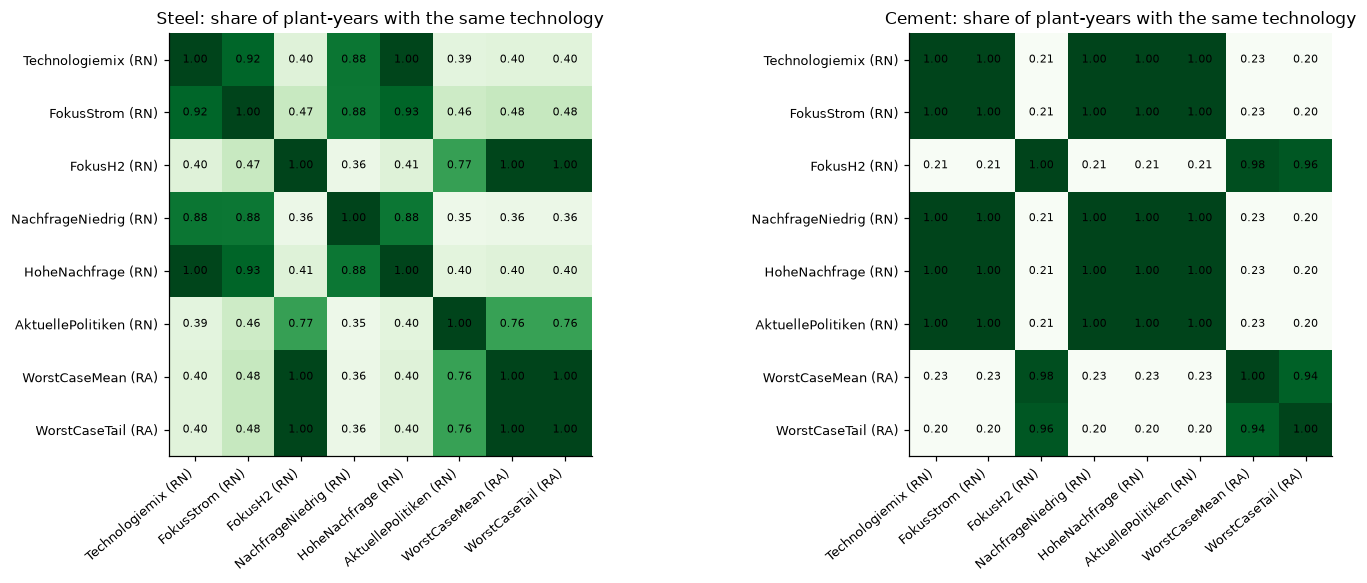

In [29]:
def agreement_matrix(sector: str) -> pd.DataFrame:
    pw = {c: AUR[sector][c]["pathway"].set_index(["plant_id", "year"])["active_technology_id"] for c in CASES}
    m = pd.DataFrame(index=CASES, columns=CASES, dtype=float)
    for a in CASES:
        for b in CASES:
            m.loc[a, b] = (pw[a] == pw[b]).mean()
    return m


fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))
for ax, sector in zip(axes, SECTORS):
    m = agreement_matrix(sector)
    ax.imshow(m.to_numpy(), cmap="Greens", vmin=0.3, vmax=1)
    ax.set_xticks(range(8), [CASE_SHORT[c] for c in CASES], rotation=40, ha="right")
    ax.set_yticks(range(8), [CASE_SHORT[c] for c in CASES])
    for i in range(8):
        for j in range(8):
            ax.text(j, i, f"{m.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7.5)
    ax.set_title(f"{SECTORS[sector]['title']}: share of plant-years with the same technology")
    ax.grid(False)
fig.tight_layout()
plt.show()

**Key findings: agreement between cases**

The agreement matrix shows two clusters in each sector, not eight different strategies: one around the electricity-and-on-site-hydrogen technologies (Technologiemix, FokusStrom, NachfrageNiedrig, HoheNachfrage; for steel with some differences) and one around the hydrogen-network technologies (FokusH2, AktuellePolitiken in steel, both risk-averse cases). The risk-averse rules reproduce the FokusH2 pathway almost exactly (steel 100 percent, cement 94 to 98 percent), which means the FokusH2 world is the binding worst case.

## 7. Energy demand by carrier and emissions of the chosen pathways

**Question.** If every plant follows its case's pathway, how much fuel and electricity does the sector use, and how much CO2 does it emit?

Method: for each case, plant and anchor year (2030, 2035, 2040, 2045), the plant's technology is read from the AURIS pathway and its annual physical results are taken from the FLEXIMOD simulation of exactly that technology in the chosen macro scenario. Sector totals are sums over plants.

**Reference world.** To compare the eight cases like for like, all cases are first evaluated in one common macro scenario, `REFERENCE_MACRO`. Differences between cases then come from the technology choice alone. Section 7.5 shows how much the answer moves when the world changes.

In [30]:
def build_chain(sector: str) -> pd.DataFrame:
    frames = []
    for case in CASES:
        pw = AUR[sector][case]["pathway"]
        pw = pw[pw.year.isin(ANCHORS)][["plant_id", "year", "active_technology_id", "capacity"]]
        frames.append(pw.assign(case=case))
    pw = pd.concat(frames, ignore_index=True).rename(columns={"active_technology_id": "technology"})
    sim = SIM[sector].drop(columns=["plant_name"])
    ch = pw.merge(sim, on=["plant_id", "technology", "year"], how="left", validate="m:m")
    assert ch["production_t"].notna().all(), "pathway technology without simulation result"
    ch["sector"] = sector
    return ch


def build_no_investment(sector: str) -> pd.DataFrame:
    """Counterfactual: every plant keeps the technology it operated before AURIS's first decision."""
    ev = AUR[sector][CASES[0]]["events"].sort_values("year").groupby("plant_id").first()["old_technology_id"]
    cap = AUR[sector][CASES[0]]["pathway"].groupby("plant_id")["capacity"].max()
    pw = pd.DataFrame([(p, y, ev[p], cap[p]) for p in ev.index for y in ANCHORS],
                      columns=["plant_id", "year", "technology", "capacity"])
    ch = pw.merge(SIM[sector].drop(columns=["plant_name"]), on=["plant_id", "technology", "year"], how="left")
    assert ch["production_t"].notna().all()
    ch["case"], ch["sector"] = NOINV, sector
    return ch


NOINV = "NoInvestment"
CASE_SHORT[NOINV] = "No investment"
CHAIN = pd.concat([build_chain(s) for s in SECTORS] + [build_no_investment(s) for s in SECTORS], ignore_index=True)
for car, col in CARRIER_COL.items():
    CHAIN[car + "_GWh"] = CHAIN[col] / 1e3
CHAIN["co2_Mt"] = CHAIN["total_co2_emissions_t"] / 1e6
CHAIN["production_Mt"] = CHAIN["production_t"] / 1e6
CHAIN["da_afrr_GWh"] = (CHAIN["total_DA_electricity_MWh"] + CHAIN["total_afrr_energy_activated_MWh"]) / 1e3
print(f"{len(CHAIN):,} rows = case x plant x anchor year x macro scenario")

tot_cols = ["production_Mt", "co2_Mt", "da_afrr_GWh", *[c + "_GWh" for c in CARRIERS]]
SECTOR_TOT = CHAIN.groupby(["sector", "case", "macro", "year"])[tot_cols].sum().reset_index()
SECTOR_TOT["final_energy_GWh"] = SECTOR_TOT[[c + "_GWh" for c in CARRIERS]].sum(axis=1)
SECTOR_TOT["case"] = SECTOR_TOT["case"].astype(str)

# comparability check: do all cases serve the same product demand in the reference world?
prod = SECTOR_TOT[(SECTOR_TOT.macro == REFERENCE_MACRO) & (SECTOR_TOT.case != NOINV)].pivot_table(index=["sector", "year"], columns="case", values="production_Mt")
display(prod.rename(columns=CASE_SHORT).style.format("{:.2f}").set_caption(
    f"Production (Mt) in the reference world ({MACRO_TITLE[REFERENCE_MACRO]}); equal across cases means the comparison is like for like"))

8,856 rows = case x plant x anchor year x macro scenario


### 7.1 What the plants burn: final energy by carrier

One panel per anchor year; one bar per case. Hydrogen and electricity replace coal and natural gas as the pathways proceed. Electricity is the plant's total electricity use, including the electricity that on-site electrolysers need to make hydrogen; that hydrogen is also counted as hydrogen consumed, so the stacked total counts it twice for electrolyser routes.

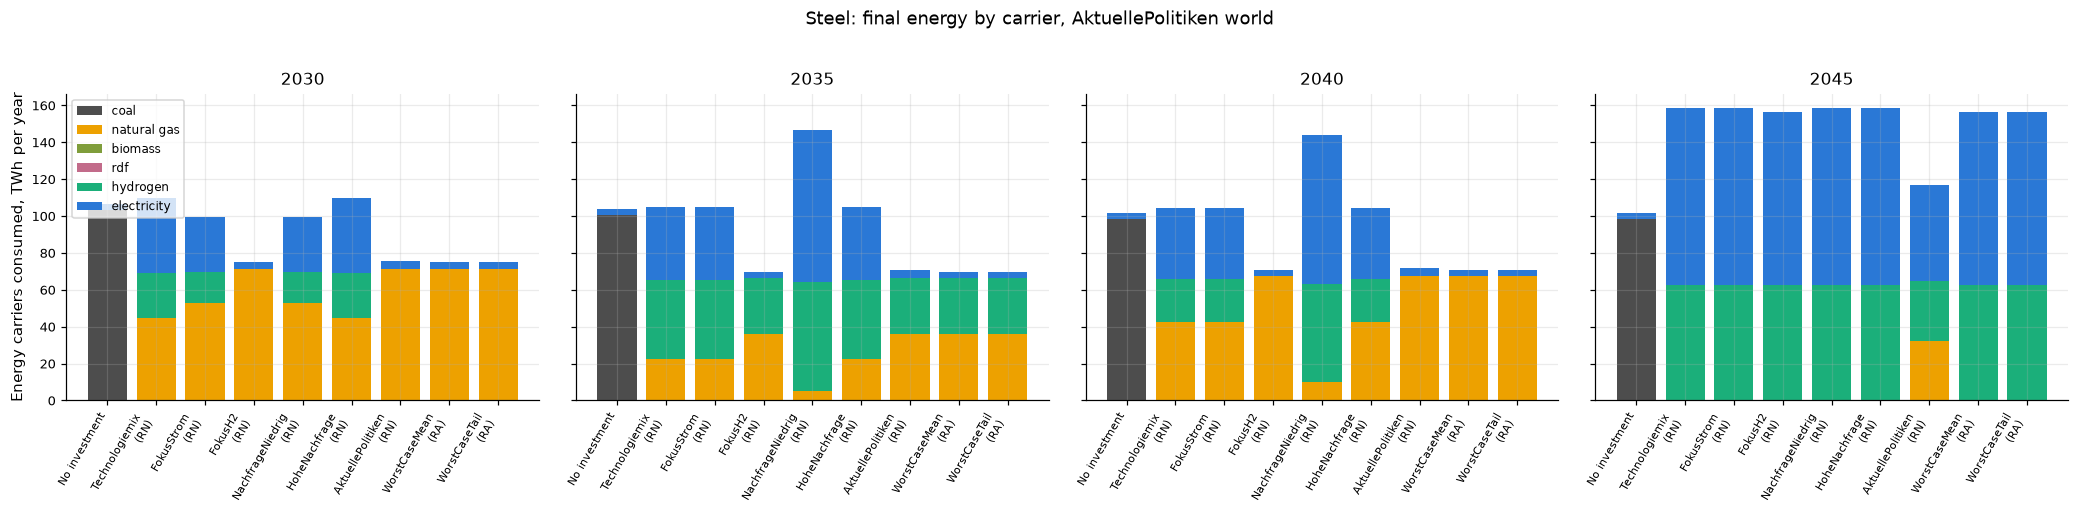

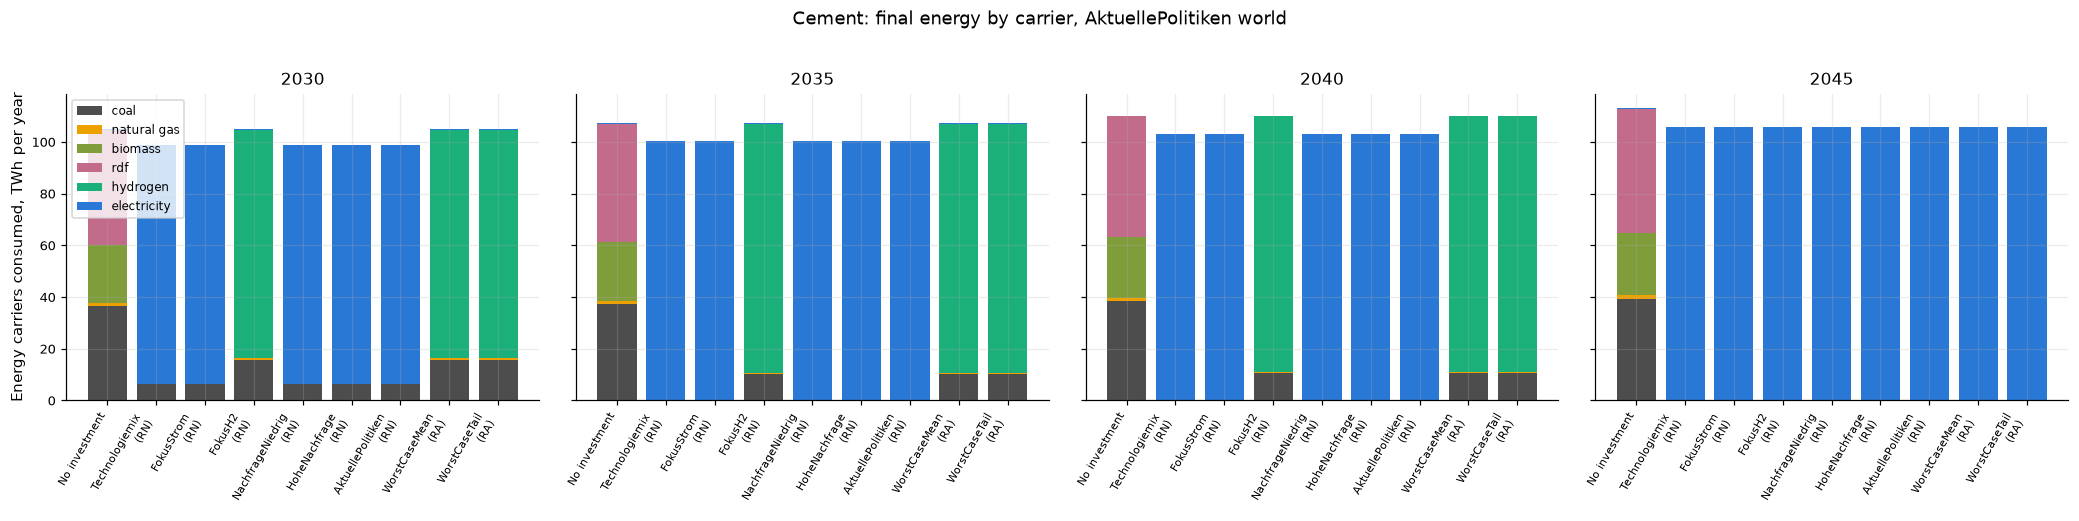

In [31]:
def plot_energy_by_case(sector: str, macro: str):
    d = SECTOR_TOT[(SECTOR_TOT.sector == sector) & (SECTOR_TOT.macro == macro)]
    fig, axes = plt.subplots(1, 4, figsize=(19, 4.6), sharey=True)
    for ax, year in zip(axes, ANCHORS):
        sub = d[d.year == year].set_index("case").loc[[NOINV, *CASES]]
        bottom = np.zeros(len(sub))
        for car in CARRIERS:
            ax.bar(range(len(sub)), sub[car + "_GWh"] / 1e3, bottom=bottom, color=CARRIER_COLOR[car], label=car.replace("_", " "))
            bottom += (sub[car + "_GWh"] / 1e3).to_numpy()
        ax.set_xticks(range(len(sub)), [CASE_SHORT[c].replace(" (", "\n(") for c in [NOINV, *CASES]], rotation=60, ha="right", fontsize=7.5)
        ax.set_title(str(year))
    axes[0].set_ylabel("Energy carriers consumed, TWh per year")
    axes[0].legend(loc="upper left")
    fig.suptitle(f"{SECTORS[sector]['title']}: final energy by carrier, {MACRO_TITLE[macro]} world", y=1.02)
    fig.tight_layout()
    plt.show()


for s in SECTORS:
    plot_energy_by_case(s, REFERENCE_MACRO)

### 7.2 Energy by carrier, case, invested technology and year

One panel per case (rows) and energy carrier (columns). Each bar is one anchor year; its colour segments show which invested technology causes that demand. Read a row to see how a case's technology change moves each carrier over time; read a column to compare cases for one carrier. Reference world as above. The underlying table is saved as `data/output/auris_energy_by_carrier_case_technology.csv`.

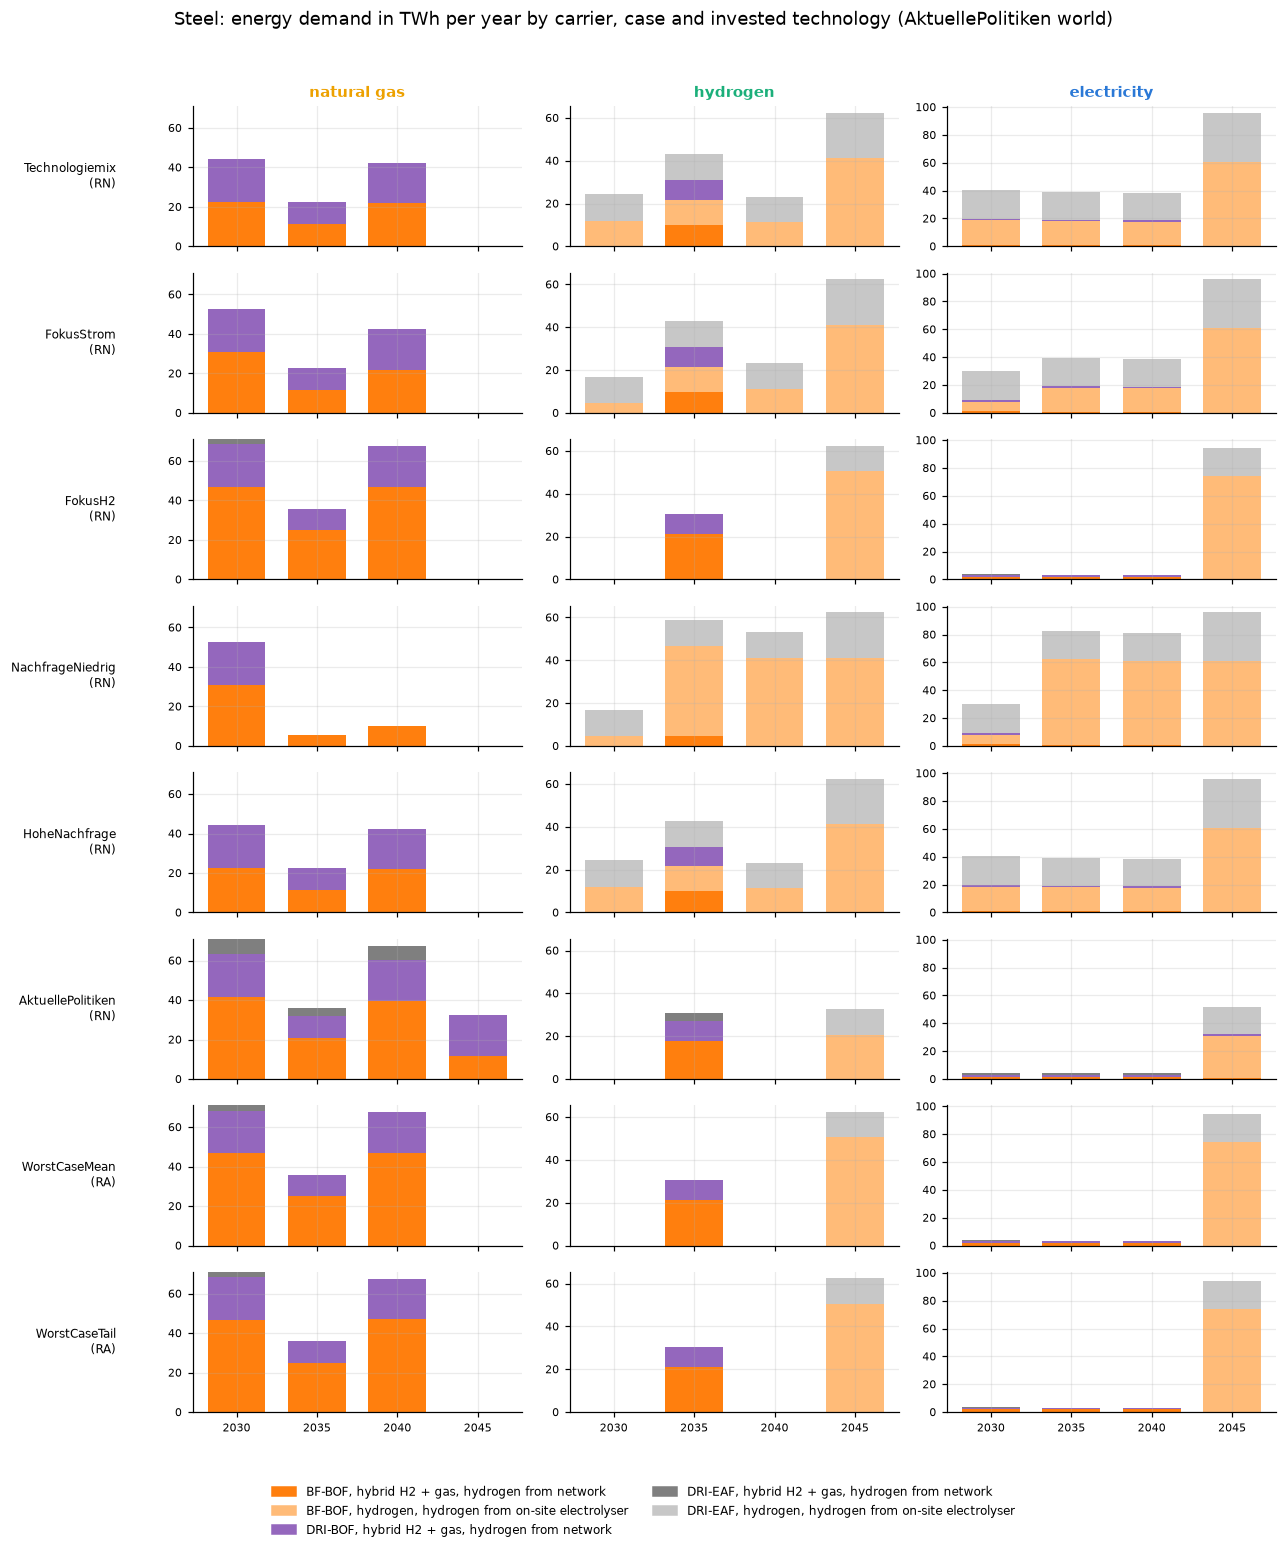

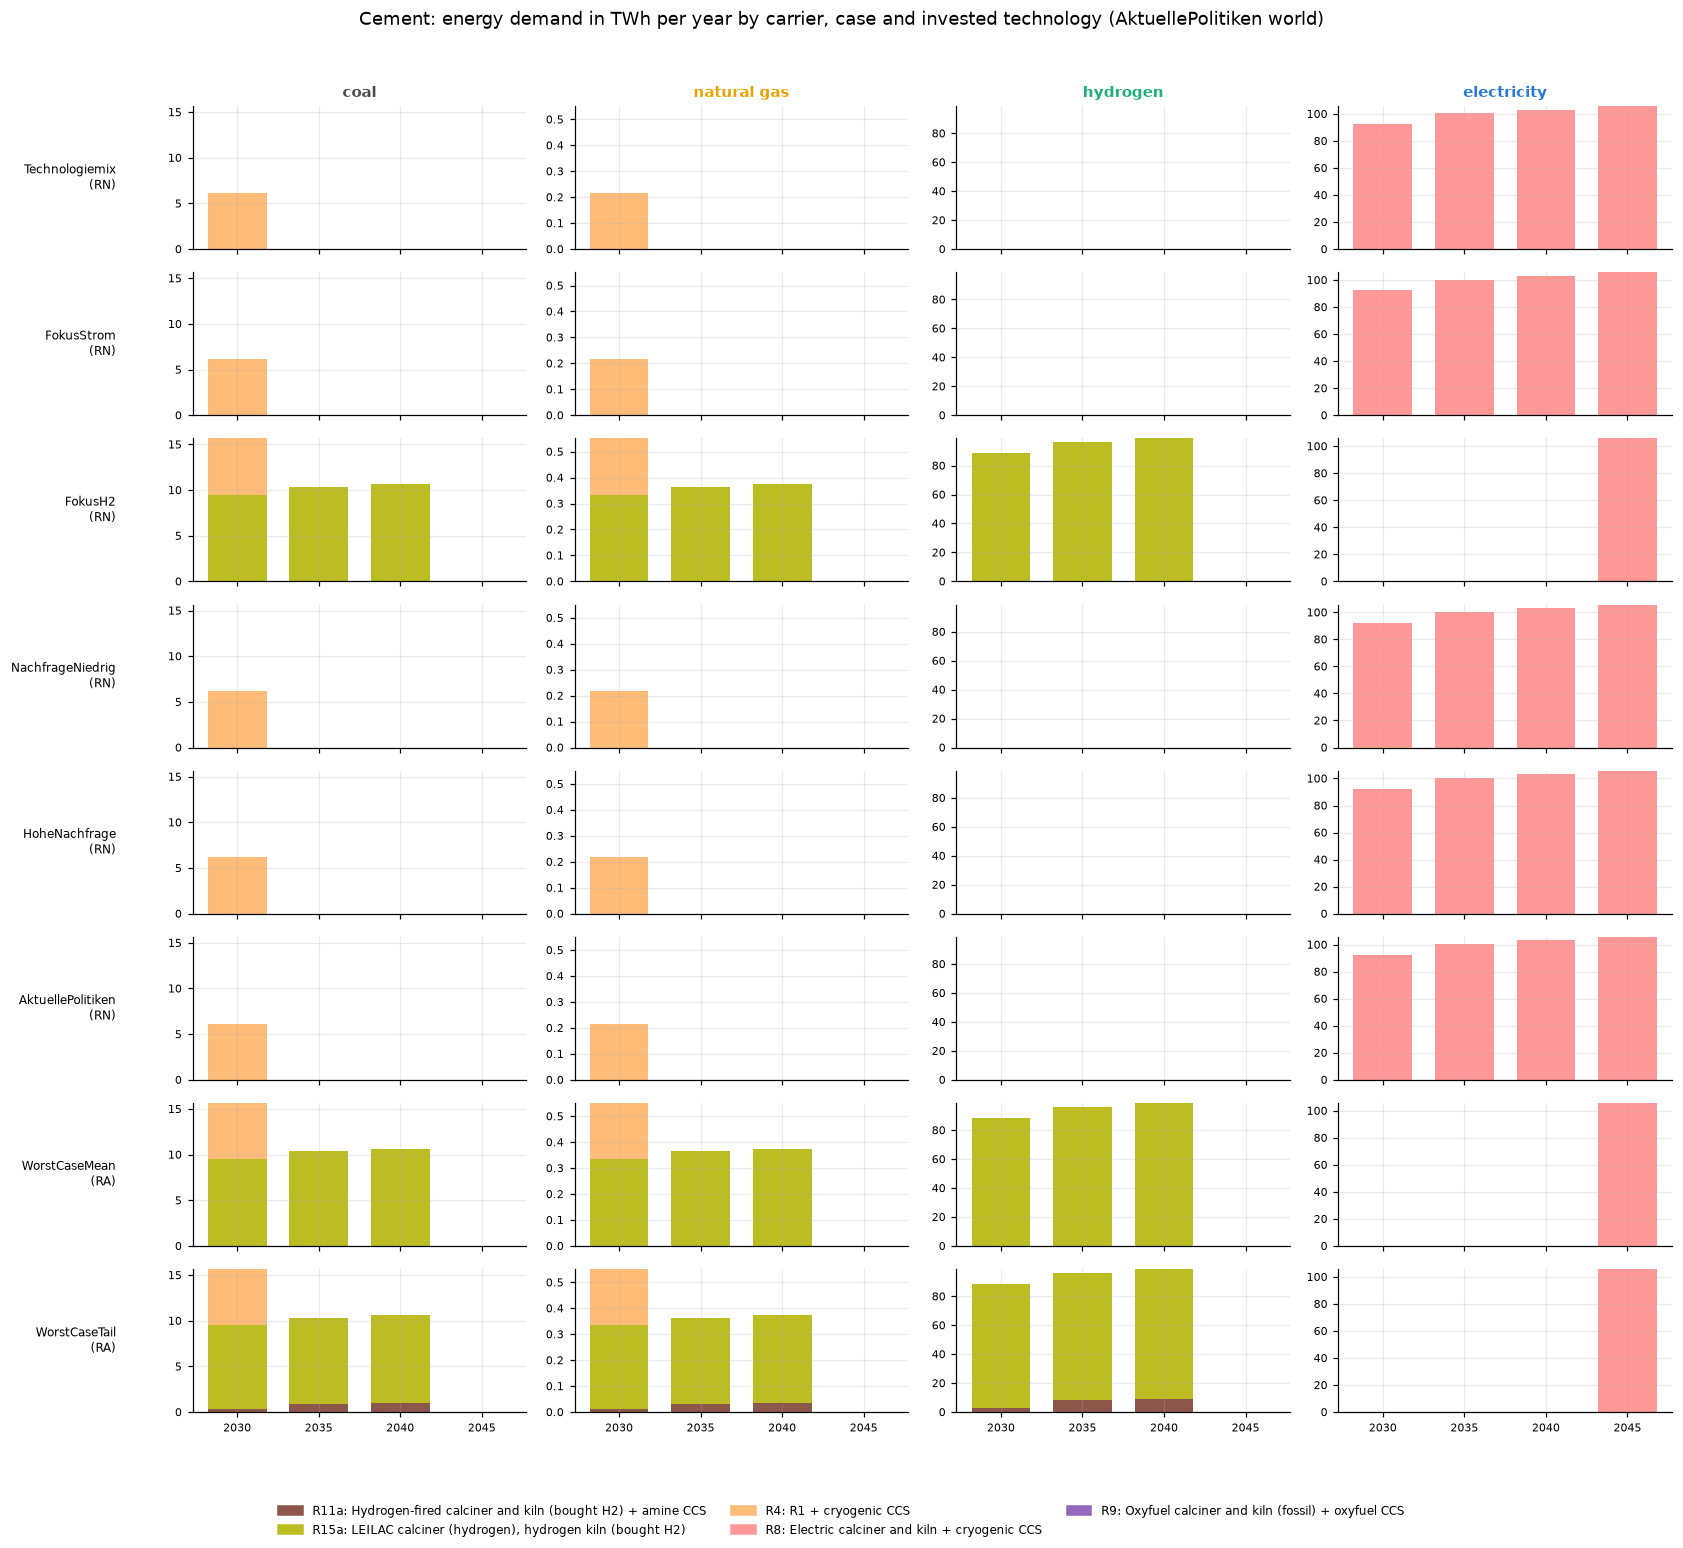

In [32]:
carrier_cols = {c: c + "_GWh" for c in CARRIERS}
ebt = (CHAIN[(CHAIN.macro == REFERENCE_MACRO) & (CHAIN.case != NOINV)]
       .groupby(["sector", "case", "year", "technology"])[list(carrier_cols.values())].sum().reset_index())
ebt_long = ebt.melt(id_vars=["sector", "case", "year", "technology"], value_vars=list(carrier_cols.values()),
                    var_name="carrier", value_name="energy_TWh")
ebt_long["carrier"] = ebt_long["carrier"].str.replace("_GWh", "", regex=False)
ebt_long["energy_TWh"] = ebt_long["energy_TWh"] / 1e3
ebt_long.to_csv(FLEX / "data/output/auris_energy_by_carrier_case_technology.csv", index=False)


def plot_energy_by_carrier_technology(sector: str):
    d = ebt_long[ebt_long.sector == sector]
    carriers = [c for c in CARRIERS if d[d.carrier == c].energy_TWh.sum() > 1e-6]
    techs = sorted(USED[sector])
    fig, axes = plt.subplots(len(CASES), len(carriers), figsize=(3.6 * len(carriers) + 1, 1.75 * len(CASES)),
                             sharex=True, sharey="col", squeeze=False)
    for i, case in enumerate(CASES):
        for j, car in enumerate(carriers):
            ax = axes[i, j]
            sub = d[(d.case == case) & (d.carrier == car)].pivot_table(index="year", columns="technology", values="energy_TWh", aggfunc="sum")
            sub = sub.reindex(index=ANCHORS, columns=techs).fillna(0.0)
            bottom = np.zeros(len(sub))
            for t in techs:
                ax.bar(range(len(sub)), sub[t], bottom=bottom, color=TECH_COLOR[(sector, t)], width=0.72)
                bottom += sub[t].to_numpy()
            ax.set_xticks(range(len(ANCHORS)), ANCHORS, fontsize=7.5)
            ax.tick_params(axis="y", labelsize=7)
            if i == 0:
                ax.set_title(car.replace("_", " "), fontsize=10, color=CARRIER_COLOR[car], fontweight="bold")
            if j == 0:
                ax.set_ylabel(CASE_SHORT[case].replace(" (", "\n("), fontsize=8, rotation=0, ha="right", va="center", labelpad=34)
    handles = [plt.matplotlib.patches.Patch(color=TECH_COLOR[(sector, t)], label=tech_long(sector, t)) for t in techs]
    fig.legend(handles=handles, loc="lower center", ncol=2 if sector == "steel" else 3, fontsize=8, frameon=False)
    fig.suptitle(f"{SECTORS[sector]['title']}: energy demand in TWh per year by carrier, case and invested technology "
                 f"({MACRO_TITLE[REFERENCE_MACRO]} world)", y=0.995)
    fig.tight_layout(rect=(0, 0.06, 1, 0.98))
    plt.show()


for s in SECTORS:
    plot_energy_by_carrier_technology(s)

### 7.3 The same view as stacked areas

Same data, drawn as stacked areas: in each panel the carriers are stacked on top of each other, so the height is the total energy and the layers show the carrier mix. Rows are cases. The first column adds all technologies; the other columns show only the demand caused by one invested technology (empty where a case never uses it). The areas connect the four simulated anchor years.

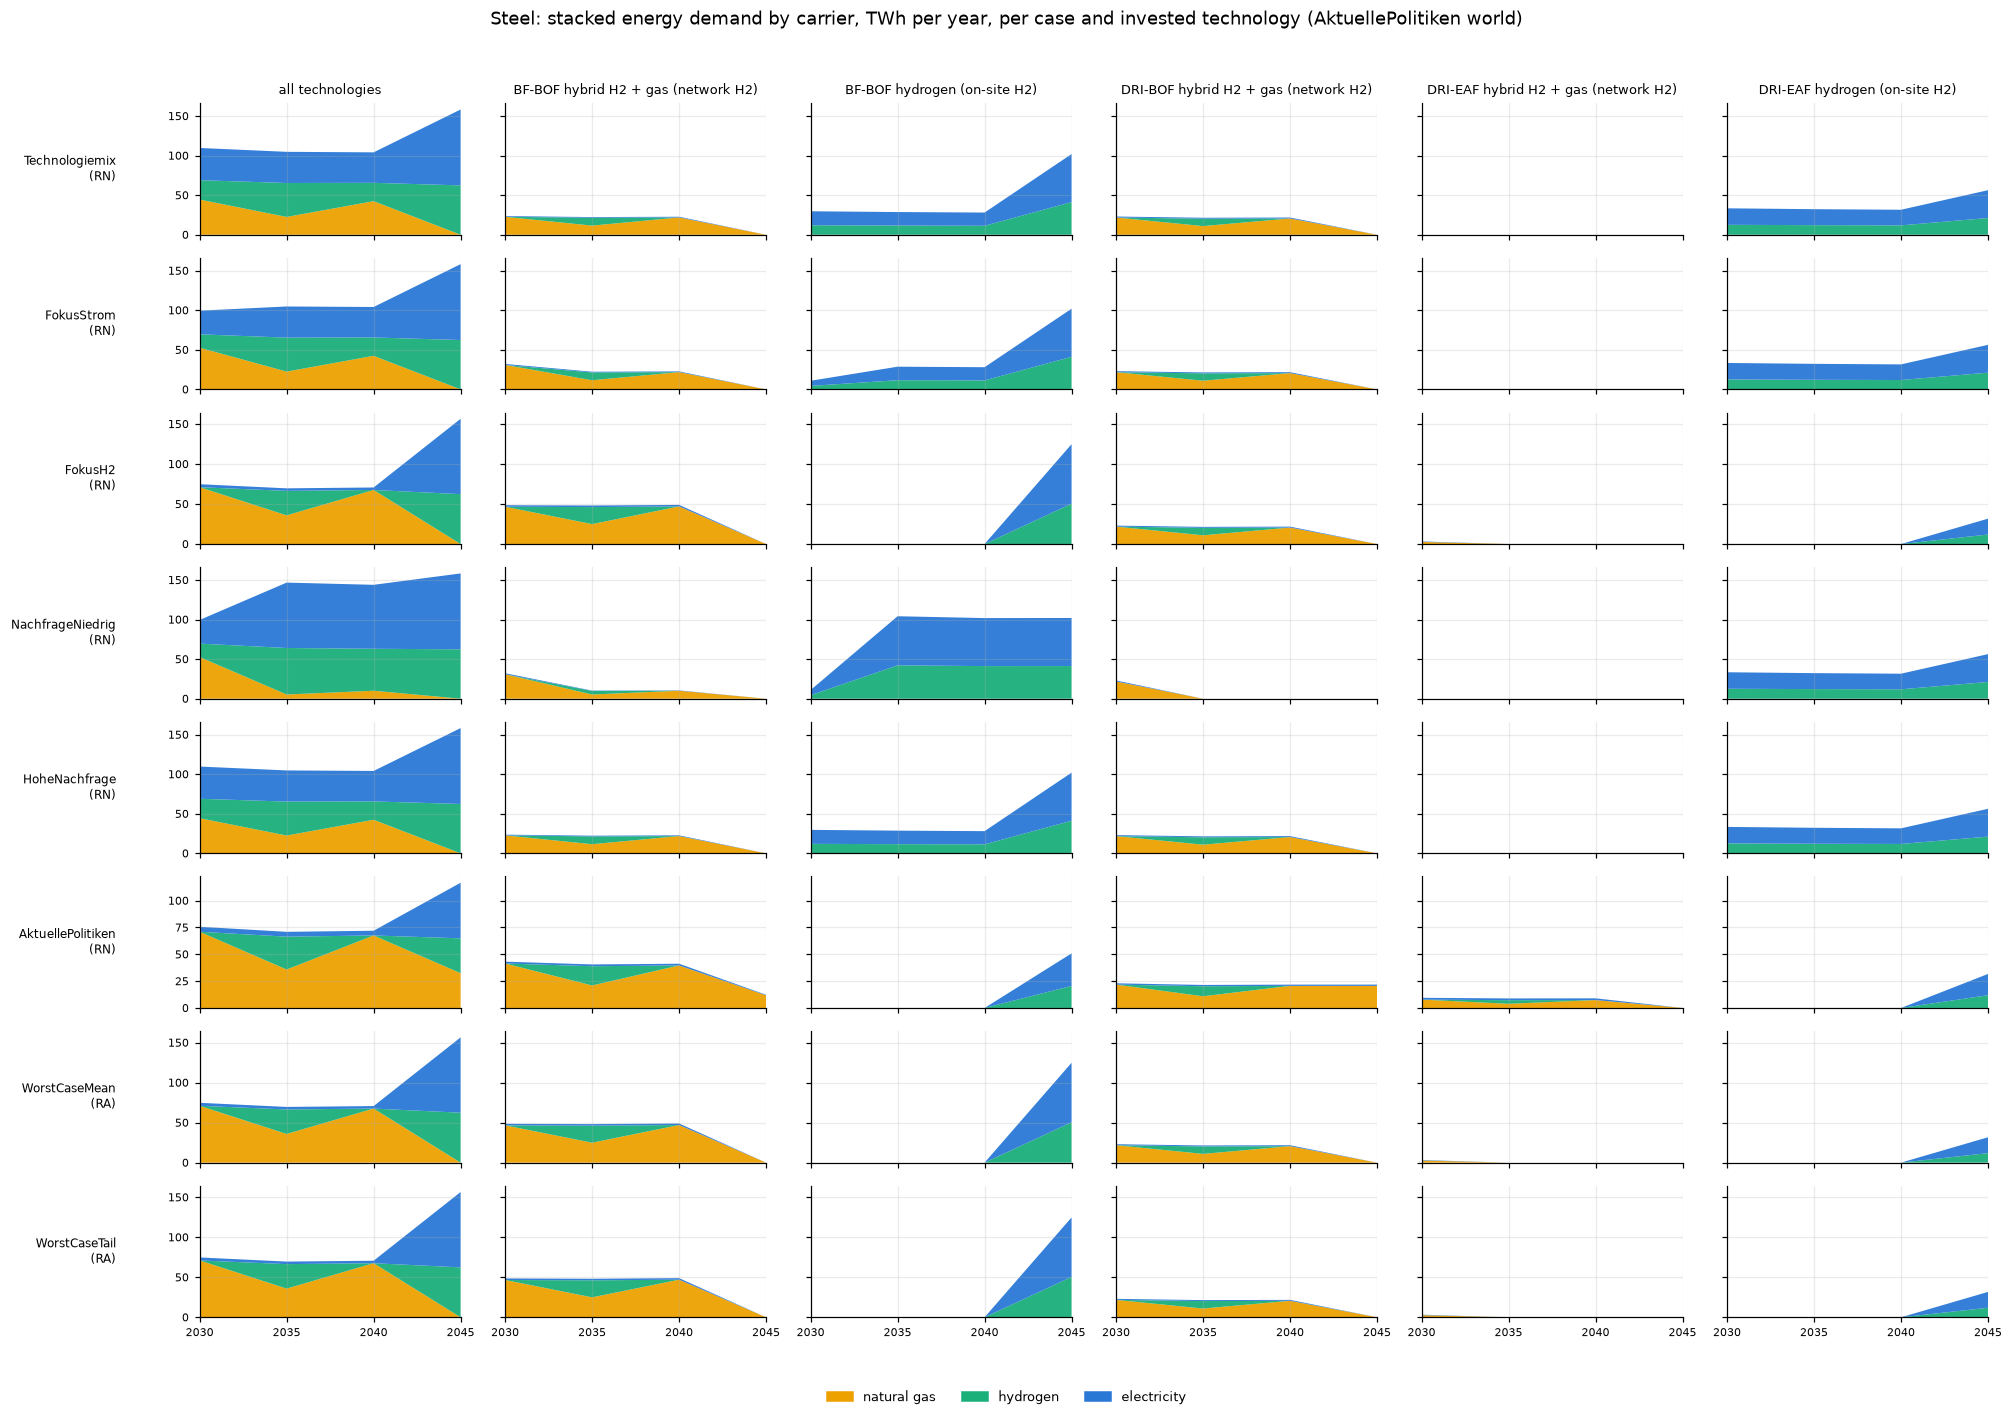

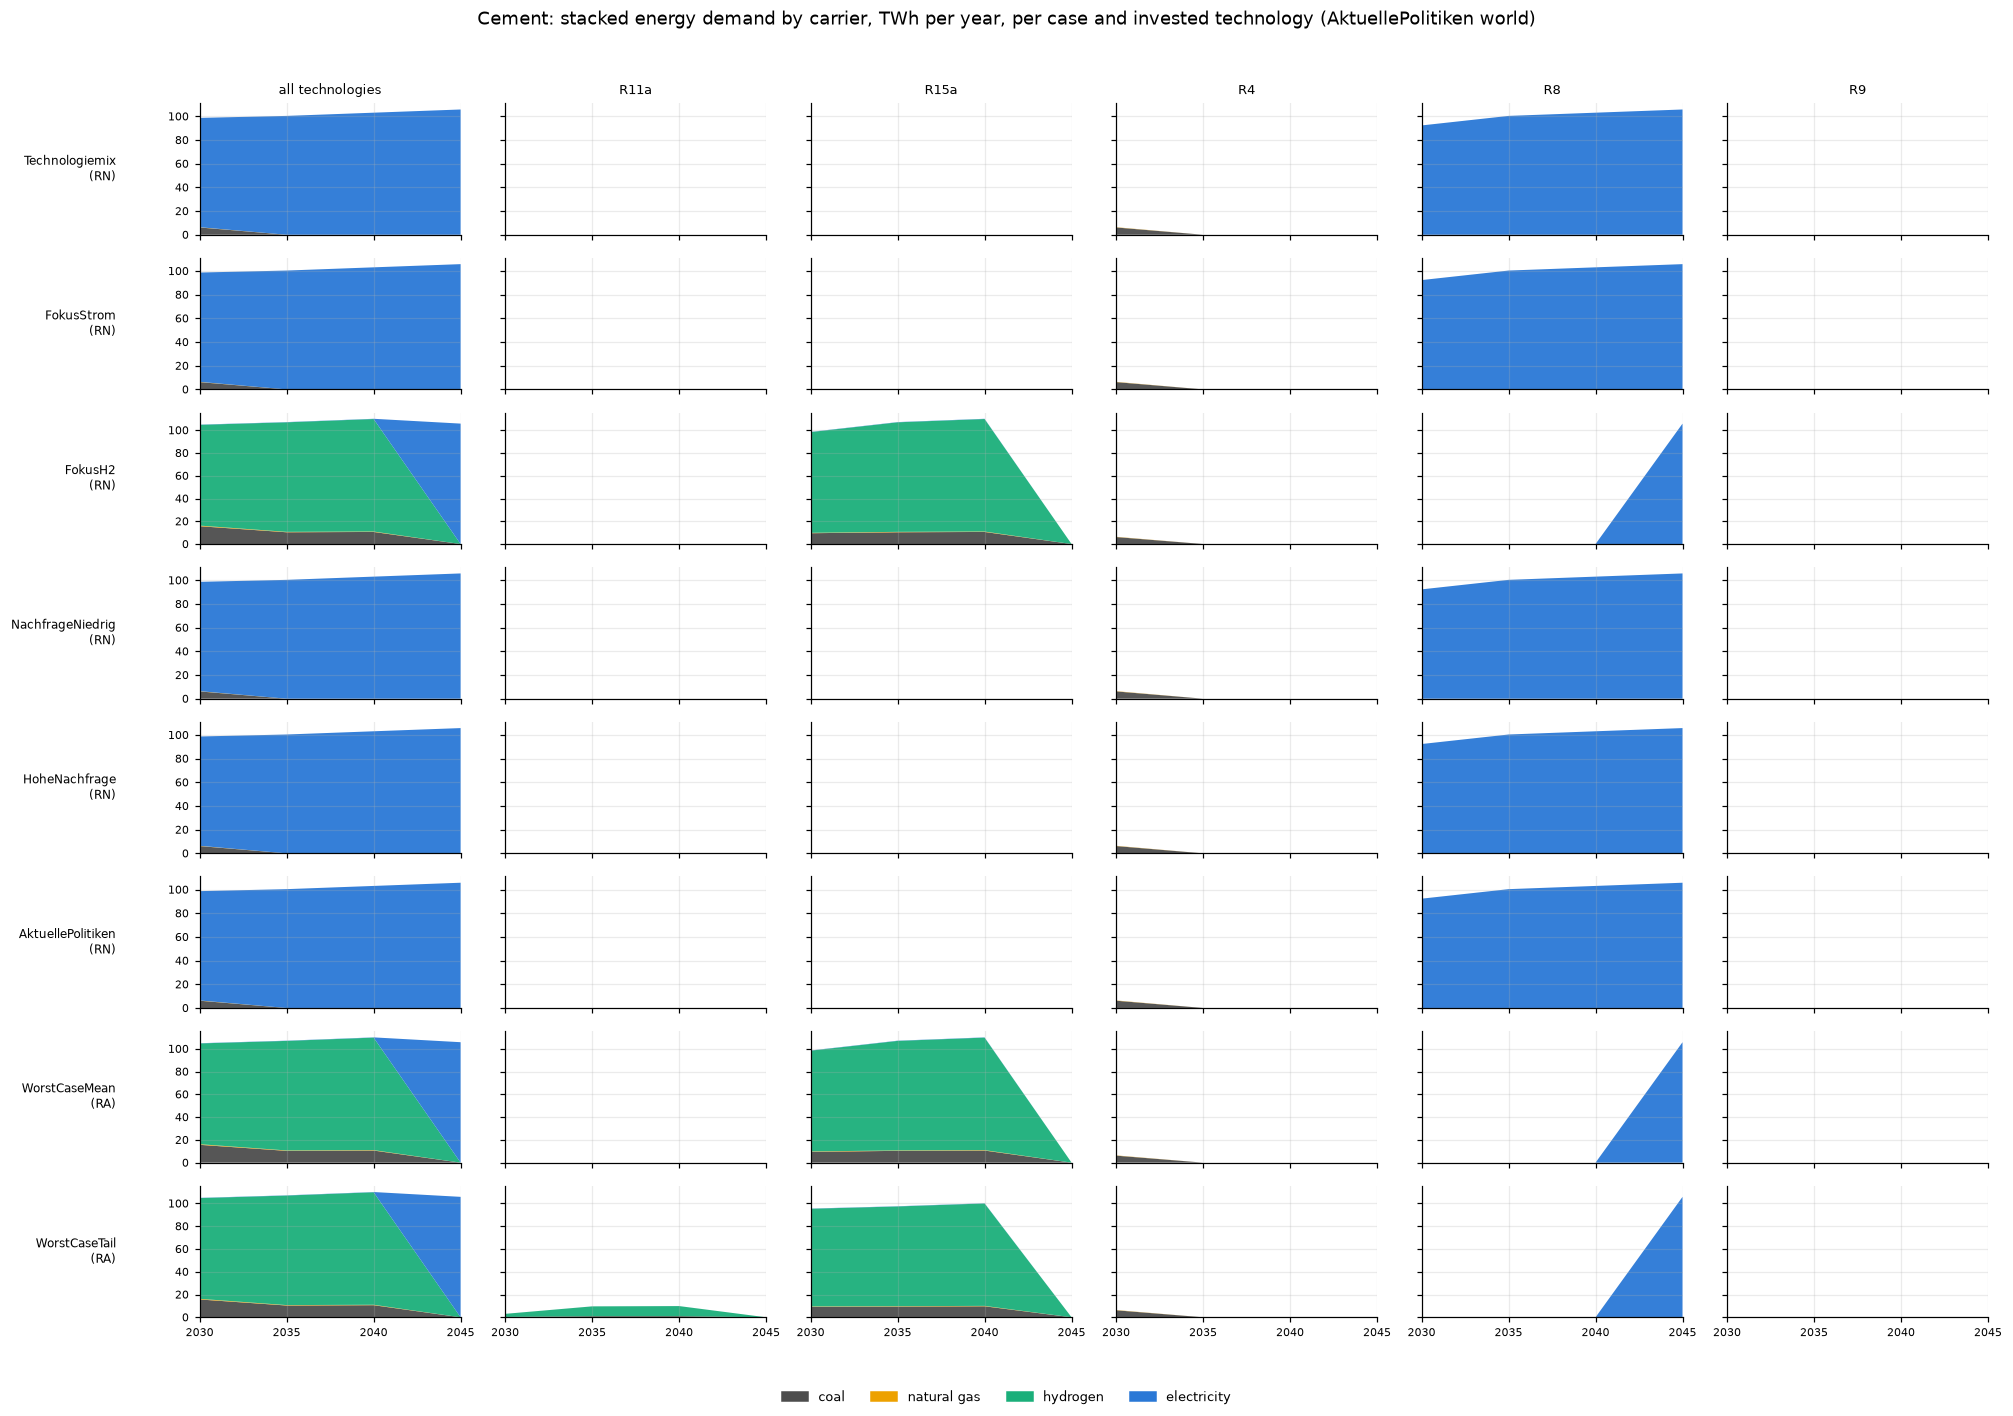

In [33]:
def plot_energy_areas(sector: str):
    d = ebt_long[ebt_long.sector == sector]
    carriers = [c for c in CARRIERS if d[d.carrier == c].energy_TWh.sum() > 1e-6]
    techs = sorted(USED[sector])
    columns = [None, *techs]
    fig, axes = plt.subplots(len(CASES), len(columns), figsize=(2.9 * len(columns) + 1, 1.6 * len(CASES)),
                             sharex=True, sharey="row", squeeze=False)
    for i, case in enumerate(CASES):
        for j, tech in enumerate(columns):
            ax = axes[i, j]
            sub = d[d.case == case] if tech is None else d[(d.case == case) & (d.technology == tech)]
            piv = (sub.pivot_table(index="year", columns="carrier", values="energy_TWh", aggfunc="sum")
                   .reindex(index=ANCHORS, columns=carriers).fillna(0.0))
            if piv.to_numpy().sum() > 1e-9:
                ax.stackplot(ANCHORS, piv.T.to_numpy(), colors=[CARRIER_COLOR[c] for c in carriers], alpha=0.95)
            ax.set_xlim(ANCHORS[0], ANCHORS[-1]); ax.set_xticks(ANCHORS, ANCHORS, fontsize=7)
            ax.tick_params(axis="y", labelsize=7)
            if i == 0:
                ax.set_title("all technologies" if tech is None else tech_label(sector, tech), fontsize=8.5)
            if j == 0:
                ax.set_ylabel(CASE_SHORT[case].replace(" (", "\n("), fontsize=8, rotation=0, ha="right", va="center", labelpad=34)
    handles = [plt.matplotlib.patches.Patch(color=CARRIER_COLOR[c], label=c.replace("_", " ")) for c in carriers]
    fig.legend(handles=handles, loc="lower center", ncol=len(carriers), fontsize=8.5, frameon=False)
    fig.suptitle(f"{SECTORS[sector]['title']}: stacked energy demand by carrier, TWh per year, per case and invested technology "
                 f"({MACRO_TITLE[REFERENCE_MACRO]} world)", y=0.995)
    fig.tight_layout(rect=(0, 0.04, 1, 0.98))
    plt.show()


for s in SECTORS:
    plot_energy_areas(s)

### 7.3b Energy demand by carrier, one panel per case

Same idea as the fleet-mix plot of section 5.1, applied to energy instead of capacity: one panel per case, the carrier share of final energy stacked to 100 percent, read across the four anchor years (reference world). A case whose colours barely move is burning the same mix of fuels throughout; a case whose colours flip is switching fuel, not just technology (see section 5.1's note on the hybrid routes).

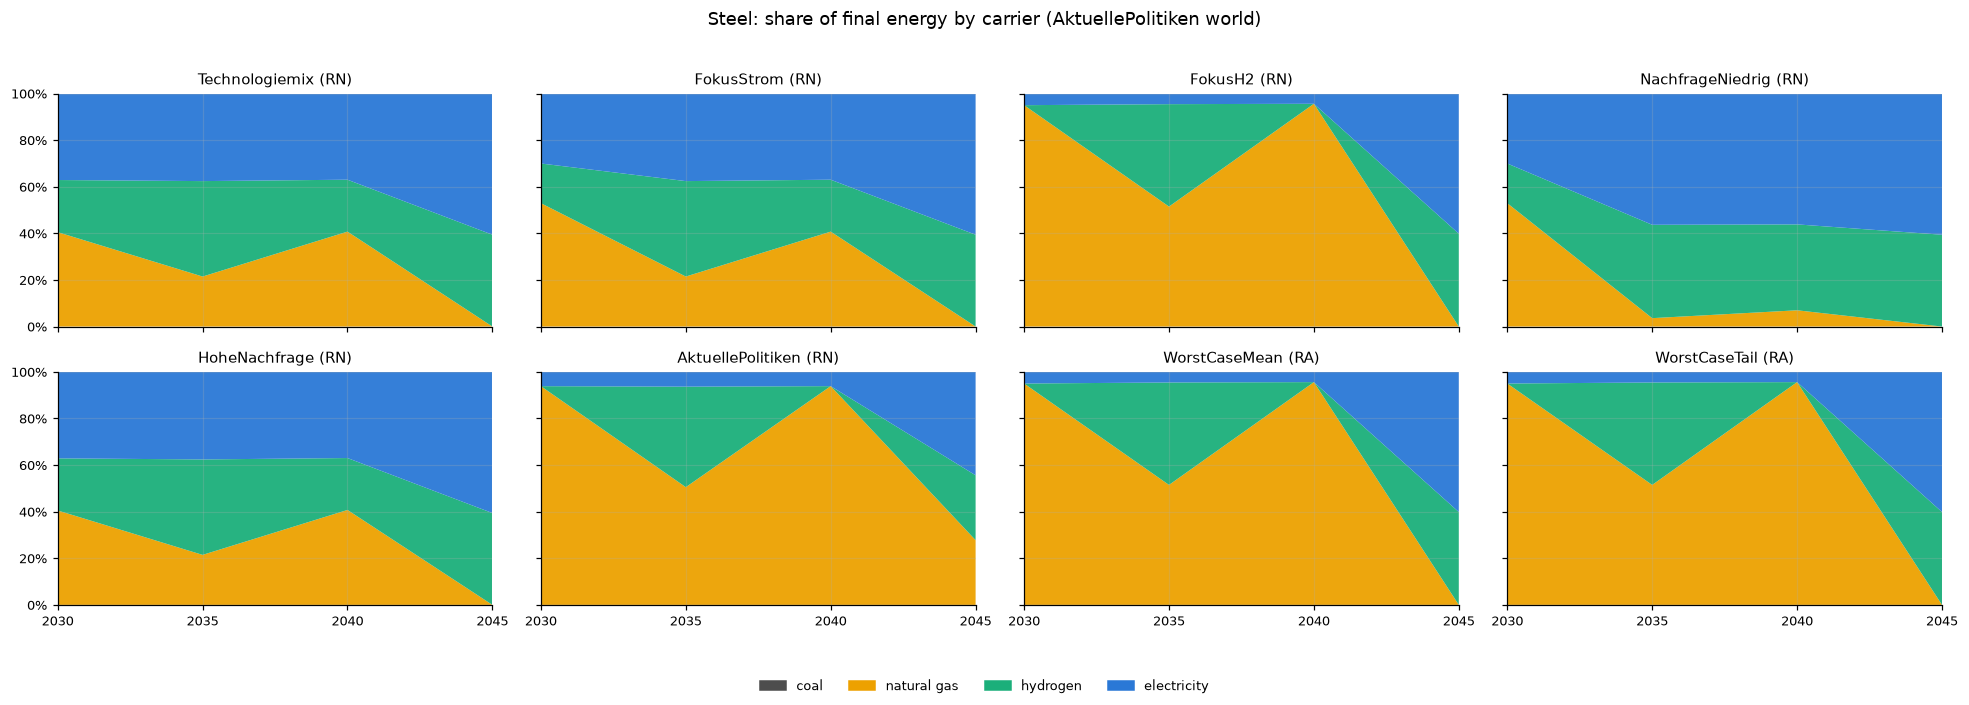

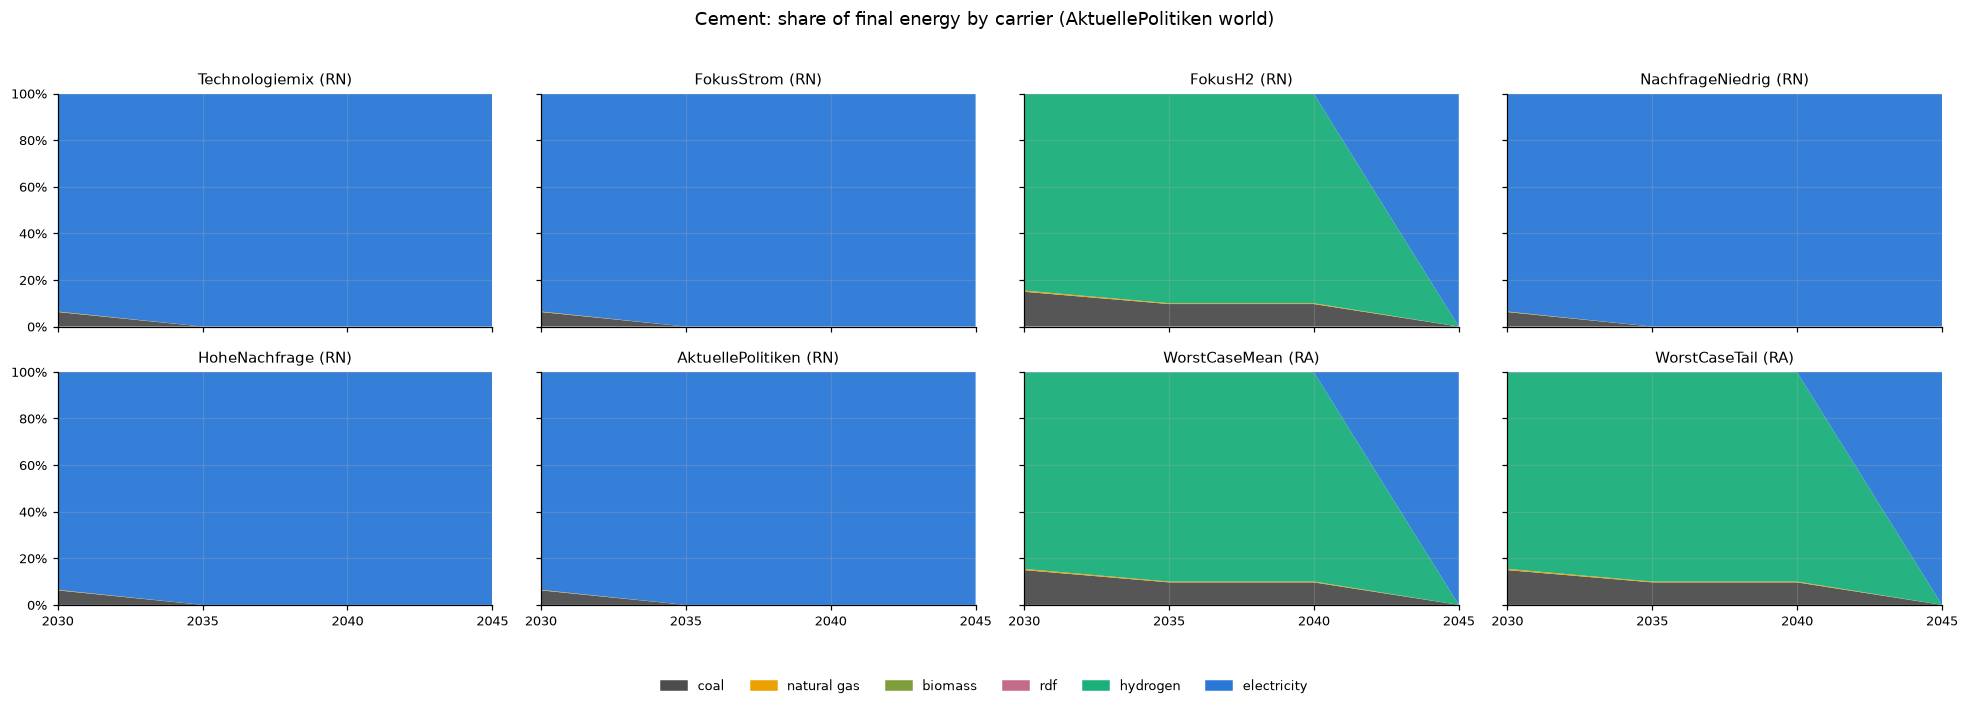

In [34]:
def plot_energy_share_by_case(sector: str):
    d = SECTOR_TOT[(SECTOR_TOT.sector == sector) & (SECTOR_TOT.macro == REFERENCE_MACRO)]
    carriers = [c for c in CARRIERS if d[c + "_GWh"].sum() > 1e-6]
    fig, axes = plt.subplots(2, 4, figsize=(18, 6.3), sharey=True, sharex=True)
    for ax, case in zip(axes.ravel(), CASES):
        sub = d[d.case == case].set_index("year").reindex(ANCHORS)
        en = sub[[c + "_GWh" for c in carriers]]
        share = en.div(en.sum(axis=1), axis=0).fillna(0.0)
        ax.stackplot(share.index, share.T.to_numpy(), colors=[CARRIER_COLOR[c] for c in carriers], alpha=0.95)
        ax.set_title(CASE_SHORT[case], fontsize=10)
        ax.set_xlim(ANCHORS[0], ANCHORS[-1]); ax.set_ylim(0, 1)
        ax.set_xticks(ANCHORS)
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    handles = [plt.matplotlib.patches.Patch(color=CARRIER_COLOR[c], label=c.replace("_", " ")) for c in carriers]
    fig.legend(handles=handles, loc="lower center", ncol=len(carriers), fontsize=8.5, frameon=False)
    fig.suptitle(f"{SECTORS[sector]['title']}: share of final energy by carrier ({MACRO_TITLE[REFERENCE_MACRO]} world)", y=0.995)
    fig.tight_layout(rect=(0, 0.08, 1, 0.98))
    plt.show()


for s in SECTORS:
    plot_energy_share_by_case(s)

### 7.4 What is inside each configuration: fuel share per technology

The same energy accounting, but per technology instead of per case. This is the structural reason why a technology behaves as it does under a given price scenario: its share of electricity, hydrogen, gas and coal. Intensities are per tonne of product, in the reference world and in 2040.

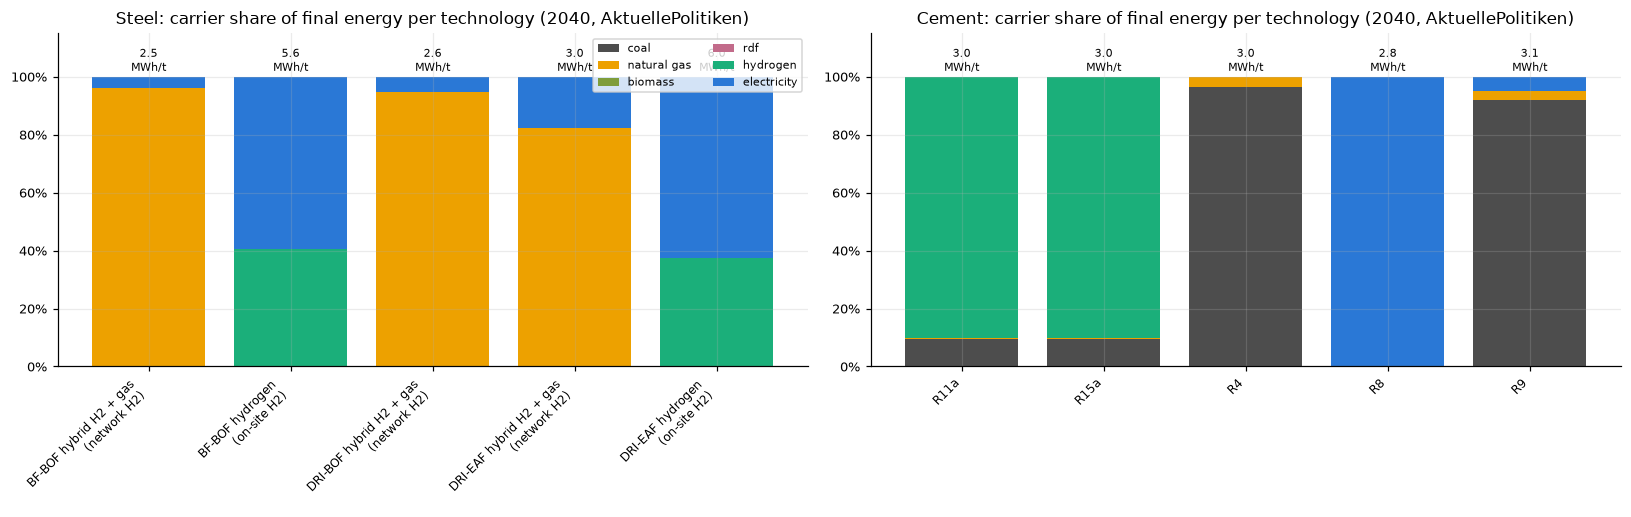

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
for ax, sector in zip(axes, SECTORS):
    ue = unit_economics(sector, REFERENCE_MACRO, 2040).loc[sorted(USED[sector])]
    en = ue[[c + "_MWh_per_t" for c in CARRIERS]]
    share = en.div(en.sum(axis=1), axis=0)
    bottom = np.zeros(len(share))
    for car in CARRIERS:
        ax.bar(range(len(share)), share[car + "_MWh_per_t"], bottom=bottom, color=CARRIER_COLOR[car], label=car.replace("_", " "))
        bottom += share[car + "_MWh_per_t"].to_numpy()
    for i, (t, row) in enumerate(en.sum(axis=1).items()):
        ax.text(i, 1.02, f"{row:.1f}\nMWh/t", ha="center", fontsize=7.5)
    ax.set_xticks(range(len(share)), [tech_label(sector, t).replace(" (", "\n(") for t in share.index], rotation=45, ha="right", fontsize=8)
    ax.set_ylim(0, 1.15)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_title(f"{SECTORS[sector]['title']}: carrier share of final energy per technology (2040, {MACRO_TITLE[REFERENCE_MACRO]})")
axes[0].legend(loc="upper right", fontsize=7, ncol=2)
fig.tight_layout()
plt.show()

### 7.5 CO2 emissions

Left: CO2 per case in the reference world. The shaded band spans the six macro scenarios, so its width is the sensitivity of the outcome to the world that actually materialises. Right: CO2 by technology for each case in 2030 and 2045, which shows which technologies carry the emissions.

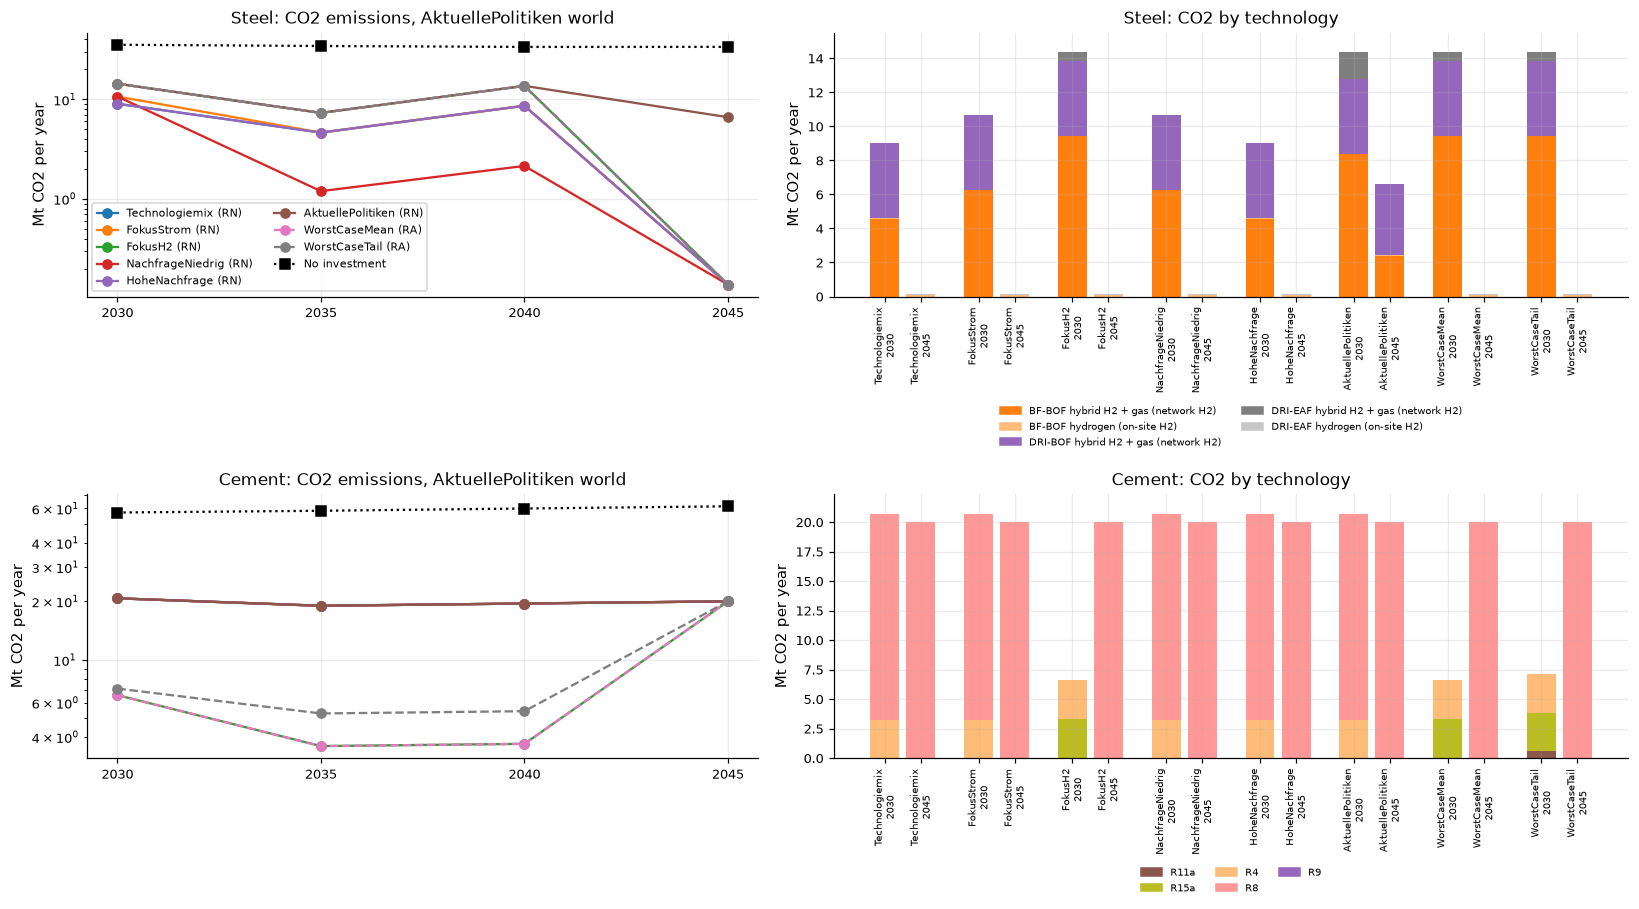

reference world       max over 6 worlds        \
year                                     2030  2045              2030  2045   
sector case                                                                   
cement AktuellePolitiken (RN)           20.69 19.97             20.69 19.97   
       FokusH2 (RN)                      6.58 19.97              6.58 19.97   
       FokusStrom (RN)                  20.69 19.97             20.69 19.97   
       HoheNachfrage (RN)               20.69 19.97             20.69 19.97   
       NachfrageNiedrig (RN)            20.69 19.97             20.69 19.97   
       No investment                    57.12 61.48             57.12 71.78   
       Technologiemix (RN)              20.69 19.97             20.69 19.97   
       WorstCaseMean (RA)                6.58 19.97              6.58 19.97   
       WorstCaseTail (RA)                7.11 19.97              7.11 19.97   
steel  AktuellePolitiken (RN)           14.35  6.62             14.35  6.62   
       FokusH2 (RN)                     14.35  0.14             14.35  0.16   
       FokusStrom (RN)                  10.68  0.14             10.68  0.16   
       HoheNachfrage (RN)                9.03  0.14              9.03  0.16   
       NachfrageNiedrig (RN)            10.68  0.14             10.68  0.16   
       No investment                    35.31 33.62             35.98 39.41   
       Technologiemix (RN)               9.03  0.14              9.03  0.16   
       WorstCaseMean (RA)               14.35  0.14             14.35  0.16   
       WorstCaseTail (RA)               14.35  0.14             14.35  0.16   

                              min over 6 worlds        
year                                       2030  2045  
sector case                                            
cement AktuellePolitiken (RN)              2.07  1.72  
       FokusH2 (RN)                        3.64  1.72  
       FokusStrom (RN)                     2.07  1.72  
       HoheNachfrage (RN)                  2.07  1.72  
       NachfrageNiedrig (RN)               2.07  1.72  
       No investment                      57.12 53.07  
       Technologiemix (RN)                 2.07  1.72  
       WorstCaseMean (RA)                  3.64  1.72  
       WorstCaseTail (RA)                  3.60  1.72  
steel  AktuellePolitiken (RN)              0.19  0.12  
       FokusH2 (RN)                        0.19  0.12  
       FokusStrom (RN)                     0.19  0.12  
       HoheNachfrage (RN)                  0.18  0.12  
       NachfrageNiedrig (RN)               0.19  0.12  
       No investment                      35.31 29.72  
       Technologiemix (RN)                 0.18  0.12  
       WorstCaseMean (RA)                  0.19  0.12  
       WorstCaseTail (RA)                  0.19  0.12

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8.6), gridspec_kw={"width_ratios": [1.1, 1.3]})
case_color = dict(zip(CASES, plt.get_cmap("tab10").colors))
for row, sector in enumerate(SECTORS):
    ax = axes[row, 0]
    d = SECTOR_TOT[SECTOR_TOT.sector == sector]
    for case in CASES:
        ref = d[(d.case == case) & (d.macro == REFERENCE_MACRO)].sort_values("year")
        ax.plot(ref.year, ref.co2_Mt, marker="o", color=case_color[case], label=CASE_SHORT[case],
                linestyle="--" if case.endswith("risk_averse") else "-")
    base = d[(d.case == NOINV) & (d.macro == REFERENCE_MACRO)].sort_values("year")
    ax.plot(base.year, base.co2_Mt, color="black", linestyle=":", marker="s", label="No investment")
    ax.set_title(f"{SECTORS[sector]['title']}: CO2 emissions, {MACRO_TITLE[REFERENCE_MACRO]} world")
    ax.set_ylabel("Mt CO2 per year"); ax.set_xticks(ANCHORS)
    ax.set_yscale("log")
    if row == 0:
        ax.legend(fontsize=7, ncol=2)
    ax = axes[row, 1]
    sub = CHAIN[(CHAIN.sector == sector) & (CHAIN.macro == REFERENCE_MACRO) & CHAIN.year.isin([2030, 2045])]
    g = sub.groupby(["case", "year", "technology"])["co2_Mt"].sum().reset_index()
    techs = sorted(USED[sector])
    xpos, ticks, labels = 0, [], []
    for case in CASES:
        for year in (2030, 2045):
            part = g[(g.case == case) & (g.year == year)].set_index("technology")["co2_Mt"].reindex(techs).fillna(0)
            bottom = 0.0
            for t in techs:
                ax.bar(xpos, part[t], bottom=bottom, color=TECH_COLOR[(sector, t)], width=0.8)
                bottom += part[t]
            ticks.append(xpos); labels.append(f"{CASE_SHORT[case].split(' ')[0]}\n{year}")
            xpos += 1
        xpos += 0.6
    ax.set_xticks(ticks, labels, fontsize=6.5, rotation=90)
    ax.set_ylabel("Mt CO2 per year")
    ax.set_ylim(0, ax.get_ylim()[1] * 1.08)
    ax.set_title(f"{SECTORS[sector]['title']}: CO2 by technology")
    handles = [plt.matplotlib.patches.Patch(color=TECH_COLOR[(sector, t)], label=tech_label(sector, t)) for t in techs]
    ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.38), ncol=2 if sector == "steel" else 3, fontsize=6.8, frameon=False)
fig.tight_layout()
fig.subplots_adjust(hspace=0.75)
plt.show()

band = (SECTOR_TOT.groupby(["sector", "case", "year"])["co2_Mt"].agg(["min", "max"]).reset_index())
ref = SECTOR_TOT[SECTOR_TOT.macro == REFERENCE_MACRO][["sector", "case", "year", "co2_Mt"]]
co2_tab = ref.merge(band, on=["sector", "case", "year"])
co2_tab["case"] = co2_tab["case"].map(CASE_SHORT)
display(co2_tab[co2_tab.year.isin([2030, 2045])].pivot_table(index=["sector", "case"], columns="year",
        values=["co2_Mt", "min", "max"]).round(2).rename(columns={"co2_Mt": "reference world", "min": "min over 6 worlds", "max": "max over 6 worlds"}))

### 7.5b Decarbonisation, one panel per case

The same CO2 trajectory as the left panel of section 5.4, but one case per panel against its own no-investment baseline (dashed), so the vertical gap between the two lines in a panel is that case's abatement, and the gap between panels is how much abatement differs by case. Linear scale, shared axis.

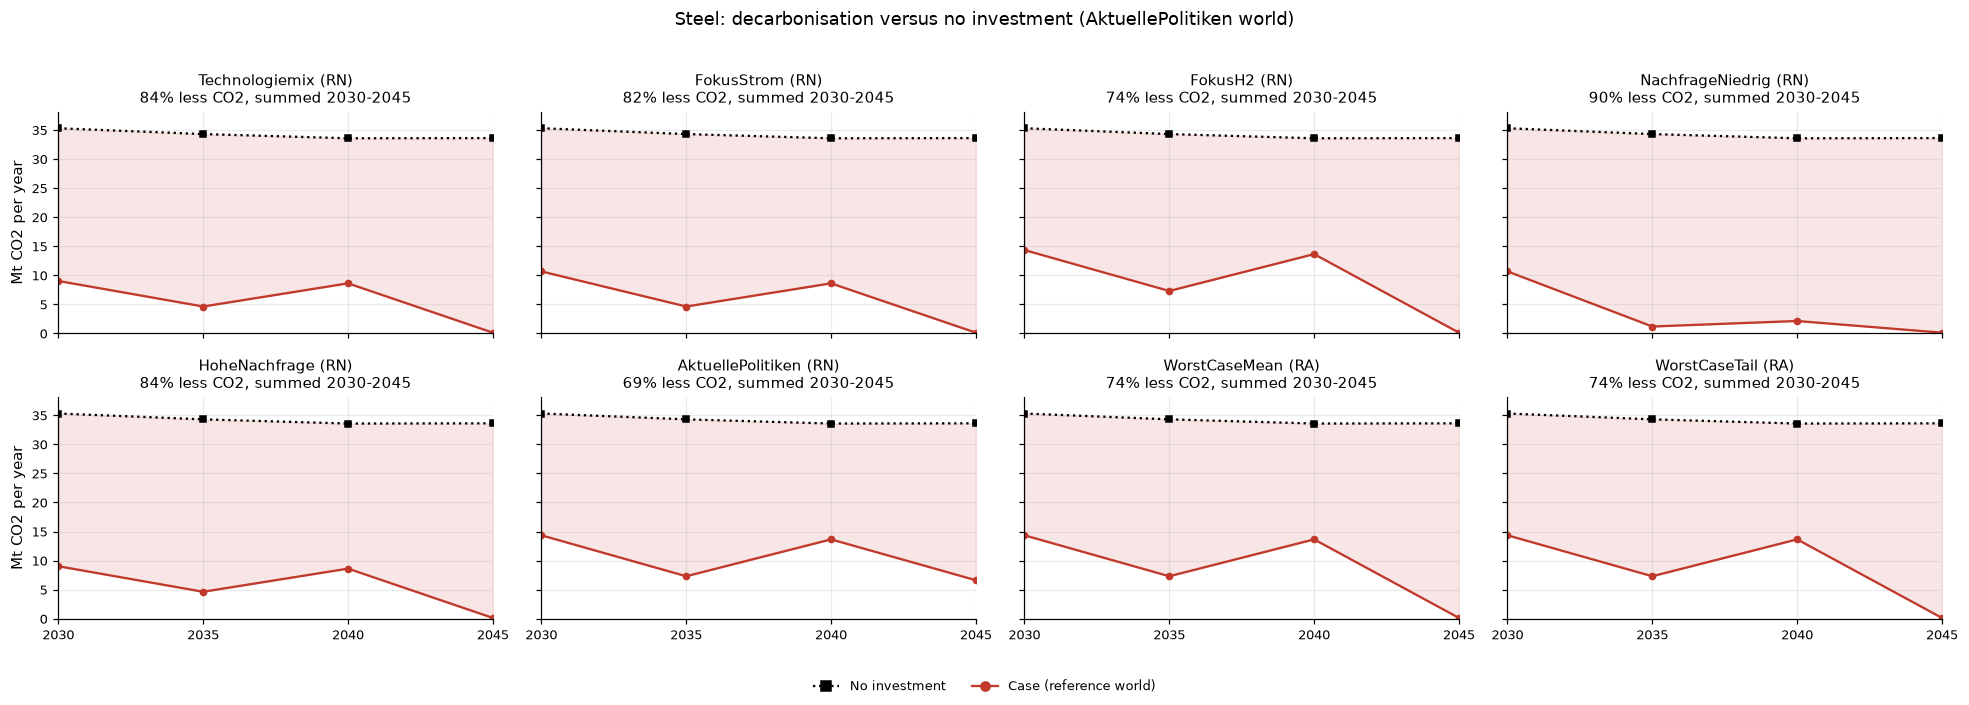

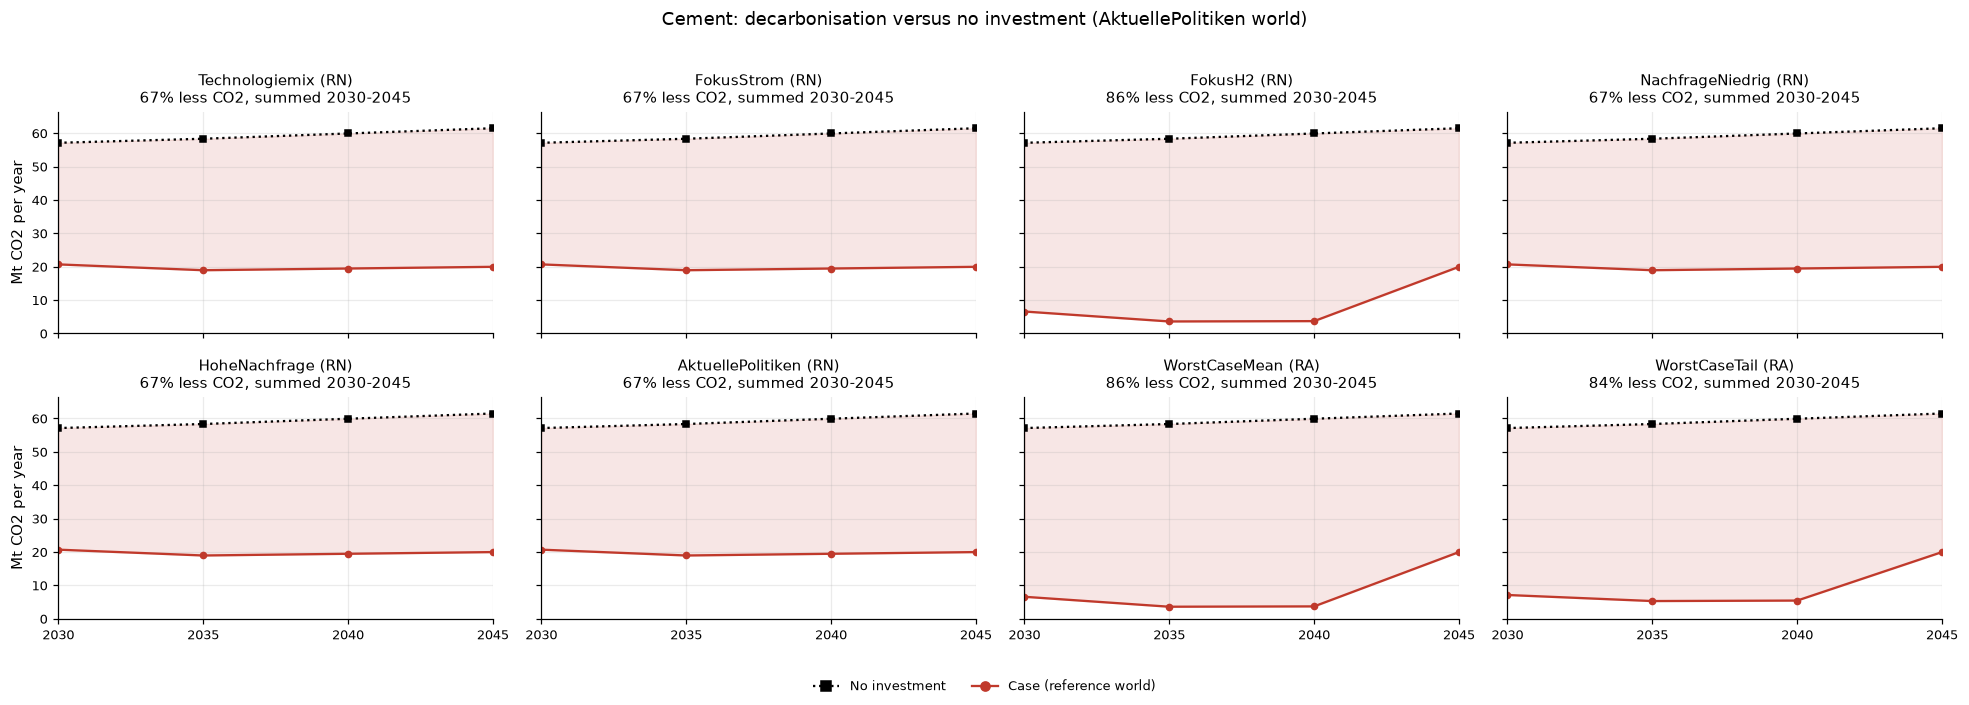

In [37]:
def plot_co2_by_case(sector: str):
    d = SECTOR_TOT[(SECTOR_TOT.sector == sector) & (SECTOR_TOT.macro == REFERENCE_MACRO)]
    base = d[d.case == NOINV].set_index("year").reindex(ANCHORS)["co2_Mt"]
    ymax = max(base.max(), d[d.case != NOINV].co2_Mt.max()) * 1.08
    fig, axes = plt.subplots(2, 4, figsize=(18, 6.3), sharey=True, sharex=True)
    for ax, case in zip(axes.ravel(), CASES):
        sub = d[d.case == case].set_index("year").reindex(ANCHORS)["co2_Mt"]
        ax.plot(ANCHORS, base.to_numpy(), color="black", linestyle=":", marker="s", markersize=4, label="No investment")
        ax.fill_between(ANCHORS, sub.to_numpy(), base.to_numpy(), color="#c0392b", alpha=0.12)
        ax.plot(ANCHORS, sub.to_numpy(), color="#c0392b", marker="o", markersize=4, label=CASE_SHORT[case])
        abated = (base.sum() - sub.sum()) / base.sum()
        ax.set_title(f"{CASE_SHORT[case]}\n{abated:.0%} less CO2, summed 2030-2045", fontsize=9.5)
        ax.set_xlim(ANCHORS[0], ANCHORS[-1]); ax.set_ylim(0, ymax)
        ax.set_xticks(ANCHORS)
    axes[0, 0].set_ylabel("Mt CO2 per year")
    axes[1, 0].set_ylabel("Mt CO2 per year")
    handles = [plt.Line2D([0], [0], color="black", linestyle=":", marker="s", label="No investment"),
              plt.Line2D([0], [0], color="#c0392b", marker="o", label="Case (reference world)")]
    fig.legend(handles=handles, loc="lower center", ncol=2, fontsize=8.5, frameon=False)
    fig.suptitle(f"{SECTORS[sector]['title']}: decarbonisation versus no investment ({MACRO_TITLE[REFERENCE_MACRO]} world)", y=0.995)
    fig.tight_layout(rect=(0, 0.06, 1, 0.98))
    plt.show()


for s in SECTORS:
    plot_co2_by_case(s)

### 7.6 Cumulative CO2 and the cost of abatement

AURIS decides on money, not on emissions. The table puts both on one page: for each case, annual CO2 summed over 2030 to 2049, where each anchor year stands for the five years starting with it, and the NPV of the 2025 decisions from section 6.4. Differences in NPV divided by differences in CO2 give an implicit abatement cost between cases.

In [38]:
cum = (SECTOR_TOT[(SECTOR_TOT.macro == REFERENCE_MACRO) & (SECTOR_TOT.case != NOINV)]
       .assign(w=lambda d: d.year.map({2030: 5, 2035: 5, 2040: 5, 2045: 5}))
       .assign(co2_cum=lambda d: d.co2_Mt * d.w)
       .groupby(["sector", "case"])["co2_cum"].sum().rename("cumulative CO2 2030-2049 (Mt)"))
tab = ROBUST.copy()
tab["case_id"] = [c for _ in SECTORS for c in CASES]
tab = tab.merge(cum.reset_index().rename(columns={"case": "case_id"}), on=["sector", "case_id"])
ref_row = tab[tab.case_id == "AktuellePolitiken_risk_neutral"].set_index("sector")
tab["abatement vs AktuellePolitiken (Mt)"] = tab["sector"].map(ref_row["cumulative CO2 2030-2049 (Mt)"]) - tab["cumulative CO2 2030-2049 (Mt)"]
display(tab[["sector", "case", "mean over beliefs (EUR bn)", "worst belief (EUR bn)",
             "cumulative CO2 2030-2049 (Mt)", "abatement vs AktuellePolitiken (Mt)"]].style.hide(axis="index")
        .format({"mean over beliefs (EUR bn)": "{:,.1f}", "worst belief (EUR bn)": "{:,.1f}",
                 "cumulative CO2 2030-2049 (Mt)": "{:,.1f}", "abatement vs AktuellePolitiken (Mt)": "{:,.1f}"}))

sector,case,mean over beliefs (EUR bn),worst belief (EUR bn),cumulative CO2 2030-2049 (Mt),abatement vs AktuellePolitiken (Mt)
steel,Technologiemix (RN),73.2,39.9,112.2,97.5
steel,FokusStrom (RN),76.3,57.9,120.4,89.3
steel,FokusH2 (RN),78.5,73.0,177.3,32.4
steel,NachfrageNiedrig (RN),76.3,57.9,70.8,138.9
steel,HoheNachfrage (RN),73.2,39.9,112.2,97.5
steel,AktuellePolitiken (RN),78.5,73.0,209.7,0.0
steel,WorstCaseMean (RA),78.5,73.0,177.3,32.4
steel,WorstCaseTail (RA),78.5,73.0,177.3,32.4
cement,Technologiemix (RN),-39.0,-143.5,395.4,0.0
cement,FokusStrom (RN),-39.0,-143.5,395.4,0.0


**Key findings: physical consequences (reference world AktuellePolitiken, the current reference)**

* **Scale of the change is still large, but the CO2 reduction is much smaller than under Technologiemix.** Without investment the steel plants would emit about 35 Mt CO2 per year in 2030 (falling slowly to 34 Mt by 2045 as the baseline technology ages) and the cement plants about 57 Mt, rising to 61 Mt. With the AURIS pathways, steel emits 9.0 to 14.4 Mt in 2030 and 0.1 to 6.6 Mt in 2045 (74 to 100 percent reduction depending on the case); cement emits 6.6 to 20.7 Mt in 2030 and a uniform 20.0 Mt in 2045 for every case (64 to 88 percent reduction in 2030, converging to about 65 percent by 2045). Under the Technologiemix reference the same pathways reduced emissions by about 99 percent (steel) and 94 to 96 percent (cement); AktuellePolitiken is a materially worse decarbonisation outcome for the identical technology choices, because none of them is rewarded for lowering CO2 in a world with no carbon price.
* **Steel electricity and hydrogen now depend on which world the case bet on, not only on which cluster it belongs to.** The Technologiemix/FokusStrom/HoheNachfrage/NachfrageNiedrig cluster still reaches 95.9 TWh of electricity and 62.4 TWh of hydrogen by 2045, unchanged from the Technologiemix reference (these pathways end on the on-site electrolyser route, which does not depend on the carbon price to make hydrogen). The FokusH2/risk-averse cluster reaches the same 94.2 TWh/62.4 TWh by 2045. AktuellePolitiken's own case is the exception: because its hybrid network-hydrogen route burns natural gas rather than hydrogen when it is actually realised in the AktuellePolitiken price world (section 5.1), its 2045 result is only 51.8 TWh of electricity and 32.5 TWh of hydrogen, with 6.6 Mt of CO2 still being emitted in 2045 while every other case is down to 0.1 Mt. Betting correctly on your own world and being simulated in it are not the same thing as abandoning fossil fuel.
* **Cement fuel mix.** The R8 cases (five risk-neutral cases) use 92.3 TWh of electricity in 2030 and 105.8 TWh in 2045, no hydrogen. The hydrogen-first cases (FokusH2 and both risk-averse cases) use 88.5 TWh of hydrogen and 0.2 TWh of electricity in 2030, then converge to the same 105.8 TWh of electricity by 2045 once they switch to R8. Despite converging on the same technology and the same electricity demand, CO2 does not converge to a low number: all cases reach about 20.0 Mt in 2045, because without a carbon price neither R8's cryogenic capture nor the earlier hydrogen routes' capture is run and the calcination process CO2 of clinker-making is never captured.
* **The headline risk flagged under the Technologiemix reference is now the baseline.** The earlier version of this notebook reported, as a caveat, that "without a carbon price (AktuellePolitiken) the electrified cement route emits about 19 Mt instead of about 2 Mt." With AktuellePolitiken now the reference world, that 20.0 Mt figure (close to the earlier estimate) is what every chart above shows directly, not a footnote.

## 8. The electricity-market interface at 15-minute resolution

**Question.** How is each case's electricity demand spread over the year and over the day, and which prices does it meet?

The files in `data/output/auris_inputs_15min/` hold, per case and macro scenario, the day-ahead demand, the day-ahead clearing price, the aFRR negative energy and its prices of every plant in every 15-minute step of 2030, 2035, 2040 and 2045. They are the direct input of the electricity-market model. Here they are aggregated to sector level, once, and cached in `data/output/auris_chain_cache/`.

*Definitions.* **Demand** is day-ahead position plus activated aFRR energy. The **demand-weighted price** is the average day-ahead price paid per MWh actually bought, the **time-average price** is the plain average over all steps; their ratio (*price capture ratio*) shows whether a technology buys cheaper (below 1) or dearer (above 1) than the market average.

In [39]:
import pyarrow as pa

PROFILE_DIR = FLEX / "data" / "output" / "auris_inputs_15min"
PCOLS = ["year", "plant_id", "active_technology_id", "datetime", "da_electricity_MWh",
         "da_bid_price_EUR_per_MWh", "afrr_neg_energy_MWh"]


def aggregate_profile(path: Path, sector: str):
    case, macro = path.name.replace(".csv.zst", "").split("__")
    with pa.input_stream(str(path), compression="zstd") as stream:
        t = pacsv.read_csv(stream, convert_options=pacsv.ConvertOptions(include_columns=PCOLS))
    df = t.to_pandas()
    df["demand"] = df["da_electricity_MWh"] + df["afrr_neg_energy_MWh"]
    df["da_x"] = df["da_electricity_MWh"] * df["da_bid_price_EUR_per_MWh"]
    ts = df.groupby(["year", "datetime"], as_index=False).agg(
        demand=("demand", "sum"), da=("da_electricity_MWh", "sum"), afrr=("afrr_neg_energy_MWh", "sum"),
        price=("da_bid_price_EUR_per_MWh", "mean"))
    ts["month"], ts["hour"] = ts["datetime"].dt.month, ts["datetime"].dt.hour
    tag = {"sector": sector, "case": case, "macro": macro}
    monthly = ts.groupby(["year", "month"], as_index=False).agg(da=("da", "sum"), afrr=("afrr", "sum"), price=("price", "mean"))
    hourly = ts.groupby(["year", "hour"], as_index=False).agg(demand_MW=("demand", lambda s: s.mean() * 4), price=("price", "mean"))
    summ = ts.groupby("year", as_index=False).agg(
        da_MWh=("da", "sum"), afrr_MWh=("afrr", "sum"), peak_MW=("demand", lambda s: s.max() * 4),
        mean_MW=("demand", lambda s: s.mean() * 4), mean_price=("price", "mean"))
    wp = df.groupby("year").agg(da_x=("da_x", "sum"), da=("da_electricity_MWh", "sum")).reset_index()
    summ = summ.merge(wp[["year"]].assign(wavg_price=wp.da_x / wp.da.replace(0, np.nan)), on="year")
    tech = df.groupby(["year", "active_technology_id"], as_index=False).agg(
        da_MWh=("da_electricity_MWh", "sum"), da_x=("da_x", "sum"), afrr_MWh=("afrr_neg_energy_MWh", "sum"))
    return tuple(x.assign(**tag) for x in (monthly, hourly, summ, tech))


def load_profiles() -> dict[str, pd.DataFrame]:
    names = ["monthly", "hourly", "summary", "tech"]
    files = {n: CACHE / f"profiles_{n}.parquet" for n in names}
    if all(f.exists() for f in files.values()):
        return {n: pd.read_parquet(f) for n, f in files.items()}
    jobs = [(p, s) for s in SECTORS for p in sorted((PROFILE_DIR / s).glob("*.csv.zst"))]
    print(f"aggregating {len(jobs)} 15-minute files (first run only)")
    with ThreadPoolExecutor(8) as pool:
        results = list(pool.map(lambda a: aggregate_profile(*a), jobs))
    out = {n: pd.concat([r[i] for r in results], ignore_index=True) for i, n in enumerate(names)}
    for n, f in files.items():
        out[n].to_parquet(f)
    return out


PROF = load_profiles()
PROF["summary"]["demand_GWh"] = (PROF["summary"].da_MWh + PROF["summary"].afrr_MWh) / 1e3
print({k: v.shape for k, v in PROF.items()})

{'monthly': (4608, 8), 'hourly': (9216, 7), 'summary': (384, 11), 'tech': (822, 8)}


### 8.1 Annual electricity demand

Left: demand in the reference world per case; the band is the range over the six macro scenarios. Right: split between day-ahead procurement and activated aFRR energy in 2040.

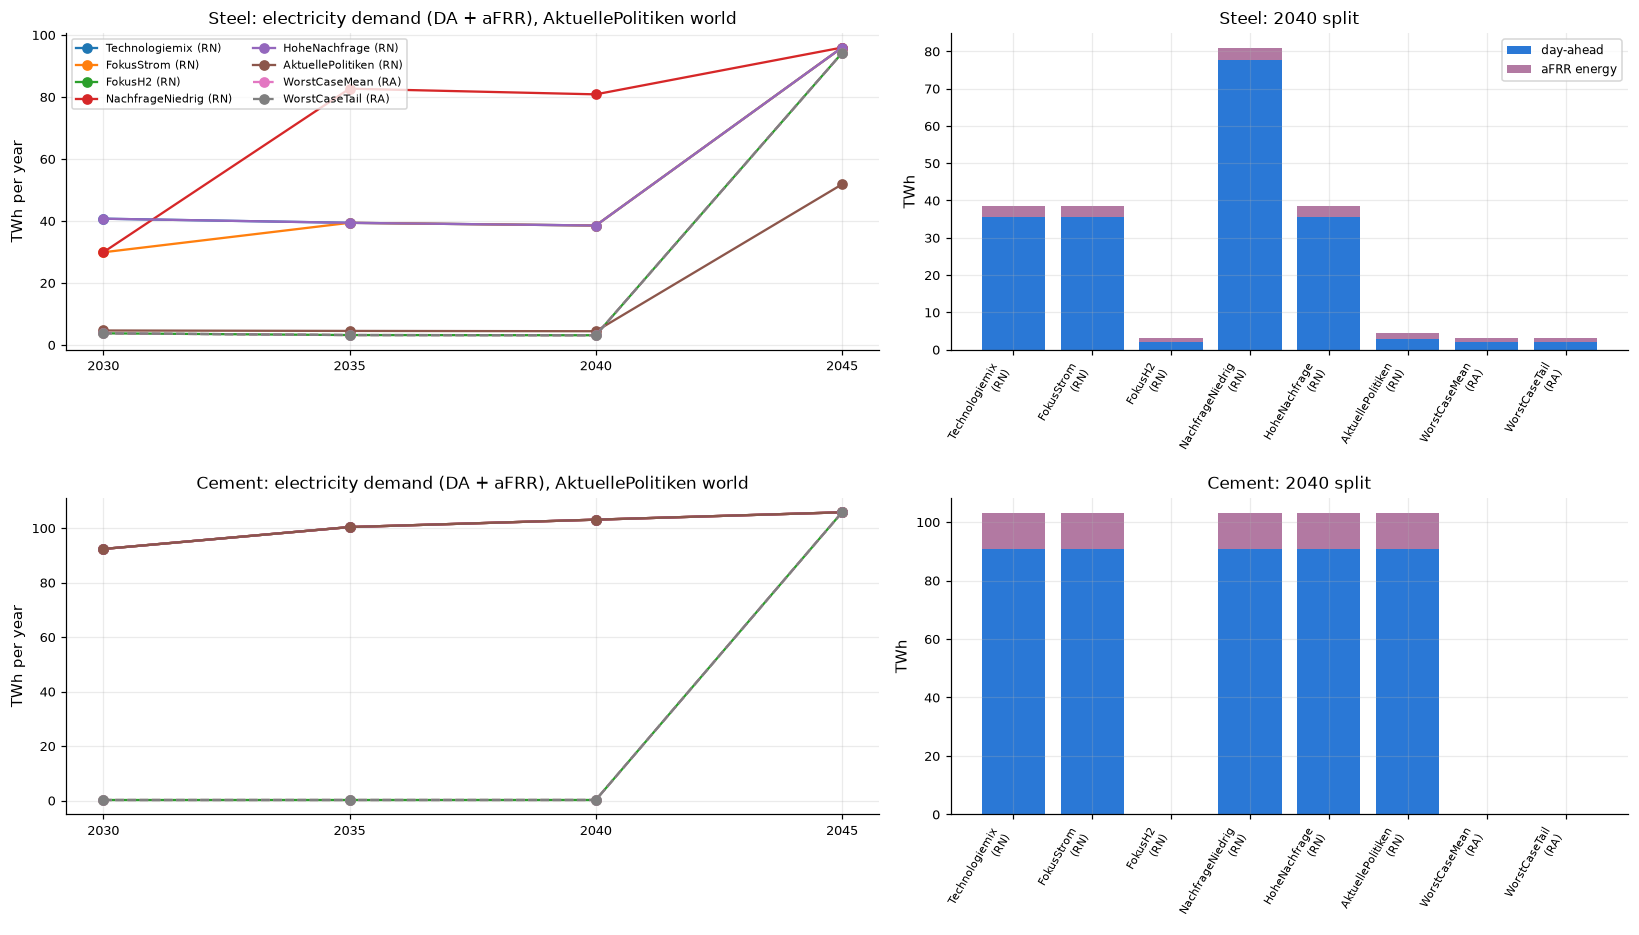

min over worlds (TWh)  max over worlds (TWh)  \
sector case                                                                   
cement AktuellePolitiken (RN)                  95.48                 116.70   
       FokusH2 (RN)                             0.18                   0.22   
       FokusStrom (RN)                         95.48                 116.70   
       HoheNachfrage (RN)                      95.48                 116.70   
       NachfrageNiedrig (RN)                   95.48                 116.70   
       Technologiemix (RN)                     95.48                 116.70   
       WorstCaseMean (RA)                       0.18                   0.22   
       WorstCaseTail (RA)                       0.20                   0.47   
steel  AktuellePolitiken (RN)                   4.07                   5.17   
       FokusH2 (RN)                             2.87                   3.48   
       FokusStrom (RN)                         35.54                  47.91   
       HoheNachfrage (RN)                      35.54                  47.91   
       NachfrageNiedrig (RN)                   74.59                  92.94   
       Technologiemix (RN)                     35.54                  47.91   
       WorstCaseMean (RA)                       2.87                   3.48   
       WorstCaseTail (RA)                       2.87                   3.48   

                               range (TWh)  
sector case                                 
cement AktuellePolitiken (RN)        21.22  
       FokusH2 (RN)                   0.04  
       FokusStrom (RN)               21.22  
       HoheNachfrage (RN)            21.22  
       NachfrageNiedrig (RN)         21.22  
       Technologiemix (RN)           21.22  
       WorstCaseMean (RA)             0.04  
       WorstCaseTail (RA)             0.27  
steel  AktuellePolitiken (RN)         1.10  
       FokusH2 (RN)                   0.61  
       FokusStrom (RN)               12.37  
       HoheNachfrage (RN)            12.37  
       NachfrageNiedrig (RN)         18.35  
       Technologiemix (RN)           12.37  
       WorstCaseMean (RA)             0.61  
       WorstCaseTail (RA)             0.61

In [40]:
S = PROF["summary"]
fig, axes = plt.subplots(2, 2, figsize=(15, 8.6), gridspec_kw={"width_ratios": [1.2, 1]})
for row, sector in enumerate(SECTORS):
    ax = axes[row, 0]
    d = S[S.sector == sector]
    for case in CASES:
        ref = d[(d.case == case) & (d.macro == REFERENCE_MACRO)].sort_values("year")
        ax.plot(ref.year, ref.demand_GWh / 1e3, marker="o", color=case_color[case], label=CASE_SHORT[case],
                linestyle="--" if case.endswith("risk_averse") else "-")
    ax.set_xticks(ANCHORS); ax.set_ylabel("TWh per year")
    ax.set_title(f"{SECTORS[sector]['title']}: electricity demand (DA + aFRR), {MACRO_TITLE[REFERENCE_MACRO]} world")
    if row == 0:
        ax.legend(fontsize=7, ncol=2)
    ax = axes[row, 1]
    s40 = d[(d.macro == REFERENCE_MACRO) & (d.year == 2040)].set_index("case").loc[CASES]
    ax.bar(range(8), s40.da_MWh / 1e6, color="#2a78d6", label="day-ahead")
    ax.bar(range(8), s40.afrr_MWh / 1e6, bottom=s40.da_MWh / 1e6, color="#b279a2", label="aFRR energy")
    ax.set_xticks(range(8), [CASE_SHORT[c].replace(" (", "\n(") for c in CASES], rotation=60, ha="right", fontsize=7.5)
    ax.set_ylabel("TWh"); ax.set_title(f"{SECTORS[sector]['title']}: 2040 split")
    if row == 0:
        ax.legend()
fig.tight_layout()
plt.show()

spread = (S.assign(demand_TWh=S.demand_GWh / 1e3).groupby(["sector", "case", "year"])["demand_TWh"].agg(["min", "max"]).reset_index())
spread["range (TWh)"] = spread["max"] - spread["min"]
display(spread[spread.year == 2040].assign(case=lambda d: d.case.map(CASE_SHORT)).set_index(["sector", "case"])
        [["min", "max", "range (TWh)"]].round(2).rename(columns={"min": "min over worlds (TWh)", "max": "max over worlds (TWh)"}))

### 8.2 Seasonal and daily shape

Seasonal: each case's monthly demand as a share of its annual demand (lines) against the monthly mean day-ahead price (bars, right axis). Daily: mean power by hour of day. Both for 2040 in the reference world.

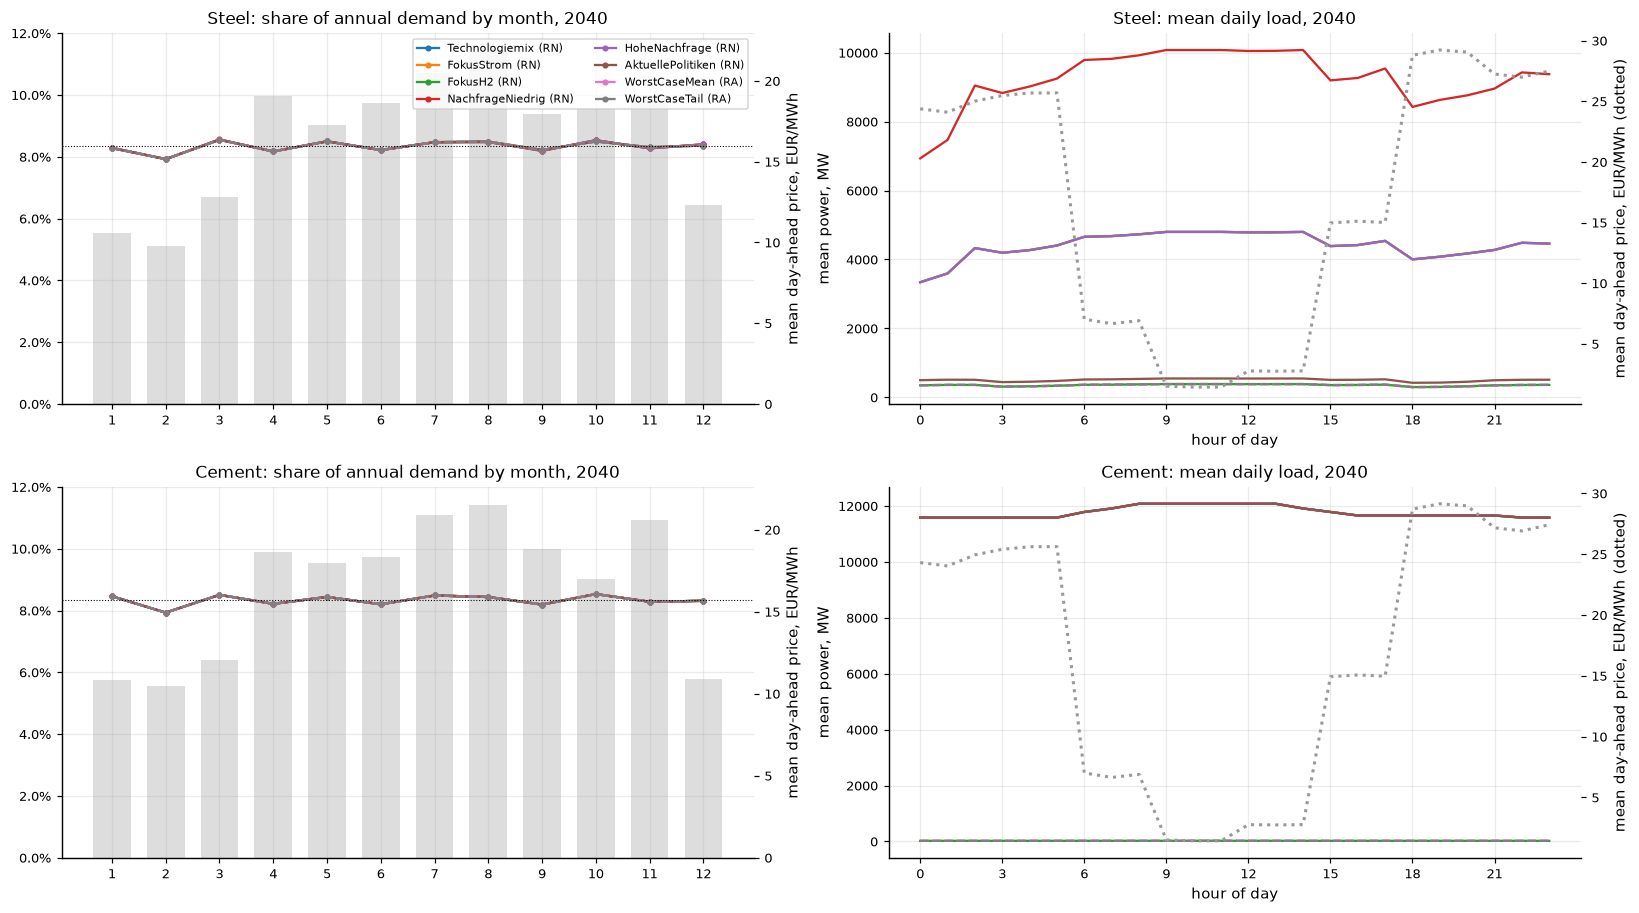

In [41]:
M, H = PROF["monthly"], PROF["hourly"]
YEAR_PROFILE = 2040
fig, axes = plt.subplots(2, 2, figsize=(15, 8.4))
months = np.arange(1, 13)
for row, sector in enumerate(SECTORS):
    ax = axes[row, 0]
    m = M[(M.sector == sector) & (M.macro == REFERENCE_MACRO) & (M.year == YEAR_PROFILE)]
    price = m[m.case == CASES[0]].set_index("month")["price"].reindex(months)
    ax2 = ax.twinx()
    ax2.bar(months, price, color="#dddddd", zorder=0, width=0.7)
    ax2.set_ylabel("mean day-ahead price, EUR/MWh"); ax2.grid(False)
    ax.set_zorder(ax2.get_zorder() + 1); ax.patch.set_visible(False)
    for case in CASES:
        c = m[m.case == case].set_index("month").reindex(months)
        share = (c.da + c.afrr) / (c.da + c.afrr).sum()
        ax.plot(months, share, marker="o", ms=3, color=case_color[case], label=CASE_SHORT[case],
                linestyle="--" if case.endswith("risk_averse") else "-")
    ax.axhline(1 / 12, color="black", linewidth=0.7, linestyle=":")
    ax.set_ylim(0, 0.12)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0)); ax.set_xticks(months)
    ax.set_title(f"{SECTORS[sector]['title']}: share of annual demand by month, {YEAR_PROFILE}")
    if row == 0:
        ax.legend(fontsize=7, ncol=2)
    ax = axes[row, 1]
    h = H[(H.sector == sector) & (H.macro == REFERENCE_MACRO) & (H.year == YEAR_PROFILE)]
    ax2 = ax.twinx()
    ax2.plot(range(24), h[h.case == CASES[0]].sort_values("hour")["price"], color="#999999", linestyle=":", linewidth=2)
    ax2.set_ylabel("mean day-ahead price, EUR/MWh (dotted)"); ax2.grid(False)
    for case in CASES:
        c = h[h.case == case].sort_values("hour")
        ax.plot(c.hour, c.demand_MW, color=case_color[case], linestyle="--" if case.endswith("risk_averse") else "-",
                label=CASE_SHORT[case])
    ax.set_xticks(range(0, 24, 3)); ax.set_xlabel("hour of day"); ax.set_ylabel("mean power, MW")
    ax.set_title(f"{SECTORS[sector]['title']}: mean daily load, {YEAR_PROFILE}")
fig.tight_layout()
plt.show()

### 8.3 Timing quality: does a technology buy cheaply?

For every technology the chart compares the demand-weighted day-ahead price with the time-average price in each macro scenario (2040). A bar below the diagonal means the technology shifts its electricity to cheaper hours than the average hour.

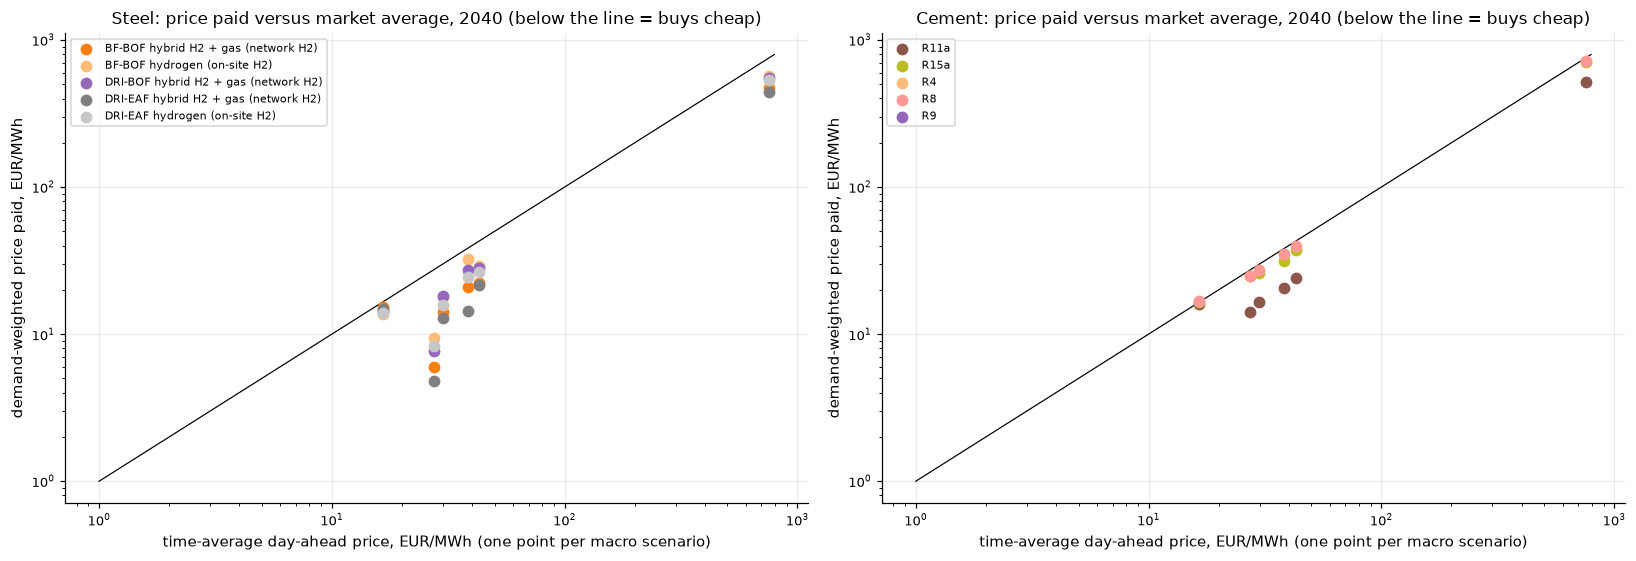

In [42]:
T = PROF["tech"]
Sm = PROF["summary"][["sector", "case", "macro", "year", "mean_price"]]
tm = (T[T.year == 2040].groupby(["sector", "macro", "active_technology_id"], as_index=False)
      .agg(da_MWh=("da_MWh", "sum"), da_x=("da_x", "sum")))
tm["wavg_price"] = tm.da_x / tm.da_MWh.replace(0, np.nan)
mp = Sm[Sm.year == 2040].groupby(["sector", "macro"], as_index=False)["mean_price"].mean()
tm = tm.merge(mp, on=["sector", "macro"])
tm["capture_ratio"] = tm.wavg_price / tm.mean_price.replace(0, np.nan)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
for ax, sector in zip(axes, SECTORS):
    sub = tm[tm.sector == sector]
    for t in sorted(USED[sector]):
        s = sub[sub.active_technology_id == t].set_index("macro").reindex(MACROS)
        ax.scatter(s.mean_price, s.wavg_price, s=45, color=TECH_COLOR[(sector, t)], label=tech_label(sector, t), zorder=3)
    lim = max(sub.mean_price.max(), sub.wavg_price.max()) * 1.05
    ax.plot([1, lim], [1, lim], color="black", linewidth=0.8)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("time-average day-ahead price, EUR/MWh (one point per macro scenario)")
    ax.set_ylabel("demand-weighted price paid, EUR/MWh")
    ax.set_title(f"{SECTORS[sector]['title']}: price paid versus market average, 2040 (below the line = buys cheap)")
    ax.legend(fontsize=7, loc="upper left")
fig.tight_layout()
plt.show()

cap_tab = (tm.assign(technology=lambda d: [tech_label(s, t) for s, t in zip(d.sector, d.active_technology_id)],
                     macro=lambda d: d.macro.map(MACRO_TITLE))
           .pivot_table(index=["sector", "technology"], columns="macro", values="capture_ratio"))
display(cap_tab.style.format("{:.2f}").set_caption("Price capture ratio by technology and macro scenario, 2040 (1 = pays the market average)"))

### 8.4 Peak power and load factor

What the grid and the market actually have to deliver: the maximum 15-minute power of each case and the load factor (mean power divided by peak power). A high peak with a low load factor means demand is concentrated in a few steps.

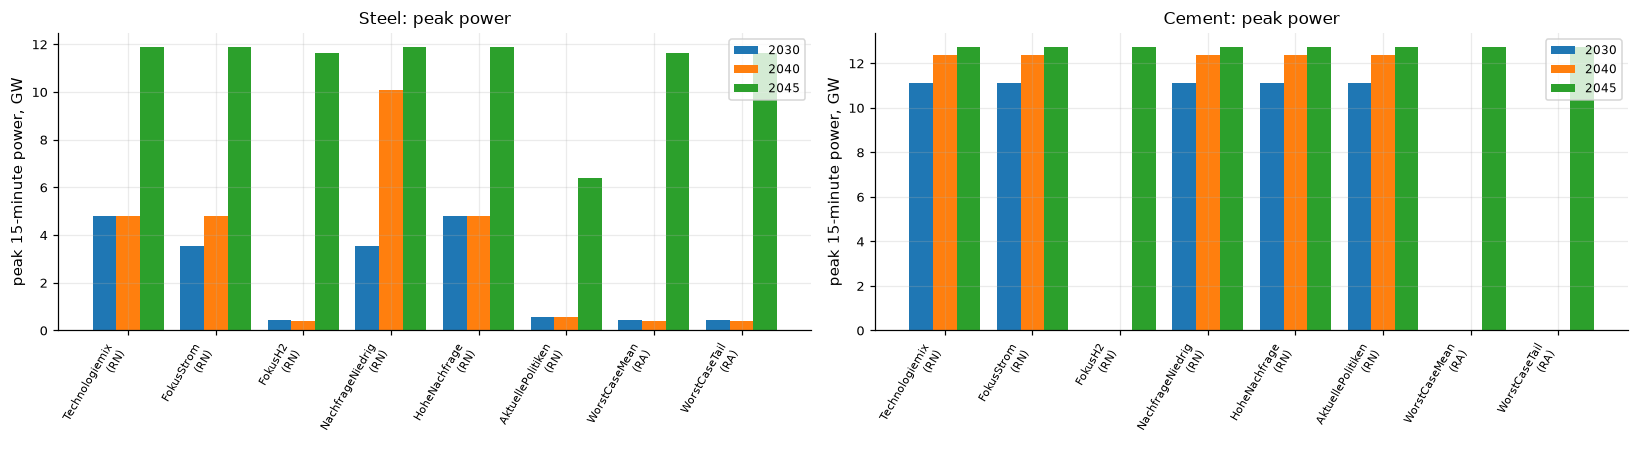

In [43]:
pk = S[(S.macro == REFERENCE_MACRO) & (S.year.isin([2030, 2040, 2045]))].copy()
pk["load_factor"] = pk.mean_MW / pk.peak_MW
fig, axes = plt.subplots(1, 2, figsize=(15, 4.2))
for ax, sector in zip(axes, SECTORS):
    d = pk[pk.sector == sector]
    w = 0.27
    for k, year in enumerate([2030, 2040, 2045]):
        s = d[d.year == year].set_index("case").loc[CASES]
        ax.bar(np.arange(8) + k * w, s.peak_MW / 1e3, width=w, label=str(year))
    ax.set_xticks(np.arange(8) + w, [CASE_SHORT[c].replace(" (", "\n(") for c in CASES], rotation=60, ha="right", fontsize=7.5)
    ax.set_ylabel("peak 15-minute power, GW"); ax.set_title(f"{SECTORS[sector]['title']}: peak power")
    ax.legend()
fig.tight_layout()
plt.show()
display(pk.pivot_table(index=["sector", "case"], columns="year", values="load_factor").rename(index=CASE_SHORT, level=1).round(2)
        .style.set_caption("Load factor (mean power / peak power)"))

**Key findings: electricity demand and its timing**

* **Level.** In 2040 the cement R8 cases draw 95 to 117 TWh of electricity per year depending on the world; the hydrogen-first cases draw 0.2 to 0.5 TWh. For steel the 2040 range is 35 to 48 TWh (Technologiemix, FokusStrom, HoheNachfrage), 75 to 93 TWh (NachfrageNiedrig), 4 to 5 TWh (AktuellePolitiken) and 3 to 3.5 TWh (FokusH2, risk-averse). By 2045 all cases converge on about 100 TWh (cement 109, steel 98 to 100).
* **Shape.** The plants run almost flat. The load factor is 0.95 in cement and 0.91 to 0.97 in steel, and each month carries 7.9 to 8.5 percent of the annual demand. The cases differ in level, not in seasonal or daily shape.
* **Timing quality.** Plants still buy cheaper than the market average by shedding the few very expensive hours. In 2040 the price capture ratio is 0.91 to 1.02 for R8, 0.52 to 0.97 for R11a and 0.82 to 0.99 for R15a, and 0.18 to 0.92 for the steel technologies, lowest in the NachfrageNiedrig world.
* **Interface to the market model.** The 15-minute series therefore add a very large, almost constant load whose size, not its timing, changes with the case. The effect on prices has to come from the market model.

## 9. Consistency checks

Three checks protect the argument. First, the cost components built in section 5 from price times quantity must add up to FLEXIMOD's own gross operating cost, and must agree with the cost AURIS was given. Second, AURIS prices technologies with the economics it was given; those must agree with what FLEXIMOD simulates. Third, the 15-minute files must reproduce the annual FLEXIMOD summaries.

In [44]:
# (a) AURIS scenario inputs versus FLEXIMOD simulation, same plant, technology, macro scenario and anchor year.
def auris_inputs(sector: str, params: list[str]) -> pd.DataFrame:
    f = SECTORS[sector]["auris_in"] / "Technologiemix_risk_neutral/scenarios/scenarios.csv"
    d = pd.read_csv(f, usecols=["scenario_id", "plant_id", "technology_id", "year", "parameter", "value"])
    d = d[d.year.isin(ANCHORS) & d.parameter.isin(params)]
    return d.pivot_table(index=["scenario_id", "plant_id", "technology_id", "year"], columns="parameter", values="value").reset_index()


checks = []
for sector, auris_params, sim_cols in (
    ("cement", ["annual_cement_output_t", "annual_electricity_demand_mwh", "annual_co2_emissions_t"],
     {"annual_cement_output_t": "production_t", "annual_electricity_demand_mwh": "total_electricity_consumption_MWh",
      "annual_co2_emissions_t": "total_co2_emissions_t"}),
    ("steel", ["annual_steel_output_t"], {"annual_steel_output_t": "production_t"}),
):
    a = auris_inputs(sector, auris_params)
    s = SIM[sector].rename(columns={"macro": "scenario_id", "technology": "technology_id"})
    m = a.merge(s, on=["scenario_id", "plant_id", "technology_id", "year"], how="inner")
    for p, c in sim_cols.items():
        denom = m[c].abs().replace(0, np.nan)
        rel = ((m[p] - m[c]).abs() / denom).dropna()
        checks.append({"sector": sector, "quantity": p, "matched rows": len(m),
                       "median relative deviation": rel.median(), "95th percentile": rel.quantile(0.95), "max": rel.max()})
display(pd.DataFrame(checks).style.hide(axis="index").format({"median relative deviation": "{:.2%}", "95th percentile": "{:.2%}", "max": "{:.2%}"})
        .set_caption("AURIS economic inputs versus FLEXIMOD simulation results"))

# (b) the 15-minute files reproduce the annual FLEXIMOD summaries (example plant-year)
f = pd.read_csv(PROFILE_DIR / "steel/WorstCaseMean_risk_averse__technologiemix.csv.zst", compression="zstd",
                usecols=["plant_id", "year", "active_technology_id", "da_electricity_MWh", "afrr_neg_energy_MWh"])
f = f[(f.plant_id == "P100000120421") & (f.year == 2040)]
print("example plant-year  15-min file DA (MWh):", round(f.da_electricity_MWh.sum(), 1), "| technology in file:", f.active_technology_id.iloc[0])
ref = SIM["steel"].query("macro == 'technologiemix' and year == 2040 and plant_id == 'P100000120421' and technology == @f.active_technology_id.iloc[0]")
print("FLEXIMOD summary DA (MWh)                 :", round(ref.total_DA_electricity_MWh.iloc[0], 1))
assert abs(f.da_electricity_MWh.sum() - ref.total_DA_electricity_MWh.iloc[0]) < 1e-3 * ref.total_DA_electricity_MWh.iloc[0]

sector,quantity,matched rows,median relative deviation,95th percentile,max
cement,annual_cement_output_t,14592,0.00%,0.00%,0.00%
cement,annual_electricity_demand_mwh,14592,0.00%,0.00%,0.00%
cement,annual_co2_emissions_t,14592,0.00%,0.00%,0.00%
steel,annual_steel_output_t,3888,0.00%,0.00%,0.00%


example plant-year  15-min file DA (MWh): 1172517.9 | technology in file: dri_bof_hybrid_hydrogen_natural_gas_external
FLEXIMOD summary DA (MWh)                 : 1172517.9


In [45]:
# (c) cost-component reconstruction: does price x quantity add up to FLEXIMOD's own gross operating cost,
# and does AURIS's own cost input agree with the operating cost rebuilt from scenario prices? (used to build section 5)
chk = []
for s, c in COST.items():
    ident = (c[["coal", "natural gas", "biomass", "RDF", "bought hydrogen", "iron ore", "lime", "CO2 allowances", "other / unexplained",
                "electricity market (DA + aFRR)", "grid fees and levies"]].sum(axis=1) - c["gross_operating_cost_EUR"]).abs().max()
    resid = (c["other / unexplained"].abs() / c["gross_operating_cost_EUR"]).describe()
    chk.append({"sector": s, "max identity error (EUR)": ident, "median unexplained / gross cost": resid["50%"],
                "95th percentile": c["other / unexplained"].abs().div(c["gross_operating_cost_EUR"]).quantile(0.95),
                "max": resid["max"]})
display(pd.DataFrame(chk).style.hide(axis="index").format({"max identity error (EUR)": "{:.2e}", "median unexplained / gross cost": "{:.2%}",
                                                            "95th percentile": "{:.2%}", "max": "{:.2%}"})
        .set_caption("Component reconstruction: share of the gross operating cost that price x quantity does not explain"))

rows = []
for s, c in COST.items():
    a = auris_parameters(s, ["annual_net_operating_cost"])
    m = c.merge(a, on=["plant_id", "macro", "technology", "year"], how="inner")
    rel = (m["operating cost"] / m["annual_net_operating_cost"] - 1).replace([np.inf, -np.inf], np.nan).dropna()
    rows.append({"sector": s, "matched rows": len(m), "median deviation": rel.median(), "5th percentile": rel.quantile(.05),
                 "95th percentile": rel.quantile(.95)})
display(pd.DataFrame(rows).style.hide(axis="index").format({"median deviation": "{:+.2%}", "5th percentile": "{:+.2%}", "95th percentile": "{:+.2%}"})
        .set_caption("Rebuilt operating cost versus the cost AURIS uses (positive = rebuilt cost higher)"))

sector,max identity error (EUR),median unexplained / gross cost,95th percentile,max
steel,3.81e-06,0.00%,0.15%,0.83%
cement,4.77e-07,0.00%,0.02%,0.07%


sector,matched rows,median deviation,5th percentile,95th percentile
steel,3888,+0.84%,+0.01%,+4.84%
cement,14592,+0.13%,+0.01%,+3.05%


**Key findings: consistency**

AURIS and FLEXIMOD agree exactly on the quantities they share: cement output, electricity demand and CO2 match to 0.00 percent over 14,592 plant-technology-scenario-year rows, and steel output over 3,888 rows. The 15-minute files reproduce the FLEXIMOD annual summary (checked on an example plant-year). The NPV values AURIS reports can be rebuilt from its annual cash flows to machine precision. The three checks together mean that differences between the cases in this notebook come from the decisions and the scenarios, not from inconsistent inputs.

## 10. Synthesis: one table per sector

Every layer of the chain for every case on one page. *Dominant technology* is the technology with the largest capacity share in that year. Physical values are for the reference world (`REFERENCE_MACRO`); NPV values are portfolio NPVs of the 2025 decisions from section 6.4.

In [46]:
def dominant(sector: str, case: str, year: int) -> str:
    pw = AUR[sector][case]["pathway"]
    cap = pw[pw.year == year].groupby("active_technology_id")["capacity"].sum()
    top = cap.idxmax()
    return f"{tech_label(sector, top)} ({cap[top] / cap.sum():.0%})"


rows = []
tot = SECTOR_TOT[SECTOR_TOT.macro == REFERENCE_MACRO].set_index(["sector", "case", "year"])
peak = PROF["summary"][(PROF["summary"].macro == REFERENCE_MACRO)].set_index(["sector", "case", "year"])
ev = EVENTS.groupby(["sector", "case"]).agg(investments=("plant_id", "size"), capex_bn=("capex_bn", "sum"))
for sector in SECTORS:
    for case in [NOINV, *CASES]:
        r = {"sector": sector, "case": CASE_SHORT[case]}
        if case != NOINV:
            r.update({"technology 2030": dominant(sector, case, 2030), "technology 2045": dominant(sector, case, 2045),
                      "investments": ev.loc[(sector, case), "investments"], "CAPEX (EUR bn)": ev.loc[(sector, case), "capex_bn"]})
            rb = ROBUST[(ROBUST.sector == sector) & (ROBUST.case == CASE_SHORT[case])].iloc[0]
            r["NPV mean over beliefs (EUR bn)"] = rb["mean over beliefs (EUR bn)"]
            r["NPV worst scenario (EUR bn)"] = rb["worst scenario (EUR bn)"]
            r["peak power 2040 (GW)"] = peak.loc[(sector, case, 2040), "peak_MW"] / 1e3
        for y in (2030, 2045):
            r[f"electricity {y} (TWh)"] = tot.loc[(sector, case, y), "electricity_GWh"] / 1e3
            r[f"hydrogen {y} (TWh)"] = tot.loc[(sector, case, y), "hydrogen_GWh"] / 1e3
            r[f"CO2 {y} (Mt)"] = tot.loc[(sector, case, y), "co2_Mt"]
        rows.append(r)
SYNTH = pd.DataFrame(rows)
for sector in SECTORS:
    sub = SYNTH[SYNTH.sector == sector].drop(columns="sector").set_index("case")
    display(sub.style.format({c: "{:,.1f}" for c in sub.columns if "(" in c and "technology" not in c}, na_rep="-")
            .set_caption(f"{SECTORS[sector]['title']}: decision, economics, fuels, emissions and electricity per case"))

,electricity 2030 (TWh),hydrogen 2030 (TWh),CO2 2030 (Mt),electricity 2045 (TWh),hydrogen 2045 (TWh),CO2 2045 (Mt),technology 2030,technology 2045,investments,CAPEX (EUR bn),NPV mean over beliefs (EUR bn),NPV worst scenario (EUR bn),peak power 2040 (GW)
case,,,,,,,,,,,,,
No investment,3.3,0.0,35.3,3.1,0.0,33.6,-,-,-,-,-,-,-
Technologiemix (RN),40.7,24.5,9.0,95.9,62.4,0.1,BF-BOF hybrid H2 + gas (network H2) (29%),BF-BOF hydrogen (on-site H2) (63%),25.000000,34.3,73.2,3.5,4.8
FokusStrom (RN),29.9,16.9,10.7,95.9,62.4,0.1,BF-BOF hybrid H2 + gas (network H2) (41%),BF-BOF hydrogen (on-site H2) (63%),26.000000,33.4,76.3,37.1,4.8
FokusH2 (RN),3.7,0.0,14.4,94.2,62.4,0.1,BF-BOF hybrid H2 + gas (network H2) (68%),BF-BOF hydrogen (on-site H2) (79%),29.000000,27.9,78.5,65.6,0.4
NachfrageNiedrig (RN),29.9,16.9,10.7,95.9,62.4,0.1,BF-BOF hybrid H2 + gas (network H2) (41%),BF-BOF hydrogen (on-site H2) (63%),25.000000,32.9,76.3,37.1,10.1
HoheNachfrage (RN),40.7,24.5,9.0,95.9,62.4,0.1,BF-BOF hybrid H2 + gas (network H2) (29%),BF-BOF hydrogen (on-site H2) (63%),25.000000,35.4,73.2,3.5,4.8
AktuellePolitiken (RN),4.6,0.0,14.4,51.8,32.5,6.6,BF-BOF hybrid H2 + gas (network H2) (57%),BF-BOF hydrogen (on-site H2) (35%),27.000000,27.6,78.5,65.6,0.5
WorstCaseMean (RA),3.7,0.0,14.4,94.2,62.4,0.1,BF-BOF hybrid H2 + gas (network H2) (68%),BF-BOF hydrogen (on-site H2) (79%),30.000000,29.2,78.5,65.6,0.4
WorstCaseTail (RA),3.7,0.0,14.4,94.2,62.4,0.1,BF-BOF hybrid H2 + gas (network H2) (68%),BF-BOF hydrogen (on-site H2) (79%),30.000000,29.2,78.5,65.6,0.4


,electricity 2030 (TWh),hydrogen 2030 (TWh),CO2 2030 (Mt),electricity 2045 (TWh),hydrogen 2045 (TWh),CO2 2045 (Mt),technology 2030,technology 2045,investments,CAPEX (EUR bn),NPV mean over beliefs (EUR bn),NPV worst scenario (EUR bn),peak power 2040 (GW)
case,,,,,,,,,,,,,
No investment,0.2,0.0,57.1,0.2,0.0,61.5,-,-,-,-,-,-,-
Technologiemix (RN),92.3,0.0,20.7,105.8,0.0,20.0,R8 (94%),R8 (100%),38.000000,19.0,-39.0,-255.1,12.4
FokusStrom (RN),92.3,0.0,20.7,105.8,0.0,20.0,R8 (94%),R8 (100%),38.000000,19.0,-39.0,-255.1,12.4
FokusH2 (RN),0.2,88.5,6.6,105.8,0.0,20.0,R15a (94%),R8 (100%),70.000000,25.4,-77.7,-109.7,0.0
NachfrageNiedrig (RN),92.3,0.0,20.7,105.8,0.0,20.0,R8 (94%),R8 (100%),38.000000,18.2,-39.0,-255.1,12.4
HoheNachfrage (RN),92.3,0.0,20.7,105.8,0.0,20.0,R8 (94%),R8 (100%),38.000000,20.4,-39.0,-255.1,12.4
AktuellePolitiken (RN),92.3,0.0,20.7,105.8,0.0,20.0,R8 (94%),R8 (100%),38.000000,18.9,-39.0,-255.1,12.4
WorstCaseMean (RA),0.2,88.5,6.6,105.8,0.0,20.0,R15a (94%),R8 (100%),70.000000,25.5,-77.7,-109.7,0.0
WorstCaseTail (RA),0.2,88.5,7.1,105.8,0.0,20.0,R15a (91%),R8 (100%),70.000000,25.9,-77.7,-109.7,0.0


### Key findings of the whole chain

1. **The decision is driven by the price world the investor fears, not only the one it believes in.** Five steel and five cement risk-neutral cases choose electrified or on-site-hydrogen routes because these are cheapest in four of the five "normal" worlds. FokusH2 (scarcity pricing) is the exception where the same routes become the most expensive options by a factor of five to fifteen, and that single world sets the risk-averse choices.
2. **Risk aversion has a price that differs by sector.** For steel, the robust technology (hybrid routes with network hydrogen) is also best on average over the six beliefs, so hedging costs nothing in expected value. For cement the hydrogen-based robust plan gives up about 39 EUR bn of average NPV to lift the worst case by about 145 EUR bn; by the minimax-regret criterion the electric plan looks better, by the worst-case criterion the hydrogen plan does. The result depends on which robustness criterion the investor applies.
3. **By 2045 the pathways converge.** Every case ends on electricity-based cement (R8) and on on-site electrolyser steel, because the 2025 investments reach the end of their life and the 2045 price anchors favour them. What differs is the 20 years in between.
4. **In the reference world (AktuellePolitiken), emissions fall by 60 to 100 percent in 2030 and 67 to 100 percent by 2045, well short of the 95 to 99 percent this notebook reported under the Technologiemix reference for the same AURIS pathways** (steel from about 35 Mt to 9 to 14 Mt in 2030 and to 0.1 to 6.6 Mt in 2045; cement from about 57 Mt to 6.6 to 21 Mt in 2030 and to a uniform 20 Mt in 2045, for every case including the ones that invest earliest and most). The technology choice is identical in both reference worlds; only the carbon price the plants actually face while running changes the outcome, because AktuellePolitiken has none (section 3, section 6).
5. **Electricity demand differs by two orders of magnitude between cases in 2030** (cement 0.2 versus 92.3 TWh, steel 3.7 versus 40.7 TWh) and then partly converges by 2045 (cement fully converges to 105.8 TWh for every case once all reach R8; steel narrows to 51.8 to 95.9 TWh but does not fully converge, because the AktuellePolitiken case's own pathway still burns gas rather than hydrogen when realised in its own world -- see point 4 in section 5.1's findings). The shape inside the year is almost flat in all cases; the cases differ in level, not in timing. Timing quality differs by technology (price capture ratios from about 0.2 to 1.0).
6. **Carbon-price dependence is no longer a hidden risk here -- it is the headline result.** Earlier versions of this notebook used the Technologiemix reference and flagged, as a caveat, that the electrified cement route would emit about 19 Mt instead of about 2 Mt if AktuellePolitiken occurred, because capture is not economic without a carbon price. With AktuellePolitiken now the reference world throughout sections 5 to 9, that 20 Mt figure is what every chart above actually shows: a decarbonisation outcome that depends on a carbon price materialising should be read as conditional, and this notebook's own reference world is now the demonstration of the case where it does not.

## 11. How to read this notebook: questions a reviewer is likely to ask

| Question | Where it is answered |
|---|---|
| Which technology is invested in, by which plant, in which year? | 6.1 (fleet mix), 6.2 (pathway matrices), 6.3 (events and CAPEX), the `technology_pathway.csv` files |
| Why that technology and not another? | 5 (unit economics and scenario ranking), 6.5 (decision dossier with NPV by scenario and its decomposition) |
| Why do risk-neutral and risk-averse cases differ? | 4.1 (beliefs), 4.4 (performance and regret matrix), 4.4b (robust frontier), 4.5 (ranking by each metric for the same plant) |
| Is the NPV calculation reproducible? | 6.4 check cell: rebuilt expected NPV equals the AURIS value to 1e-16 |
| How does the choice change fuels and CO2? | 7.1 to 7.6 |
| What is inside each configuration, and what does it burn per tonne? | 5.1 (carrier share and MWh per t steel / t clinker for every option), 7.4 (chosen technologies), 0 (definitions) |
| How does electricity demand evolve over the years, the seasons and the day? | 8.1, 8.2, 8.4 |
| Does a technology buy electricity cheaply? | 8.3 (price capture ratio) |
| Do AURIS and FLEXIMOD agree on the numbers they share? | 9 |
| What is the situation today, before any investment? | 2 |

### Limitations that matter for interpretation

* **Prices are exogenous.** A technology choice changes demand, not prices, inside this notebook. The market feedback is the task of the electricity-market model that consumes the 15-minute files.
* **Anchor years.** FLEXIMOD is simulated for 2030, 2035, 2040 and 2045. Years in between use the nearest earlier anchor (2025 to 2029 use 2030), so profiles are step functions of the anchor year, not annual simulations.
* **Simulation window.** Each simulated year covers about 364 days (steel from 2 January, cement from 1 January). Annual values are those windows, not rescaled.
* **Sector inputs differ slightly.** Steel and cement forecast files have the same day-ahead, fuel and hydrogen prices to within 0.3 percent but different CO2 prices in several scenario years (up to 22 percent), see section 3.
* **AURIS economics.** Revenue assumptions (for example 120 EUR per tonne of cement), the 5 percent discount rate, the 20 to 25 year technology lifetimes and the horizon to 2045 shape the NPVs. The NPVs are not forecasts of profit; they rank options.
* **AURIS energy and CO2 columns for steel are placeholders.** This notebook therefore takes all physical quantities from FLEXIMOD.
* **Reference world.** Cross-case comparisons of fuels, CO2 and electricity use one macro scenario (`REFERENCE_MACRO`). Change that variable to repeat every comparison in another world.